# **PART 1 — Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import glob

# Find uploaded Excel file
excel_files = glob.glob("/content/*.xlsx")

if len(excel_files) == 0:
    print("ERROR: No Excel file found.")
else:
    file_path = excel_files[0]
    print("File found:", file_path)

    # Load Excel data
    df_raw = pd.read_excel(file_path)

    # Create working copy
    df = df_raw.copy()

    print("\nDataset loaded successfully.")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

File found: /content/Academic Performance Prediction Survey   (Responses) - Form responses - Full one correct.xlsx

Dataset loaded successfully.
Rows: 435
Columns: 23


In [2]:
df.head()

,1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.,2. Are you currently studying at a Sri Lankan university or higher education institute?,3. Type of institution,4. Year of study,5. Degree area / study field,6. Study mode,7. Gender,8. Average class attendance,9. Average study hours per day,10. How often do you use LMS / online learning platforms for academic work?,...,14. Average sleep hours per night,15. Motivation level for studies,16. Time management ability,17. Internet access quality for academic work,18. Do you work part-time while studying?,19. Academic stress level,20. Travel time to university / campus,21. Access to study resources,22. Your current academic performance level,23. Do you think you currently need academic support or guidance?
0,I agree to participate,Yes,Private campus / private higher education inst...,Year 3,Information Technology / Computing,Full-time,Male,85% and above,3â€“4 hours,Often,...,7â€“8 hours,Medium,Average,Very good,No,High,More than 2 hours,Good,High = 70 marks or above,Maybe
1,I agree to participate,Yes,Private campus / private higher education inst...,Year 4,Information Technology / Computing,Full-time,Male,70%â€“84%,3â€“4 hours,Sometimes,...,5â€“6 hours,High,Good,Very good,Yes,High,Less than 30 minutes,Poor,Average = 40â€“69 marks,Yes
2,I agree to participate,Yes,Private campus / private higher education inst...,Year 2,Information Technology / Computing,Full-time,Male,85% and above,3â€“4 hours,Rarely,...,5â€“6 hours,Low,Poor,Average,No,High,Less than 30 minutes,Good,Average = 40â€“69 marks,Yes
3,I agree to participate,Yes,Private campus / private higher education inst...,Year 1,Education,Part-time,Female,85% and above,More than 4 hours,Sometimes,...,5â€“6 hours,High,Average,Good,Yes,Medium,More than 2 hours,Good,High = 70 marks or above,Yes
4,I agree to participate,Yes,Private campus / private higher education inst...,Year 3,Information Technology / Computing,Full-time,Female,85% and above,1â€“2 hours,Often,...,5â€“6 hours,High,Average,Good,No,Medium,Less than 30 minutes,Good,High = 70 marks or above,Maybe


In [3]:
print("Total number of responses:", df.shape[0])
print("Total number of variables:", df.shape[1])

Total number of responses: 435
Total number of variables: 23


In [4]:
for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

1 : 1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
2 : 2. Are you currently studying at a Sri Lankan university or higher education institute?  
3 : 3. Type of institution  
4 : 4. Year of study  
5 : 5. Degree area / study field  
6 : 6. Study mode  
7 : 7. Gender  
8 : 8. Average class attendance  
9 : 9. Average study hours per day  
10 : 10. How often do you use LMS / online learning platforms for academic work?  
11 : 11. Assignment submission habit  
12 : 12. Participation in lectures / tutorials / practical sessions  
13 : 13. Current CA / coursework marks range  
14 : 14. Average sleep hours per night  
15 : 15. Motivation level for studies  
16 : 16. Time management ability  
17 : 17. Internet access quality for academic work  
18 : 18. Do you work part-time while studying?  
19 : 19. Academic stress level  
20 : 20. Travel time to university / campus  
21 : 21. Access to study resources  
22 : 22. Your current aca

In [5]:
print(df.dtypes)

1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.     object
2. Are you currently studying at a Sri Lankan university or higher education institute?                          object
3. Type of institution                                                                                           object
4. Year of study                                                                                                 object
5. Degree area / study field                                                                                     object
6. Study mode                                                                                                    object
7. Gender                                                                                                        object
8. Average class attendance                                                                                      object
9. Average study hours per day          

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 23 columns):
 #   Column                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                         --------------  ----- 
 0   1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.   435 non-null    object
 1   2. Are you currently studying at a Sri Lankan university or higher education institute?                        435 non-null    object
 2   3. Type of institution                                                                                         435 non-null    object
 3   4. Year of study                                                                                               434 non-null    object
 4   5. Degree area / study field                            

In [7]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_report

,Missing_Count,Missing_Percentage
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.,0,0.00
2. Are you currently studying at a Sri Lankan university or higher education institute?,0,0.00
3. Type of institution,0,0.00
4. Year of study,1,0.23
5. Degree area / study field,0,0.00
6. Study mode,1,0.23
7. Gender,1,0.23
8. Average class attendance,0,0.00
9. Average study hours per day,0,0.00
10. How often do you use LMS / online learning platforms for academic work?,0,0.00


In [8]:
missing_only = missing_report[
    missing_report["Missing_Count"] > 0
]

missing_only

,Missing_Count,Missing_Percentage
4. Year of study,1,0.23
6. Study mode,1,0.23
7. Gender,1,0.23


In [9]:
exact_duplicates = df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 0


In [10]:
unique_report = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [
        df[col].nunique(dropna=False)
        for col in df.columns
    ]
})

unique_report

,Column,Unique_Values
0,1. I have read the information above and agree...,1
1,2. Are you currently studying at a Sri Lankan ...,2
2,3. Type of institution,2
3,4. Year of study,5
4,5. Degree area / study field,7
5,6. Study mode,3
6,7. Gender,4
7,8. Average class attendance,4
8,9. Average study hours per day,4
9,10. How often do you use LMS / online learning...,4


In [11]:
for col in df.columns:
    print("\n" + "=" * 100)
    print("COLUMN:", col)
    print("=" * 100)

    print(df[col].value_counts(dropna=False))


COLUMN: 1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
I agree to participate    435
Name: count, dtype: int64

COLUMN: 2. Are you currently studying at a Sri Lankan university or higher education institute?  
2. Are you currently studying at a Sri Lankan university or higher education institute?  
Yes    427
No       8
Name: count, dtype: int64

COLUMN: 3. Type of institution  
3. Type of institution  
Private campus / private higher education institute    404
Government university                                   31
Name: count, dtype: int64

COLUMN: 4. Year of study  
4. Year of study  
Year 2    160
Year 3    148
Year 1     88
Year 4     38
NaN         1
Name: count, dtype: int64

COLUMN: 5. Degree area / study field  
5. Degree area / study field  
Information Technology / Computing    112
Engineering        

In [12]:
summary_table = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": [str(df[col].dtype) for col in df.columns],
    "Missing": [df[col].isnull().sum() for col in df.columns],
    "Missing_%": [
        round(df[col].isnull().mean() * 100, 2)
        for col in df.columns
    ],
    "Unique_Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

summary_table

,Variable,Data_Type,Missing,Missing_%,Unique_Values
0,1. I have read the information above and agree...,object,0,0.00,1
1,2. Are you currently studying at a Sri Lankan ...,object,0,0.00,2
2,3. Type of institution,object,0,0.00,2
3,4. Year of study,object,1,0.23,4
4,5. Degree area / study field,object,0,0.00,7
5,6. Study mode,object,1,0.23,2
6,7. Gender,object,1,0.23,3
7,8. Average class attendance,object,0,0.00,4
8,9. Average study hours per day,object,0,0.00,4
9,10. How often do you use LMS / online learning...,object,0,0.00,4


In [13]:
target_col = [
    col for col in df.columns
    if col.strip().startswith("22.")
][0]

print("Target column:")
print(target_col)

print("\nTarget class counts:")
print(df[target_col].value_counts(dropna=False))

print("\nTarget class percentages:")
print(
    (df[target_col].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
)

Target column:
22. Your current academic performance level  

Target class counts:
22. Your current academic performance level  
Average = 40â€“69 marks     253
Low = below 40 marks        117
High = 70 marks or above     65
Name: count, dtype: int64

Target class percentages:
22. Your current academic performance level  
Average = 40â€“69 marks     58.16
Low = below 40 marks        26.90
High = 70 marks or above    14.94
Name: proportion, dtype: float64


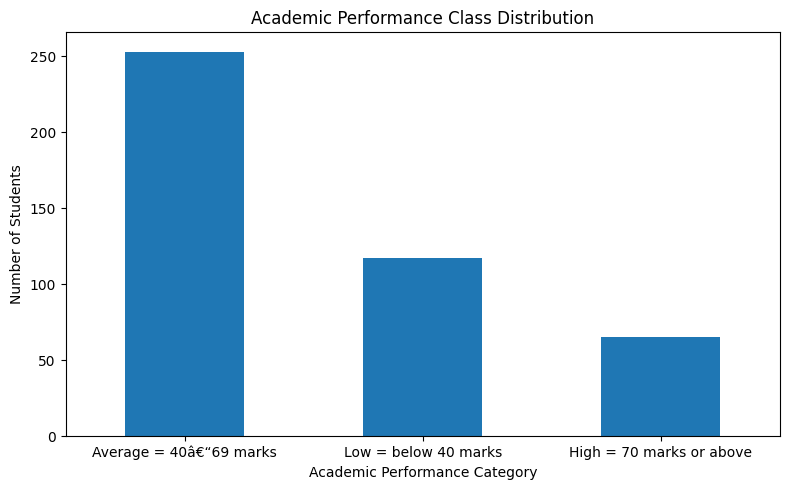

In [14]:
import matplotlib.pyplot as plt

target_counts = df[target_col].value_counts()

plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")

plt.title("Academic Performance Class Distribution")
plt.xlabel("Academic Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
institution_col = [
    col for col in df.columns
    if col.strip().startswith("3.")
][0]

print(df[institution_col].value_counts(dropna=False))

print("\nPercentage:")
print(
    (df[institution_col].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
)

3. Type of institution  
Private campus / private higher education institute    404
Government university                                   31
Name: count, dtype: int64

Percentage:
3. Type of institution  
Private campus / private higher education institute    92.87
Government university                                   7.13
Name: proportion, dtype: float64


In [16]:
student_status_col = [
    col for col in df.columns
    if col.strip().startswith("2.")
][0]

print(df[student_status_col].value_counts(dropna=False))

2. Are you currently studying at a Sri Lankan university or higher education institute?  
Yes    427
No       8
Name: count, dtype: int64


In [17]:
consent_col = [
    col for col in df.columns
    if col.strip().startswith("1.")
][0]

print(df[consent_col].value_counts(dropna=False))

1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
I agree to participate    435
Name: count, dtype: int64


In [18]:
print("========== DATA UNDERSTANDING SUMMARY ==========")

print("\nTotal responses:", df.shape[0])
print("Total variables:", df.shape[1])

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nTotal missing cells:", df.isnull().sum().sum())

print("\nColumns containing missing data:")
print(df.columns[df.isnull().any()].tolist())

print("\nTarget distribution:")
print(df[target_col].value_counts())

print("\nInstitution distribution:")
print(df[institution_col].value_counts())

print("\nCurrent student status:")
print(df[student_status_col].value_counts())

print("\nConsent status:")
print(df[consent_col].value_counts())

========== DATA UNDERSTANDING SUMMARY ==========

Total responses: 435
Total variables: 23

Exact duplicate rows: 0

Total missing cells: 3

Columns containing missing data:
['4. Year of study  ', '6. Study mode  ', '7. Gender  ']

Target distribution:
22. Your current academic performance level  
Average = 40â€“69 marks     253
Low = below 40 marks        117
High = 70 marks or above     65
Name: count, dtype: int64

Institution distribution:
3. Type of institution  
Private campus / private higher education institute    404
Government university                                   31
Name: count, dtype: int64

Current student status:
2. Are you currently studying at a Sri Lankan university or higher education institute?  
Yes    427
No       8
Name: count, dtype: int64

Consent status:
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
I agree to participate    435
Name: count, dtype: int64


**PART 2 — Data Exploration**

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
for i, col in enumerate(df.columns, start=1):
    print(i, col)

1 1. I have read the information above and agree to participate voluntarily in this anonymous academic survey. 
2 2. Are you currently studying at a Sri Lankan university or higher education institute?  
3 3. Type of institution  
4 4. Year of study  
5 5. Degree area / study field  
6 6. Study mode  
7 7. Gender  
8 8. Average class attendance  
9 9. Average study hours per day  
10 10. How often do you use LMS / online learning platforms for academic work?  
11 11. Assignment submission habit  
12 12. Participation in lectures / tutorials / practical sessions  
13 13. Current CA / coursework marks range  
14 14. Average sleep hours per night  
15 15. Motivation level for studies  
16 16. Time management ability  
17 17. Internet access quality for academic work  
18 18. Do you work part-time while studying?  
19 19. Academic stress level  
20 20. Travel time to university / campus  
21 21. Access to study resources  
22 22. Your current academic performance level  
23 23. Do you thin

In [21]:
def plot_bar(column_name, title, xlabel):
    counts = df[column_name].value_counts(dropna=False)

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

4. Year of study  
Year 2    160
Year 3    148
Year 1     88
Year 4     38
NaN         1
Name: count, dtype: int64


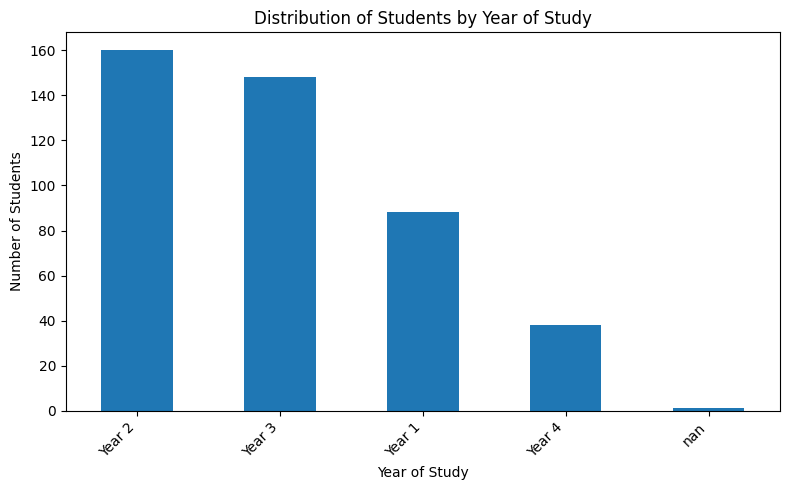

In [22]:
year_col = [col for col in df.columns if col.strip().startswith("4.")][0]

print(df[year_col].value_counts(dropna=False))

plot_bar(
    year_col,
    "Distribution of Students by Year of Study",
    "Year of Study"
)

5. Degree area / study field  
Information Technology / Computing    112
Engineering                            95
Business / Management                  94
Science                                67
Arts / Humanities                      29
Education                              25
Other                                  13
Name: count, dtype: int64


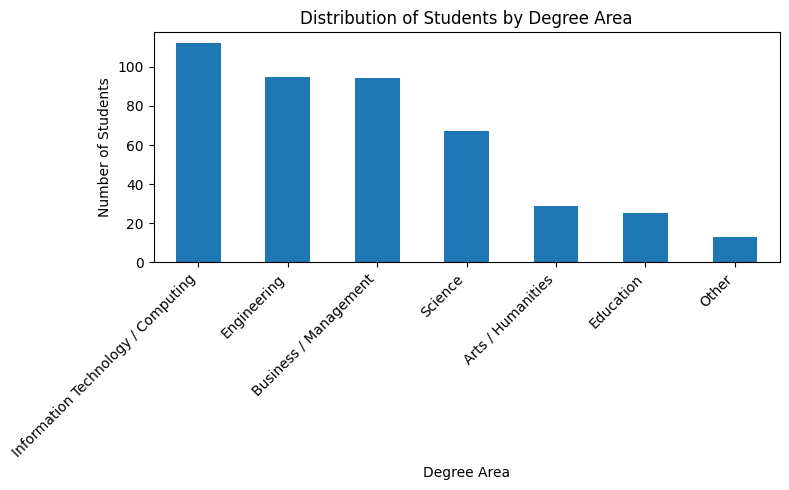

In [23]:
degree_col = [col for col in df.columns if col.strip().startswith("5.")][0]

print(df[degree_col].value_counts(dropna=False))

plot_bar(
    degree_col,
    "Distribution of Students by Degree Area",
    "Degree Area"
)

6. Study mode  
Full-time    397
Part-time     37
NaN            1
Name: count, dtype: int64


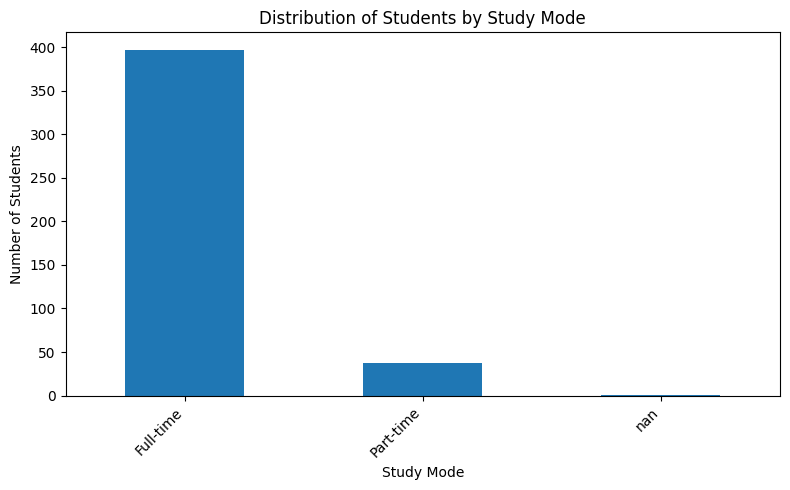

In [24]:
study_mode_col = [col for col in df.columns if col.strip().startswith("6.")][0]

print(df[study_mode_col].value_counts(dropna=False))

plot_bar(
    study_mode_col,
    "Distribution of Students by Study Mode",
    "Study Mode"
)

7. Gender  
Female               235
Male                 198
Prefer not to say      1
NaN                    1
Name: count, dtype: int64


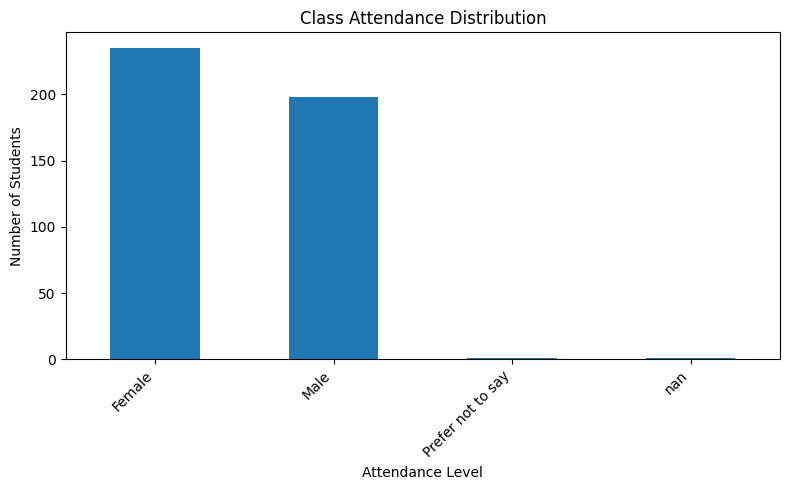

In [25]:
attendance_col = [col for col in df.columns if col.strip().startswith("7.")][0]

print(df[attendance_col].value_counts(dropna=False))

plot_bar(
    attendance_col,
    "Class Attendance Distribution",
    "Attendance Level"
)

8. Average class attendance  
50%â€“69%        170
70%â€“84%        167
Less than 50%     57
85% and above     41
Name: count, dtype: int64


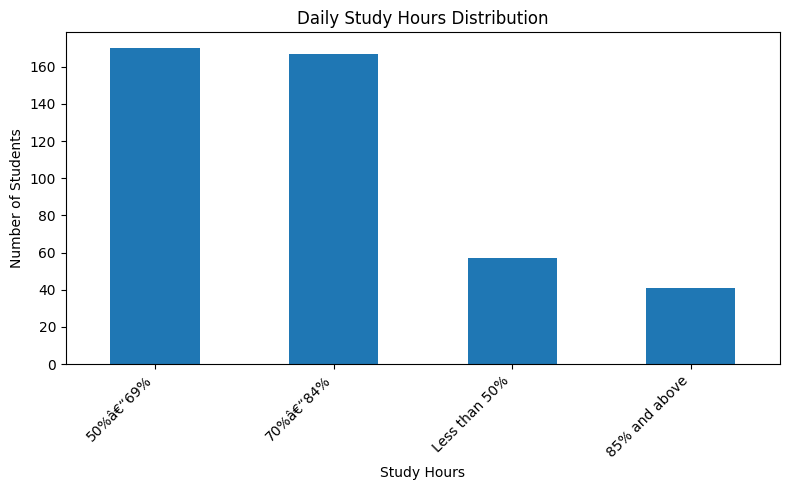

In [26]:
study_hours_col = [col for col in df.columns if col.strip().startswith("8.")][0]

print(df[study_hours_col].value_counts(dropna=False))

plot_bar(
    study_hours_col,
    "Daily Study Hours Distribution",
    "Study Hours"
)

9. Average study hours per day  
1â€“2 hours          190
3â€“4 hours          155
Less than 1 hour      61
More than 4 hours     29
Name: count, dtype: int64


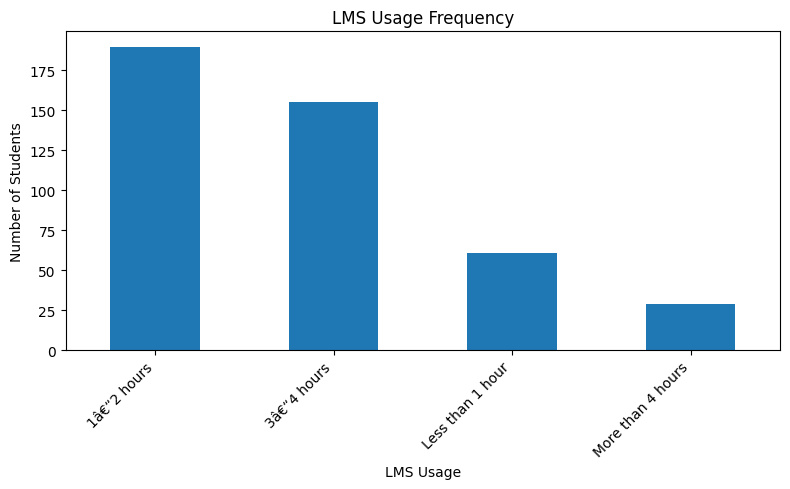

In [27]:
lms_col = [col for col in df.columns if col.strip().startswith("9.")][0]

print(df[lms_col].value_counts(dropna=False))

plot_bar(
    lms_col,
    "LMS Usage Frequency",
    "LMS Usage"
)

10. How often do you use LMS / online learning platforms for academic work?  
Sometimes     219
Often         144
Rarely         43
Very often     29
Name: count, dtype: int64


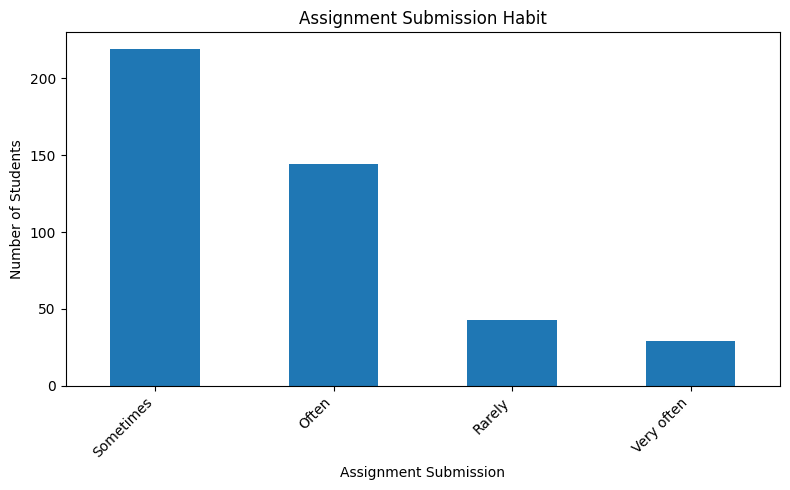

In [28]:
assignment_col = [col for col in df.columns if col.strip().startswith("10.")][0]

print(df[assignment_col].value_counts(dropna=False))

plot_bar(
    assignment_col,
    "Assignment Submission Habit",
    "Assignment Submission"
)

11. Assignment submission habit  
Usually on time    216
Sometimes late     141
Always on time      43
Usually late        35
Name: count, dtype: int64


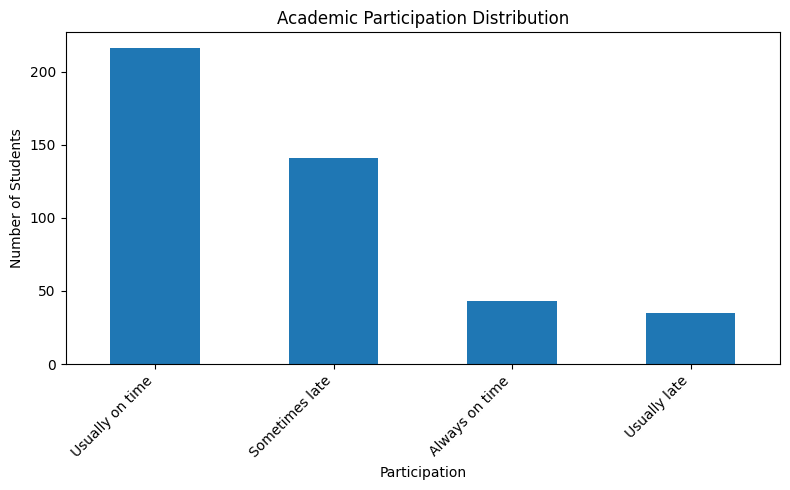

In [29]:
participation_col = [col for col in df.columns if col.strip().startswith("11.")][0]

print(df[participation_col].value_counts(dropna=False))

plot_bar(
    participation_col,
    "Academic Participation Distribution",
    "Participation"
)

12. Participation in lectures / tutorials / practical sessions  
Medium    288
Low        83
High       64
Name: count, dtype: int64


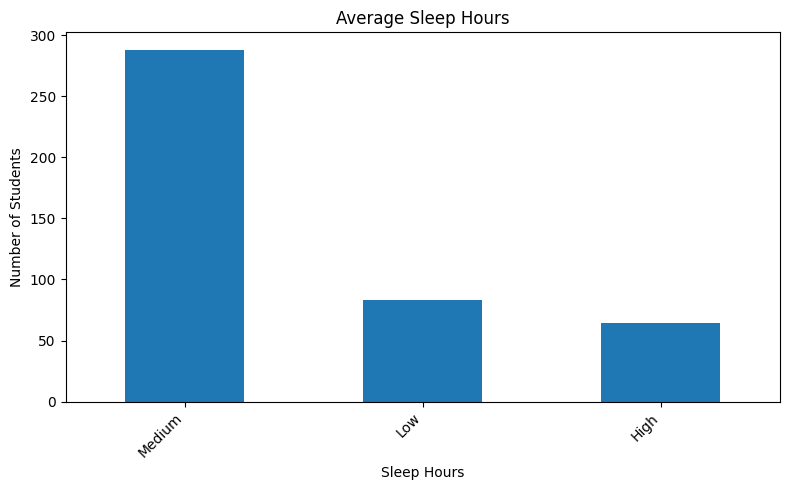

In [30]:
sleep_col = [col for col in df.columns if col.strip().startswith("12.")][0]

print(df[sleep_col].value_counts(dropna=False))

plot_bar(
    sleep_col,
    "Average Sleep Hours",
    "Sleep Hours"
)

13. Current CA / coursework marks range  
55â€“69         193
40â€“54         100
70 and above    100
Below 40         29
Not sure         13
Name: count, dtype: int64


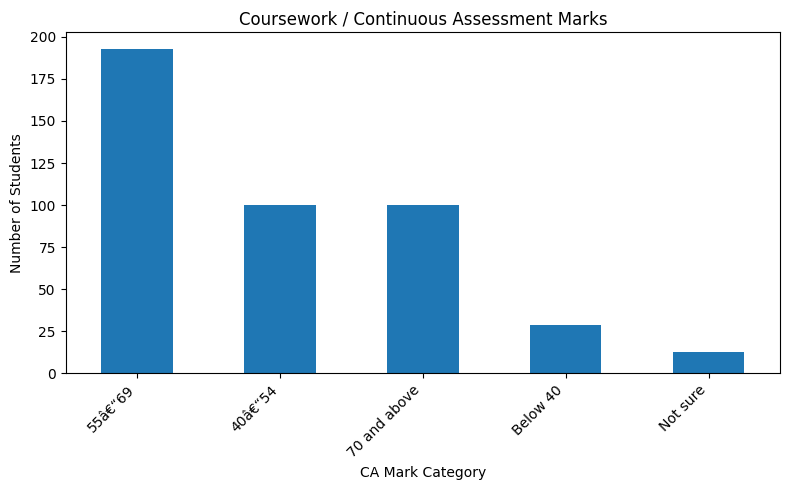

In [31]:
ca_col = [col for col in df.columns if col.strip().startswith("13.")][0]

print(df[ca_col].value_counts(dropna=False))

plot_bar(
    ca_col,
    "Coursework / Continuous Assessment Marks",
    "CA Mark Category"
)

14. Average sleep hours per night  
5â€“6 hours          230
7â€“8 hours          125
Less than 5 hours     72
More than 8 hours      8
Name: count, dtype: int64


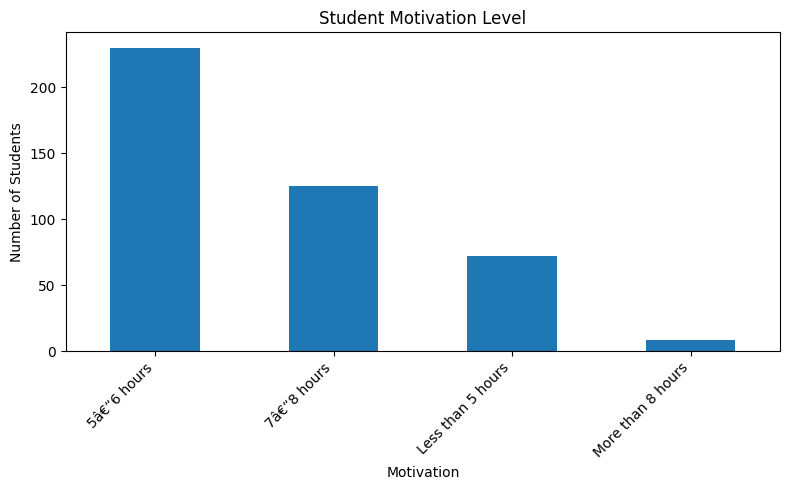

In [32]:
motivation_col = [col for col in df.columns if col.strip().startswith("14.")][0]

print(df[motivation_col].value_counts(dropna=False))

plot_bar(
    motivation_col,
    "Student Motivation Level",
    "Motivation"
)

15. Motivation level for studies  
Medium    299
Low        77
High       59
Name: count, dtype: int64


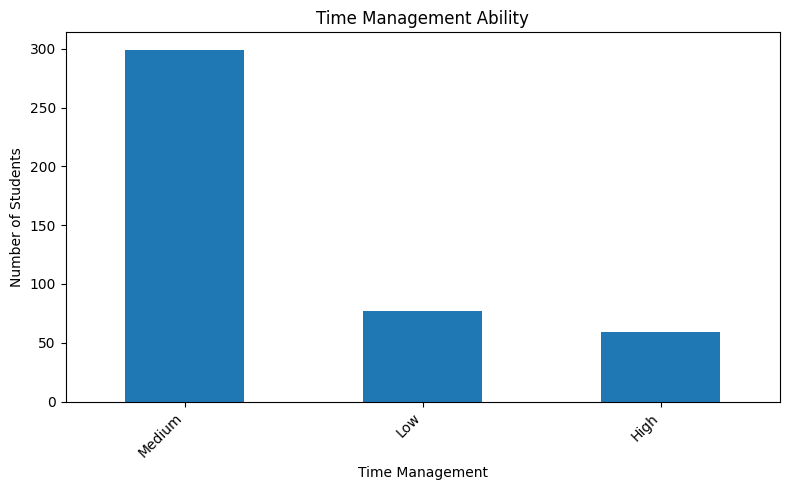

In [33]:
time_management_col = [col for col in df.columns if col.strip().startswith("15.")][0]

print(df[time_management_col].value_counts(dropna=False))

plot_bar(
    time_management_col,
    "Time Management Ability",
    "Time Management"
)


16. Time management ability  
Average    311
Good        62
Poor        62
Name: count, dtype: int64


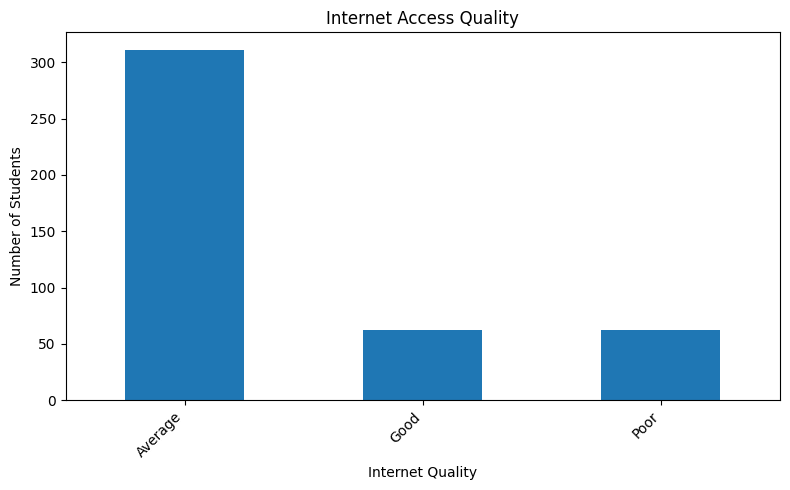

In [34]:
internet_col = [col for col in df.columns if col.strip().startswith("16.")][0]

print(df[internet_col].value_counts(dropna=False))

plot_bar(
    internet_col,
    "Internet Access Quality",
    "Internet Quality"
)

17. Internet access quality for academic work  
Average      203
Good         158
Poor          43
Very good     31
Name: count, dtype: int64


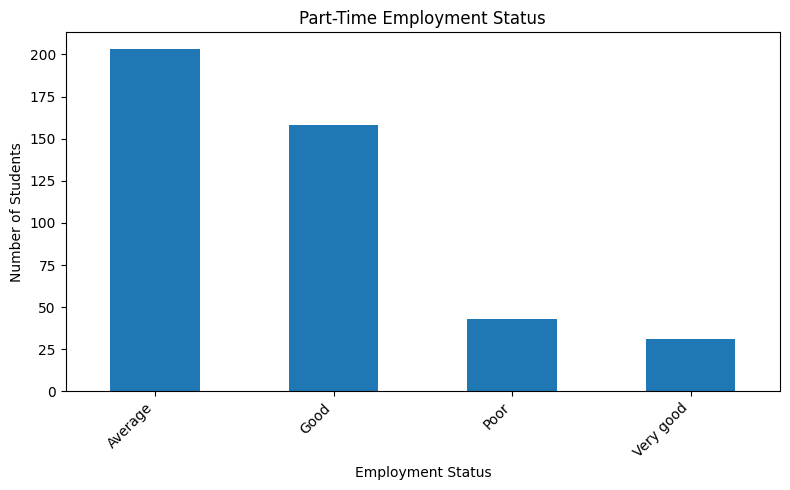

In [35]:
employment_col = [col for col in df.columns if col.strip().startswith("17.")][0]

print(df[employment_col].value_counts(dropna=False))

plot_bar(
    employment_col,
    "Part-Time Employment Status",
    "Employment Status"
)

18. Do you work part-time while studying?  
Yes    283
No     152
Name: count, dtype: int64


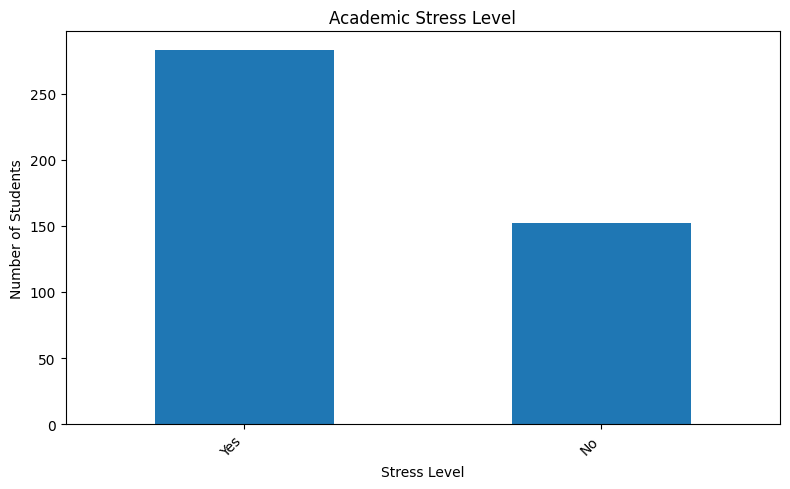

In [36]:
stress_col = [col for col in df.columns if col.strip().startswith("18.")][0]

print(df[stress_col].value_counts(dropna=False))

plot_bar(
    stress_col,
    "Academic Stress Level",
    "Stress Level"
)

19. Academic stress level  
Medium    302
Low        77
High       56
Name: count, dtype: int64


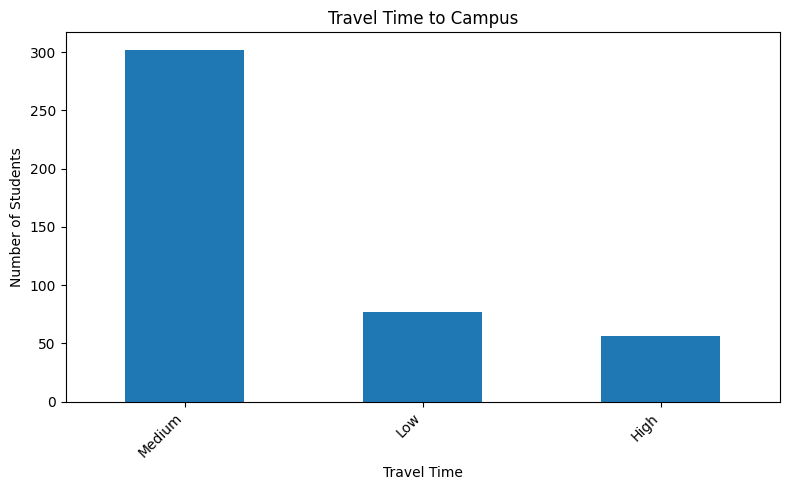

In [37]:
travel_col = [col for col in df.columns if col.strip().startswith("19.")][0]

print(df[travel_col].value_counts(dropna=False))

plot_bar(
    travel_col,
    "Travel Time to Campus",
    "Travel Time"
)

20. Travel time to university / campus  
30 minutesâ€“1 hour     183
1â€“2 hours             131
Less than 30 minutes     95
More than 2 hours        26
Name: count, dtype: int64


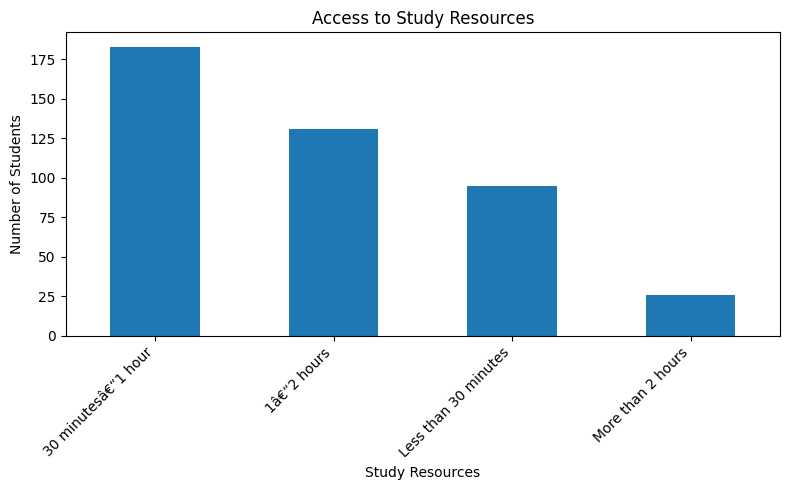

In [38]:
resources_col = [col for col in df.columns if col.strip().startswith("20.")][0]

print(df[resources_col].value_counts(dropna=False))

plot_bar(
    resources_col,
    "Access to Study Resources",
    "Study Resources"
)

21. Access to study resources  
Average      193
Good         162
Poor          61
Very good     19
Name: count, dtype: int64


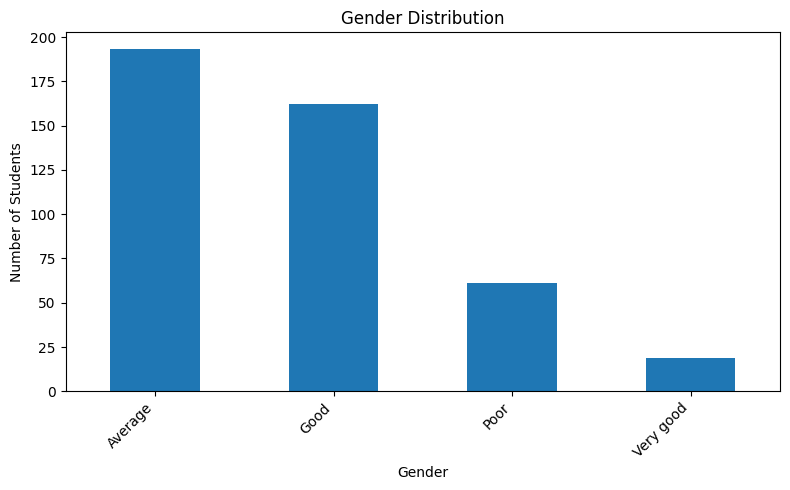

In [39]:
gender_col = [col for col in df.columns if col.strip().startswith("21.")][0]

print(df[gender_col].value_counts(dropna=False))

plot_bar(
    gender_col,
    "Gender Distribution",
    "Gender"
)

22. Your current academic performance level  
Average = 40â€“69 marks     253
Low = below 40 marks        117
High = 70 marks or above     65
Name: count, dtype: int64


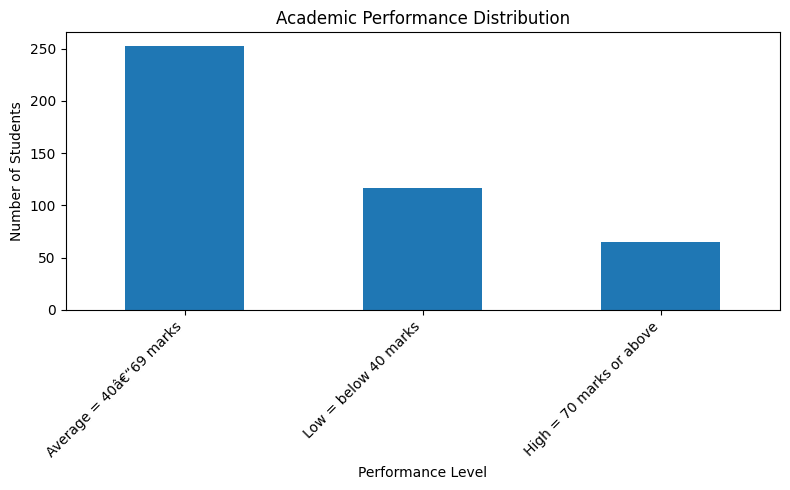

In [40]:
print(df[target_col].value_counts(dropna=False))

plot_bar(
    target_col,
    "Academic Performance Distribution",
    "Performance Level"
)

23. Do you think you currently need academic support or guidance?  
Yes      262
No        91
Maybe     82
Name: count, dtype: int64


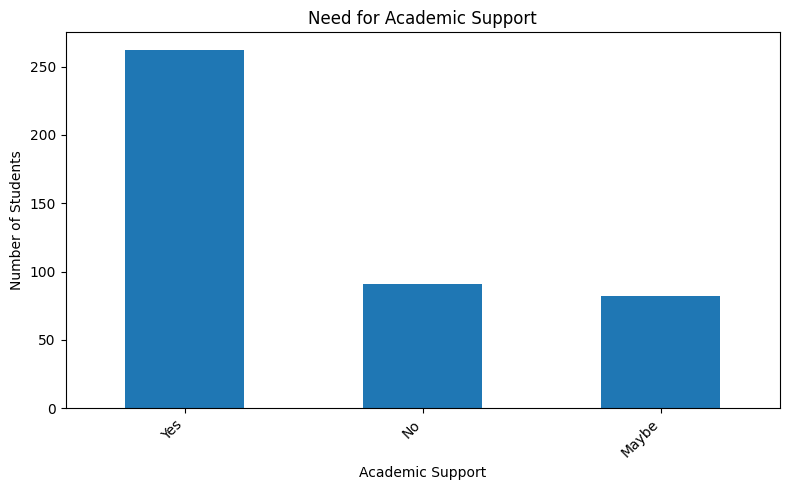

In [41]:
support_col = [col for col in df.columns if col.strip().startswith("23.")][0]

print(df[support_col].value_counts(dropna=False))

plot_bar(
    support_col,
    "Need for Academic Support",
    "Academic Support"
)

23. Do you think you currently need academic support or guidance?  
Yes      262
No        91
Maybe     82
Name: count, dtype: int64


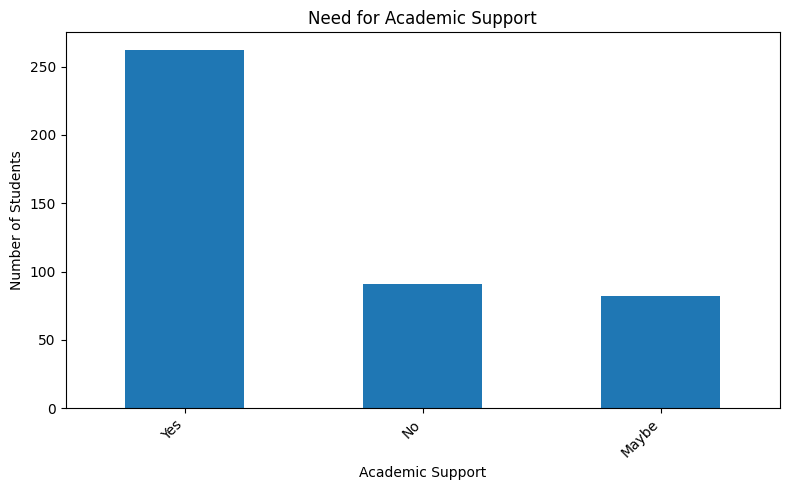

In [42]:
support_col = [col for col in df.columns if col.strip().startswith("23.")][0]

print(df[support_col].value_counts(dropna=False))

plot_bar(
    support_col,
    "Need for Academic Support",
    "Academic Support"
)

In [43]:
attendance_target = pd.crosstab(
    df[attendance_col],
    df[target_col],
    normalize="index"
) * 100

attendance_target.round(2)

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks
7. Gender,,,
Female,59.57,18.30,22.13
Male,56.57,11.11,32.32
Prefer not to say,0.00,0.00,100.00


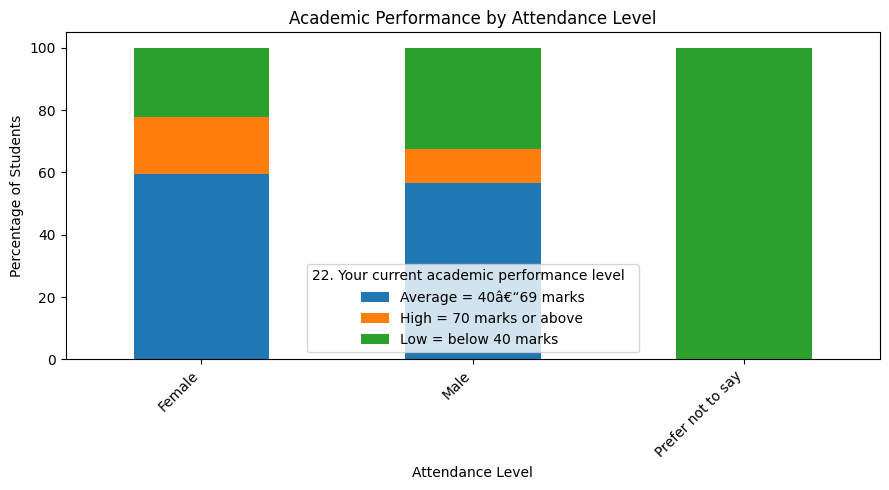

In [44]:
attendance_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Academic Performance by Attendance Level")
plt.xlabel("Attendance Level")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [45]:
study_target = pd.crosstab(
    df[study_hours_col],
    df[target_col],
    normalize="index"
) * 100

study_target.round(2)

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks
8. Average class attendance,,,
50%â€“69%,59.41,8.24,32.35
70%â€“84%,57.49,22.16,20.36
85% and above,53.66,34.15,12.20
Less than 50%,59.65,0.00,40.35


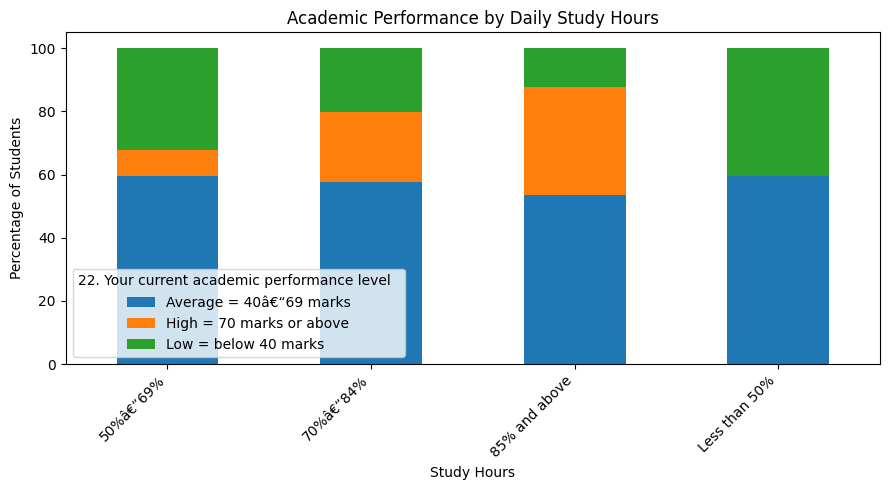

In [46]:
study_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Academic Performance by Daily Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [47]:
motivation_target = pd.crosstab(
    df[motivation_col],
    df[target_col],
    normalize="index"
) * 100

motivation_target.round(2)

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks
14. Average sleep hours per night,,,
5â€“6 hours,59.57,14.78,25.65
7â€“8 hours,64.00,20.80,15.20
Less than 5 hours,47.22,4.17,48.61
More than 8 hours,25.00,25.00,50.00


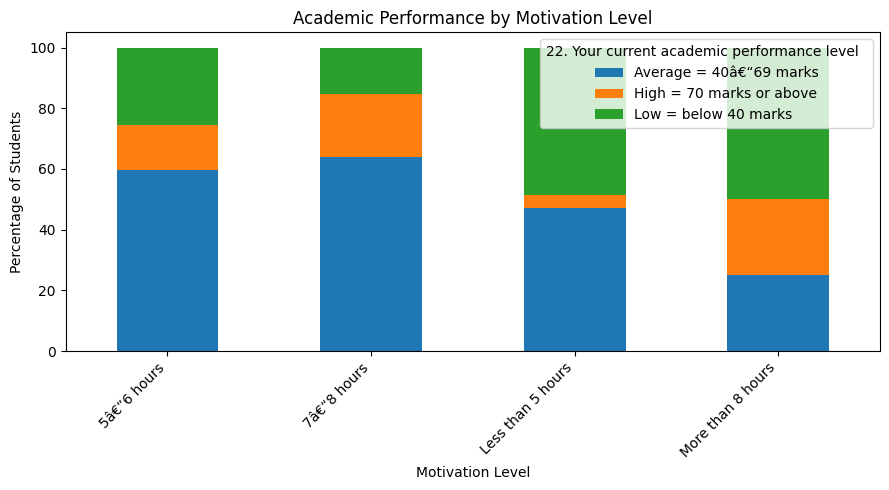

In [48]:
motivation_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Academic Performance by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [49]:
stress_target = pd.crosstab(
    df[stress_col],
    df[target_col],
    normalize="index"
) * 100

stress_target.round(2)

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks
18. Do you work part-time while studying?,,,
No,65.13,27.63,7.24
Yes,54.42,8.13,37.46


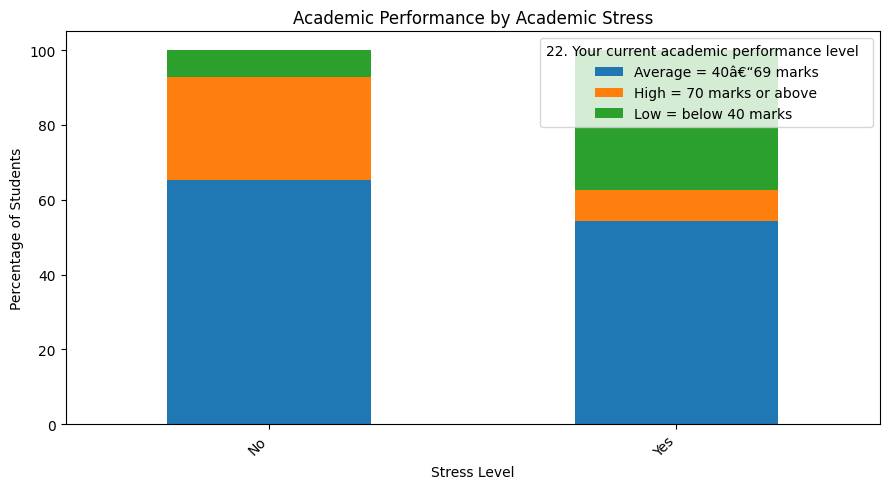

In [50]:
stress_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Academic Performance by Academic Stress")
plt.xlabel("Stress Level")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [51]:
sleep_target = pd.crosstab(
    df[sleep_col],
    df[target_col],
    normalize="index"
) * 100

sleep_target.round(2)

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks
12. Participation in lectures / tutorials / practical sessions,,,
High,54.69,37.50,7.81
Low,49.40,4.82,45.78
Medium,61.46,12.85,25.69


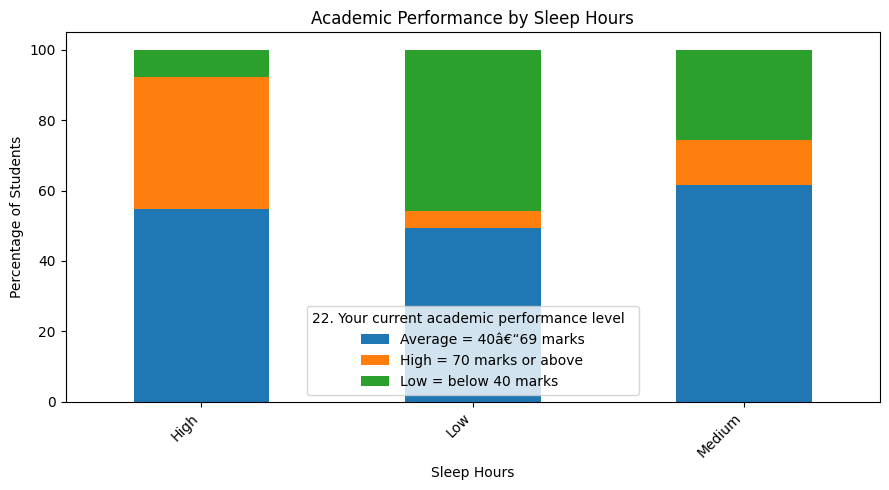

In [52]:
sleep_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Academic Performance by Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [53]:
class_counts = df[target_col].value_counts()
class_percentages = (
    df[target_col].value_counts(normalize=True) * 100
).round(2)

class_balance_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_balance_table

,Count,Percentage
22. Your current academic performance level,,
Average = 40â€“69 marks,253,58.16
Low = below 40 marks,117,26.90
High = 70 marks or above,65,14.94


In [54]:
exploration_summary = pd.DataFrame({
    "Variable": df.columns,
    "Unique_Values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ],
    "Missing_Count": [
        df[col].isnull().sum()
        for col in df.columns
    ],
    "Missing_Percentage": [
        round(df[col].isnull().mean() * 100, 2)
        for col in df.columns
    ]
})

exploration_summary.to_csv(
    "/content/data_exploration_summary.csv",
    index=False
)

print("Saved: data_exploration_summary.csv")

Saved: data_exploration_summary.csv


# **PART 3 — Data Cleaning**

In [55]:
df_clean = df_raw.copy()

print("Raw dataset shape:", df_raw.shape)
print("Cleaning copy shape:", df_clean.shape)

Raw dataset shape: (435, 23)
Cleaning copy shape: (435, 23)


In [56]:
df_clean.columns = (
    df_clean.columns
    .astype(str)
    .str.strip()
)

print("Column names cleaned.")

Column names cleaned.


In [57]:
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Text spacing cleaned.")

Text spacing cleaned.


In [58]:
"  Year 3  "

'  Year 3  '

In [59]:
def find_question(number):
    matches = [
        col for col in df_clean.columns
        if str(col).strip().startswith(f"{number}.")
    ]

    if len(matches) == 0:
        print(f"Question {number} not found")
        return None

    return matches[0]

In [60]:
q1_consent = find_question(1)
q2_student = find_question(2)
q3_institution = find_question(3)
q13_ca = find_question(13)
q22_target = find_question(22)

print("Consent:", q1_consent)
print("Current student:", q2_student)
print("Institution:", q3_institution)
print("CA marks:", q13_ca)
print("Target:", q22_target)

Consent: 1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.
Current student: 2. Are you currently studying at a Sri Lankan university or higher education institute?
Institution: 3. Type of institution
CA marks: 13. Current CA / coursework marks range
Target: 22. Your current academic performance level


In [61]:
print("Q1 CONSENT")
print(df_clean[q1_consent].value_counts(dropna=False))

print("\nQ2 CURRENT STUDENT")
print(df_clean[q2_student].value_counts(dropna=False))

print("\nQ3 INSTITUTION TYPE")
print(df_clean[q3_institution].value_counts(dropna=False))

Q1 CONSENT
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.
I agree to participate    435
Name: count, dtype: Int64

Q2 CURRENT STUDENT
2. Are you currently studying at a Sri Lankan university or higher education institute?
Yes    427
No       8
Name: count, dtype: Int64

Q3 INSTITUTION TYPE
3. Type of institution
Private campus / private higher education institute    404
Government university                                   31
Name: count, dtype: Int64


In [62]:
def normalize_text(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

consent_norm = normalize_text(df_clean[q1_consent])
student_norm = normalize_text(df_clean[q2_student])
institution_norm = normalize_text(df_clean[q3_institution])

In [63]:
print("CONSENT:")
print(consent_norm.value_counts(dropna=False))

print("\nCURRENT STUDENT:")
print(student_norm.value_counts(dropna=False))

print("\nINSTITUTION:")
print(institution_norm.value_counts(dropna=False))

CONSENT:
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.
i agree to participate    435
Name: count, dtype: Int64

CURRENT STUDENT:
2. Are you currently studying at a Sri Lankan university or higher education institute?
yes    427
no       8
Name: count, dtype: Int64

INSTITUTION:
3. Type of institution
private campus / private higher education institute    404
government university                                   31
Name: count, dtype: Int64


In [64]:
eligible_consent = consent_norm.str.contains(
    "yes|agree|consent",
    regex=True,
    na=False
)

eligible_student = student_norm.str.contains(
    "yes",
    regex=True,
    na=False
)

eligible_private = institution_norm.str.contains(
    "private",
    regex=True,
    na=False
)

In [65]:
print("Consent eligible:", eligible_consent.sum())
print("Current students:", eligible_student.sum())
print("Private institution students:", eligible_private.sum())

Consent eligible: 435
Current students: 427
Private institution students: 404


In [66]:
df_clean["Eligible_Consent"] = eligible_consent
df_clean["Eligible_Current_Student"] = eligible_student
df_clean["Eligible_Private_HEI"] = eligible_private

df_clean["Eligible_Basic"] = (
    df_clean["Eligible_Consent"]
    & df_clean["Eligible_Current_Student"]
    & df_clean["Eligible_Private_HEI"]
)

print(df_clean["Eligible_Basic"].value_counts())

Eligible_Basic
True     396
False     39
Name: count, dtype: Int64


In [67]:
print("Missing target values:")
print(df_clean[q22_target].isna().sum())

print("\nTarget categories:")
print(df_clean[q22_target].value_counts(dropna=False))

Missing target values:
0

Target categories:
22. Your current academic performance level
Average = 40â€“69 marks     253
Low = below 40 marks        117
High = 70 marks or above     65
Name: count, dtype: Int64


In [68]:
df_clean["Valid_Target"] = df_clean[q22_target].notna()

df_clean["Eligible_Final"] = (
    df_clean["Eligible_Basic"]
    & df_clean["Valid_Target"]
)

print("Final eligible before duplicate review:")
print(df_clean["Eligible_Final"].value_counts())

Final eligible before duplicate review:
Eligible_Final
True     396
False     39
Name: count, dtype: Int64


In [69]:
screening_flow = pd.DataFrame({
    "Stage": [
        "Raw responses",
        "Consent eligible",
        "Currently studying",
        "Private higher education institution",
        "Basic eligibility satisfied",
        "Valid target available",
        "Final eligible before duplicate review"
    ],
    "N": [
        len(df_clean),
        eligible_consent.sum(),
        eligible_student.sum(),
        eligible_private.sum(),
        df_clean["Eligible_Basic"].sum(),
        df_clean["Valid_Target"].sum(),
        df_clean["Eligible_Final"].sum()
    ]
})

screening_flow

,Stage,N
0,Raw responses,435
1,Consent eligible,435
2,Currently studying,427
3,Private higher education institution,404
4,Basic eligibility satisfied,396
5,Valid target available,435
6,Final eligible before duplicate review,396


In [70]:
timestamp_candidates = [
    col for col in df_clean.columns
    if "timestamp" in str(col).lower()
]

timestamp_candidates

[]

In [71]:
timestamp_col = (
    timestamp_candidates[0]
    if len(timestamp_candidates) > 0
    else None
)

print("Timestamp column:", timestamp_col)

Timestamp column: None


In [72]:
full_duplicates = df_clean.duplicated(keep=False)

print(
    "Rows involved in exact full-row duplicates:",
    full_duplicates.sum()
)

Rows involved in exact full-row duplicates: 0


In [73]:
exclude_duplicate_check = [
    c for c in [
        timestamp_col,
        "Eligible_Consent",
        "Eligible_Current_Student",
        "Eligible_Private_HEI",
        "Eligible_Basic",
        "Valid_Target",
        "Eligible_Final"
    ]
    if c is not None
]

duplicate_columns = [
    col for col in df_clean.columns
    if col not in exclude_duplicate_check
]

content_duplicate_mask = df_clean.duplicated(
    subset=duplicate_columns,
    keep=False
)

print(
    "Rows involved in possible content duplicates:",
    content_duplicate_mask.sum()
)

Rows involved in possible content duplicates: 0


In [74]:
df_clean.insert(
    0,
    "Research_ID",
    range(1, len(df_clean) + 1)
)

df_clean[["Research_ID"]].head()

,Research_ID
0,1
1,2
2,3
3,4
4,5


In [75]:
possible_duplicates = df_clean.loc[
    content_duplicate_mask,
    ["Research_ID"] + (
        [timestamp_col] if timestamp_col else []
    )
]

possible_duplicates

,Research_ID


In [76]:
df_clean["Possible_Duplicate"] = content_duplicate_mask

print(
    df_clean["Possible_Duplicate"].value_counts()
)

Possible_Duplicate
False    435
Name: count, dtype: int64


In [77]:
eligible_temp = df_clean[
    df_clean["Eligible_Final"]
].copy()

missing_eligible = pd.DataFrame({
    "Missing_Count":
        eligible_temp.isna().sum(),

    "Missing_Percentage":
        (
            eligible_temp.isna().mean()
            * 100
        ).round(2)
})

missing_eligible = missing_eligible[
    missing_eligible["Missing_Count"] > 0
]

missing_eligible

,Missing_Count,Missing_Percentage
4. Year of study,1,0.25
6. Study mode,1,0.25
7. Gender,1,0.25


In [78]:
print("CA categories:")
print(df_clean[q13_ca].value_counts(dropna=False))

print("\nTarget categories:")
print(df_clean[q22_target].value_counts(dropna=False))

CA categories:
13. Current CA / coursework marks range
55â€“69         193
40â€“54         100
70 and above    100
Below 40         29
Not sure         13
Name: count, dtype: Int64

Target categories:
22. Your current academic performance level
Average = 40â€“69 marks     253
Low = below 40 marks        117
High = 70 marks or above     65
Name: count, dtype: Int64


In [79]:
ca_target_table = pd.crosstab(
    df_clean[q13_ca],
    df_clean[q22_target],
    margins=True
)

ca_target_table

22. Your current academic performance level,Average = 40â€“69 marks,High = 70 marks or above,Low = below 40 marks,All
13. Current CA / coursework marks range,,,,
40â€“54,58,3,39,100
55â€“69,131,15,47,193
70 and above,45,45,10,100
Below 40,8,0,21,29
Not sure,11,2,0,13
All,253,65,117,435


In [80]:
for col in df_clean.columns:
    if (
        df_clean[col].dtype == "object"
        or str(df_clean[col].dtype) == "string"
    ):
        print("\n", "=" * 80)
        print(col)
        print(
            df_clean[col]
            .value_counts(dropna=False)
            .head(30)
        )


1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.
1. I have read the information above and agree to participate voluntarily in this anonymous academic survey.
I agree to participate    435
Name: count, dtype: Int64

2. Are you currently studying at a Sri Lankan university or higher education institute?
2. Are you currently studying at a Sri Lankan university or higher education institute?
Yes    427
No       8
Name: count, dtype: Int64

3. Type of institution
3. Type of institution
Private campus / private higher education institute    404
Government university                                   31
Name: count, dtype: Int64

4. Year of study
4. Year of study
Year 2    160
Year 3    148
Year 1     88
Year 4     38
<NA>        1
Name: count, dtype: Int64

5. Degree area / study field
5. Degree area / study field
Information Technology / Computing    112
Engineering                            95
Business / Management              

In [81]:
df_eligible = df_clean[
    df_clean["Eligible_Final"]
].copy()

print("Raw responses:", len(df_clean))
print("Eligible responses:", len(df_eligible))
print(
    "Excluded responses:",
    len(df_clean) - len(df_eligible)
)

Raw responses: 435
Eligible responses: 396
Excluded responses: 39


In [82]:
eligible_target_counts = (
    df_eligible[q22_target]
    .value_counts()
)

eligible_target_percentages = (
    df_eligible[q22_target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

eligible_class_table = pd.DataFrame({
    "Count": eligible_target_counts,
    "Percentage": eligible_target_percentages
})

eligible_class_table

,Count,Percentage
22. Your current academic performance level,,
Average = 40â€“69 marks,228,57.58
Low = below 40 marks,110,27.78
High = 70 marks or above,58,14.65


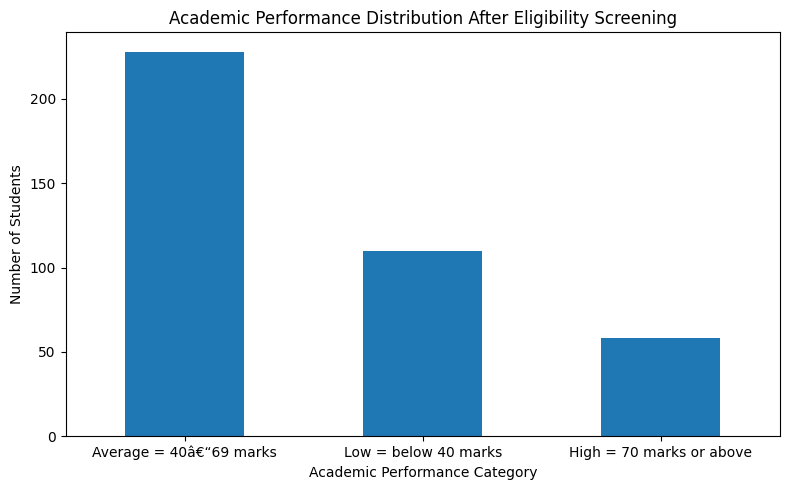

In [83]:
plt.figure(figsize=(8, 5))

eligible_target_counts.plot(
    kind="bar"
)

plt.title(
    "Academic Performance Distribution "
    "After Eligibility Screening"
)

plt.xlabel(
    "Academic Performance Category"
)

plt.ylabel(
    "Number of Students"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [84]:
minimum_class_size = eligible_target_counts.min()

print(
    "Smallest academic-performance class:",
    minimum_class_size
)

Smallest academic-performance class: 58


In [85]:
predictor_question_numbers = [
    4,   # Year of study
    5,   # Degree area
    6,   # Study mode
    7,   # Attendance
    8,   # Study hours
    9,   # LMS usage
    10,  # Assignment submission
    11,  # Academic participation
    12,  # Sleep
    14,  # Motivation
    15,  # Time management
    16,  # Internet quality
    17,  # Part-time employment
    18,  # Academic stress
    19,  # Travel time
    20   # Study resources
]

predictor_columns = [
    find_question(q)
    for q in predictor_question_numbers
]

predictor_columns = [
    col for col in predictor_columns
    if col is not None
]

print(
    "Number of predictors found:",
    len(predictor_columns)
)

for i, col in enumerate(
    predictor_columns,
    start=1
):
    print(i, col)

Number of predictors found: 16
1 4. Year of study
2 5. Degree area / study field
3 6. Study mode
4 7. Gender
5 8. Average class attendance
6 9. Average study hours per day
7 10. How often do you use LMS / online learning platforms for academic work?
8 11. Assignment submission habit
9 12. Participation in lectures / tutorials / practical sessions
10 14. Average sleep hours per night
11 15. Motivation level for studies
12 16. Time management ability
13 17. Internet access quality for academic work
14 18. Do you work part-time while studying?
15 19. Academic stress level
16 20. Travel time to university / campus


In [86]:
predictor_missing = pd.DataFrame({
    "Missing_Count": [
        df_eligible[col]
        .isna()
        .sum()

        for col in predictor_columns
    ],

    "Missing_Percentage": [
        round(
            df_eligible[col]
            .isna()
            .mean()
            * 100,
            2
        )

        for col in predictor_columns
    ]
},
index=predictor_columns)

predictor_missing

,Missing_Count,Missing_Percentage
4. Year of study,1,0.25
5. Degree area / study field,0,0.00
6. Study mode,1,0.25
7. Gender,1,0.25
8. Average class attendance,0,0.00
9. Average study hours per day,0,0.00
10. How often do you use LMS / online learning platforms for academic work?,0,0.00
11. Assignment submission habit,0,0.00
12. Participation in lectures / tutorials / practical sessions,0,0.00
14. Average sleep hours per night,0,0.00


In [87]:
X = df_eligible[
    predictor_columns
].copy()

y = df_eligible[
    q22_target
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (396, 16)
y shape: (396,)

Target distribution:
22. Your current academic performance level
Average = 40â€“69 marks     228
Low = below 40 marks        110
High = 70 marks or above     58
Name: count, dtype: Int64


In [88]:
excluded_questions = {
    "Consent": q1_consent,
    "Current student": q2_student,
    "Institution type": q3_institution,
    "CA marks": q13_ca,
    "Target": q22_target
}

print("Checking excluded variables:\n")

for name, column in excluded_questions.items():
    if column in X.columns:
        print("WARNING:", name, "is inside X")
    else:
        print("Correct:", name, "not in X")

Checking excluded variables:

Correct: Consent not in X
Correct: Current student not in X
Correct: Institution type not in X
Correct: CA marks not in X
Correct: Target not in X


In [89]:
screening_flow.to_csv(
    "/content/participant_screening_flow.csv",
    index=False
)

missing_eligible.to_csv(
    "/content/missing_values_after_screening.csv"
)

eligible_class_table.to_csv(
    "/content/class_distribution_after_screening.csv"
)

predictor_missing.to_csv(
    "/content/predictor_missing_values.csv"
)

print("Cleaning audit files saved.")

Cleaning audit files saved.


In [90]:
df_eligible.to_csv(
    "/content/eligible_cleaned_dataset.csv",
    index=False
)

print(
    "Saved:",
    "/content/eligible_cleaned_dataset.csv"
)

Saved: /content/eligible_cleaned_dataset.csv


# **PART 4 — Prepare Features for Machine Learning.**

In [91]:
def find_question(number):
    matches = [
        col for col in df_clean.columns
        if str(col).strip().startswith(f"{number}.")
    ]

    if len(matches) == 0:
        print(f"Question {number} not found")
        return None

    return matches[0]

print("find_question function is ready.")

find_question function is ready.


In [92]:
feature_map = {
    "year_of_study": find_question(4),
    "degree_area": find_question(5),
    "study_mode": find_question(6),
    "attendance": find_question(7),
    "study_hours": find_question(8),
    "lms_usage": find_question(9),
    "assignment_submission": find_question(10),
    "academic_participation": find_question(11),
    "sleep_hours": find_question(12),
    "motivation": find_question(14),
    "time_management": find_question(15),
    "internet_quality": find_question(16),
    "part_time_employment": find_question(17),
    "academic_stress": find_question(18),
    "travel_time": find_question(19),
    "study_resources": find_question(20)
}

for short_name, original_name in feature_map.items():
    print(short_name, "->", original_name)

year_of_study -> 4. Year of study
degree_area -> 5. Degree area / study field
study_mode -> 6. Study mode
attendance -> 7. Gender
study_hours -> 8. Average class attendance
lms_usage -> 9. Average study hours per day
assignment_submission -> 10. How often do you use LMS / online learning platforms for academic work?
academic_participation -> 11. Assignment submission habit
sleep_hours -> 12. Participation in lectures / tutorials / practical sessions
motivation -> 14. Average sleep hours per night
time_management -> 15. Motivation level for studies
internet_quality -> 16. Time management ability
part_time_employment -> 17. Internet access quality for academic work
academic_stress -> 18. Do you work part-time while studying?
travel_time -> 19. Academic stress level
study_resources -> 20. Travel time to university / campus


In [93]:
X_model = X.copy()

rename_dictionary = {
    original: short
    for short, original in feature_map.items()
}

X_model = X_model.rename(columns=rename_dictionary)

print(X_model.columns.tolist())

['year_of_study', 'degree_area', 'study_mode', 'attendance', 'study_hours', 'lms_usage', 'assignment_submission', 'academic_participation', 'sleep_hours', 'motivation', 'time_management', 'internet_quality', 'part_time_employment', 'academic_stress', 'travel_time', 'study_resources']


In [94]:
print("Number of students:", X_model.shape[0])
print("Number of predictors:", X_model.shape[1])

Number of students: 396
Number of predictors: 16


In [95]:
for col in X_model.columns:
    print("\n" + "=" * 80)
    print("VARIABLE:", col)
    print("=" * 80)

    print(
        X_model[col]
        .value_counts(dropna=False)
    )


VARIABLE: year_of_study
year_of_study
Year 2    155
Year 3    133
Year 1     75
Year 4     32
<NA>        1
Name: count, dtype: Int64

VARIABLE: degree_area
degree_area
Information Technology / Computing    104
Engineering                            90
Business / Management                  87
Science                                55
Arts / Humanities                      25
Education                              23
Other                                  12
Name: count, dtype: Int64

VARIABLE: study_mode
study_mode
Full-time    362
Part-time     33
<NA>           1
Name: count, dtype: Int64

VARIABLE: attendance
attendance
Female    217
Male      178
<NA>        1
Name: count, dtype: Int64

VARIABLE: study_hours
study_hours
50%â€“69%        166
70%â€“84%        150
Less than 50%     52
85% and above     28
Name: count, dtype: Int64

VARIABLE: lms_usage
lms_usage
1â€“2 hours          175
3â€“4 hours          143
Less than 1 hour      59
More than 4 hours     19
Name: count, dtype: Int

In [96]:
nominal_features = [
    "degree_area",
    "study_mode"
]

ordinal_features = [
    "year_of_study",
    "attendance",
    "study_hours",
    "lms_usage",
    "assignment_submission",
    "academic_participation",
    "sleep_hours",
    "motivation",
    "time_management",
    "internet_quality",
    "academic_stress",
    "travel_time",
    "study_resources"
]

binary_features = [
    "part_time_employment"
]

print("Nominal:", len(nominal_features))
print("Ordinal:", len(ordinal_features))
print("Binary:", len(binary_features))

print(
    "Total:",
    len(nominal_features)
    + len(ordinal_features)
    + len(binary_features)
)

Nominal: 2
Ordinal: 13
Binary: 1
Total: 16


In [97]:
print("NOMINAL FEATURES")
print(
    X_model[nominal_features]
    .isna()
    .sum()
)

print("\nORDINAL FEATURES")
print(
    X_model[ordinal_features]
    .isna()
    .sum()
)

print("\nBINARY FEATURES")
print(
    X_model[binary_features]
    .isna()
    .sum()
)

NOMINAL FEATURES
degree_area    0
study_mode     1
dtype: int64

ORDINAL FEATURES
year_of_study             1
attendance                1
study_hours               0
lms_usage                 0
assignment_submission     0
academic_participation    0
sleep_hours               0
motivation                0
time_management           0
internet_quality          0
academic_stress           0
travel_time               0
study_resources           0
dtype: int64

BINARY FEATURES
part_time_employment    0
dtype: int64


In [98]:
for col in ordinal_features:
    print("\n" + "=" * 70)
    print(col.upper())
    print("=" * 70)

    unique_values = (
        X_model[col]
        .dropna()
        .unique()
        .tolist()
    )

    for value in unique_values:
        print(repr(value))


YEAR_OF_STUDY
'Year 3'
'Year 4'
'Year 2'
'Year 1'

ATTENDANCE
'Male'
'Female'

STUDY_HOURS
'85% and above'
'70%â€“84%'
'50%â€“69%'
'Less than 50%'

LMS_USAGE
'3â€“4 hours'
'More than 4 hours'
'1â€“2 hours'
'Less than 1 hour'

ASSIGNMENT_SUBMISSION
'Often'
'Sometimes'
'Rarely'
'Very often'

ACADEMIC_PARTICIPATION
'Always on time'
'Usually on time'
'Sometimes late'
'Usually late'

SLEEP_HOURS
'High'
'Medium'
'Low'

MOTIVATION
'7â€“8 hours'
'5â€“6 hours'
'Less than 5 hours'
'More than 8 hours'

TIME_MANAGEMENT
'Medium'
'High'
'Low'

INTERNET_QUALITY
'Average'
'Good'
'Poor'

ACADEMIC_STRESS
'No'
'Yes'

TRAVEL_TIME
'High'
'Medium'
'Low'

STUDY_RESOURCES
'More than 2 hours'
'Less than 30 minutes'
'30 minutesâ€“1 hour'
'1â€“2 hours'


In [99]:
for col in nominal_features:
    print("\n" + "=" * 70)
    print(col.upper())
    print("=" * 70)

    print(
        X_model[col]
        .value_counts(dropna=False)
    )


DEGREE_AREA
degree_area
Information Technology / Computing    104
Engineering                            90
Business / Management                  87
Science                                55
Arts / Humanities                      25
Education                              23
Other                                  12
Name: count, dtype: Int64

STUDY_MODE
study_mode
Full-time    362
Part-time     33
<NA>           1
Name: count, dtype: Int64


In [100]:
print(
    X_model["part_time_employment"]
    .value_counts(dropna=False)
)

part_time_employment
Average      189
Good         139
Poor          40
Very good     28
Name: count, dtype: Int64


In [101]:
y_model = y.copy()

print("Original target categories:")
print(y_model.value_counts(dropna=False))

Original target categories:
22. Your current academic performance level
Average = 40â€“69 marks     228
Low = below 40 marks        110
High = 70 marks or above     58
Name: count, dtype: Int64


In [102]:
print(
    y_model.unique()
)

<StringArray>
['High = 70 marks or above', 'Average = 40â€“69 marks',
 'Low = below 40 marks']
Length: 3, dtype: string


In [103]:
def convert_target(value):

    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip()

    if "below" in text or "<40" in text:
        return "Low"

    elif "40" in text and (
        "69" in text
        or "average" in text
    ):
        return "Average"

    elif (
        "70" in text
        or "above" in text
        or "high" in text
    ):
        return "High"

    return value


y_model = y_model.apply(convert_target)

print(
    y_model.value_counts(dropna=False)
)

22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64


In [104]:
target_mapping = {
    "Low": 0,
    "Average": 1,
    "High": 2
}

y_encoded = y_model.map(target_mapping)

print(
    y_encoded.value_counts()
)

22. Your current academic performance level
1    228
0    110
2     58
Name: count, dtype: int64


In [105]:
print(
    "Missing encoded targets:",
    y_encoded.isna().sum()
)

Missing encoded targets: 0


In [106]:
target_mapping_table = pd.DataFrame({
    "Performance_Level": [
        "Low",
        "Average",
        "High"
    ],
    "Encoded_Value": [
        0,
        1,
        2
    ]
})

target_mapping_table

,Performance_Level,Encoded_Value
0,Low,0
1,Average,1
2,High,2


In [107]:
print("X shape:", X_model.shape)
print("y shape:", y_encoded.shape)

print("\nX missing cells:")
print(X_model.isna().sum().sum())

print("\ny missing values:")
print(y_encoded.isna().sum())

print("\nTarget distribution:")
print(y_model.value_counts())

print("\nTarget percentages:")
print(
    (
        y_model.value_counts(normalize=True)
        * 100
    ).round(2)
)

X shape: (396, 16)
y shape: (396,)

X missing cells:
3

y missing values:
0

Target distribution:
22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64

Target percentages:
22. Your current academic performance level
Average    57.58
Low        27.78
High       14.65
Name: proportion, dtype: float64


In [108]:
feature_information = pd.DataFrame({
    "Feature": X_model.columns,
    "Feature_Type": [
        "Nominal"
        if col in nominal_features

        else "Ordinal"
        if col in ordinal_features

        else "Binary"

        for col in X_model.columns
    ]
})

feature_information

,Feature,Feature_Type
0,year_of_study,Ordinal
1,degree_area,Nominal
2,study_mode,Nominal
3,attendance,Ordinal
4,study_hours,Ordinal
5,lms_usage,Ordinal
6,assignment_submission,Ordinal
7,academic_participation,Ordinal
8,sleep_hours,Ordinal
9,motivation,Ordinal


In [109]:
feature_information.to_csv(
    "/content/feature_information.csv",
    index=False
)

print("Saved feature_information.csv")

Saved feature_information.csv


# **PART 5A — Correct the 16 predictors**

In [110]:
feature_map = {
    "year_of_study": find_question(4),
    "degree_area": find_question(5),
    "study_mode": find_question(6),

    # Q7 is Gender -> excluded from modelling

    "attendance": find_question(8),
    "study_hours": find_question(9),
    "lms_usage": find_question(10),
    "assignment_submission": find_question(11),
    "academic_participation": find_question(12),

    # Q13 is CA marks -> excluded because of leakage

    "sleep_hours": find_question(14),
    "motivation": find_question(15),
    "time_management": find_question(16),
    "internet_quality": find_question(17),
    "part_time_employment": find_question(18),
    "academic_stress": find_question(19),
    "travel_time": find_question(20),
    "study_resources": find_question(21)
}

print("Number of predictors:", len(feature_map))

for short_name, original_name in feature_map.items():
    print(short_name, "->", original_name)

Number of predictors: 16
year_of_study -> 4. Year of study
degree_area -> 5. Degree area / study field
study_mode -> 6. Study mode
attendance -> 8. Average class attendance
study_hours -> 9. Average study hours per day
lms_usage -> 10. How often do you use LMS / online learning platforms for academic work?
assignment_submission -> 11. Assignment submission habit
academic_participation -> 12. Participation in lectures / tutorials / practical sessions
sleep_hours -> 14. Average sleep hours per night
motivation -> 15. Motivation level for studies
time_management -> 16. Time management ability
internet_quality -> 17. Internet access quality for academic work
part_time_employment -> 18. Do you work part-time while studying?
academic_stress -> 19. Academic stress level
travel_time -> 20. Travel time to university / campus
study_resources -> 21. Access to study resources


In [111]:
predictor_columns = list(feature_map.values())

X = df_eligible[predictor_columns].copy()

rename_dictionary = {
    original: short
    for short, original in feature_map.items()
}

X_model = X.rename(columns=rename_dictionary)

print("X shape:", X_model.shape)

print("\nPredictors:")
for col in X_model.columns:
    print(col)

X shape: (396, 16)

Predictors:
year_of_study
degree_area
study_mode
attendance
study_hours
lms_usage
assignment_submission
academic_participation
sleep_hours
motivation
time_management
internet_quality
part_time_employment
academic_stress
travel_time
study_resources


In [112]:
def fix_encoding_text(value):
    if pd.isna(value):
        return value

    if isinstance(value, str):
        value = value.replace("â€“", "–")
        value = value.replace("â€”", "—")
        value = value.strip()

    return value


for col in X_model.columns:
    X_model[col] = X_model[col].apply(fix_encoding_text)

y_model = y.copy().apply(fix_encoding_text)

print("Encoding cleanup complete.")

Encoding cleanup complete.


In [113]:
for col in X_model.columns:
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)

    print(
        X_model[col]
        .value_counts(dropna=False)
    )


year_of_study
year_of_study
Year 2    155
Year 3    133
Year 1     75
Year 4     32
<NA>        1
Name: count, dtype: int64

degree_area
degree_area
Information Technology / Computing    104
Engineering                            90
Business / Management                  87
Science                                55
Arts / Humanities                      25
Education                              23
Other                                  12
Name: count, dtype: int64

study_mode
study_mode
Full-time    362
Part-time     33
<NA>           1
Name: count, dtype: int64

attendance
attendance
50%–69%          166
70%–84%          150
Less than 50%     52
85% and above     28
Name: count, dtype: int64

study_hours
study_hours
1–2 hours            175
3–4 hours            143
Less than 1 hour      59
More than 4 hours     19
Name: count, dtype: int64

lms_usage
lms_usage
Sometimes     203
Often         129
Rarely         40
Very often     24
Name: count, dtype: int64

assignment_submission
assi

In [114]:
nominal_features = [
    "degree_area",
    "study_mode"
]

ordinal_features = [
    "year_of_study",
    "attendance",
    "study_hours",
    "lms_usage",
    "assignment_submission",
    "academic_participation",
    "sleep_hours",
    "motivation",
    "time_management",
    "internet_quality",
    "academic_stress",
    "travel_time",
    "study_resources"
]

binary_features = [
    "part_time_employment"
]

print("Nominal:", len(nominal_features))
print("Ordinal:", len(ordinal_features))
print("Binary:", len(binary_features))

print(
    "Total:",
    len(nominal_features)
    + len(ordinal_features)
    + len(binary_features)
)

Nominal: 2
Ordinal: 13
Binary: 1
Total: 16


In [115]:
ordinal_categories = [

    # year_of_study
    [
        "Year 1",
        "Year 2",
        "Year 3",
        "Year 4"
    ],

    # attendance
    [
        "Less than 50%",
        "50%–69%",
        "70%–84%",
        "85% and above"
    ],

    # study_hours
    [
        "Less than 1 hour",
        "1–2 hours",
        "3–4 hours",
        "More than 4 hours"
    ],

    # lms_usage
    [
        "Rarely",
        "Sometimes",
        "Often",
        "Very often"
    ],

    # assignment_submission
    [
        "Usually late",
        "Sometimes late",
        "Usually on time",
        "Always on time"
    ],

    # academic_participation
    [
        "Low",
        "Medium",
        "High"
    ],

    # sleep_hours
    [
        "Less than 5 hours",
        "5–6 hours",
        "7–8 hours",
        "More than 8 hours"
    ],

    # motivation
    [
        "Low",
        "Medium",
        "High"
    ],

    # time_management
    [
        "Poor",
        "Average",
        "Good"
    ],

    # internet_quality
    [
        "Poor",
        "Average",
        "Good",
        "Very good"
    ],

    # academic_stress
    [
        "Low",
        "Medium",
        "High"
    ],

    # travel_time
    [
        "Less than 30 minutes",
        "30 minutes–1 hour",
        "1–2 hours",
        "More than 2 hours"
    ],

    # study_resources
    [
        "Poor",
        "Average",
        "Good",
        "Very good"
    ]
]

In [116]:
for feature, expected_categories in zip(
    ordinal_features,
    ordinal_categories
):
    actual_categories = set(
        X_model[feature]
        .dropna()
        .unique()
    )

    expected_categories = set(expected_categories)

    unexpected = (
        actual_categories
        - expected_categories
    )

    print("\n", feature)

    if len(unexpected) == 0:
        print("OK - all categories recognised")
    else:
        print(
            "WARNING - unexpected categories:",
            unexpected
        )


 year_of_study
OK - all categories recognised

 attendance
OK - all categories recognised

 study_hours
OK - all categories recognised

 lms_usage
OK - all categories recognised

 assignment_submission
OK - all categories recognised

 academic_participation
OK - all categories recognised

 sleep_hours
OK - all categories recognised

 motivation
OK - all categories recognised

 time_management
OK - all categories recognised

 internet_quality
OK - all categories recognised

 academic_stress
OK - all categories recognised

 travel_time
OK - all categories recognised

 study_resources
OK - all categories recognised


In [117]:
def clean_target(value):

    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip()

    if text.startswith("low"):
        return "Low"

    elif text.startswith("average"):
        return "Average"

    elif text.startswith("high"):
        return "High"

    else:
        return np.nan


y_model = y.apply(fix_encoding_text)
y_model = y_model.apply(clean_target)

print(y_model.value_counts(dropna=False))

22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64


In [118]:
target_mapping = {
    "Low": 0,
    "Average": 1,
    "High": 2
}

y_encoded = y_model.map(target_mapping)

print("Target distribution:")
print(y_model.value_counts())

print("\nEncoded distribution:")
print(y_encoded.value_counts())

print(
    "\nMissing encoded targets:",
    y_encoded.isna().sum()
)

Target distribution:
22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64

Encoded distribution:
22. Your current academic performance level
1    228
0    110
2     58
Name: count, dtype: int64

Missing encoded targets: 0


In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

print("Scikit-learn preprocessing tools imported.")

Scikit-learn preprocessing tools imported.


In [120]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Nominal pipeline ready.")

Nominal pipeline ready.


In [121]:
ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

print("Ordinal pipeline ready.")

Ordinal pipeline ready.


In [122]:
binary_categories = [
    ["No", "Yes"]
]

binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "binary_encoder",
            OrdinalEncoder(
                categories=binary_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

print("Binary pipeline ready.")

Binary pipeline ready.


In [123]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "nominal",
            nominal_pipeline,
            nominal_features
        ),

        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        ),

        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],

    remainder="drop"
)

print(
    "Tree preprocessing pipeline ready."
)

Tree preprocessing pipeline ready.


In [124]:
lr_preprocessor = Pipeline(
    steps=[
        (
            "column_transformer",
            ColumnTransformer(
                transformers=[
                    (
                        "nominal",
                        nominal_pipeline,
                        nominal_features
                    ),

                    (
                        "ordinal",
                        ordinal_pipeline,
                        ordinal_features
                    ),

                    (
                        "binary",
                        binary_pipeline,
                        binary_features
                    )
                ],

                remainder="drop"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

print(
    "Logistic Regression preprocessing pipeline ready."
)

Logistic Regression preprocessing pipeline ready.


In [125]:
from sklearn.model_selection import train_test_split

X_temp_train, X_temp_test, y_temp_train, y_temp_test = (
    train_test_split(
        X_model,
        y_encoded,
        test_size=0.20,
        stratify=y_encoded,
        random_state=42
    )
)

print("Temporary train:", X_temp_train.shape)
print("Temporary test:", X_temp_test.shape)

Temporary train: (316, 16)
Temporary test: (80, 16)


In [126]:
# Fix pandas StringDtype / pd.NA compatibility with scikit-learn

X_model = X_model.astype(object)

X_model = X_model.replace({
    pd.NA: np.nan
})

print("Missing-value format fixed.")

print("\nTotal missing values:")
print(X_model.isna().sum().sum())

Missing-value format fixed.

Total missing values:
2


In [127]:
from sklearn.model_selection import train_test_split

X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
    X_model,
    y_encoded,
    test_size=0.20,
    stratify=y_encoded,
    random_state=42
)

print("Temporary train:", X_temp_train.shape)
print("Temporary test:", X_temp_test.shape)

Temporary train: (316, 16)
Temporary test: (80, 16)


In [128]:
X_tree_test = tree_preprocessor.fit_transform(
    X_temp_train
)

print(
    "Tree transformed shape:",
    X_tree_test.shape
)

print(
    "Any missing values:",
    np.isnan(X_tree_test.astype(float)).any()
)

Tree transformed shape: (316, 23)
Any missing values: False


In [129]:
X_lr_test = lr_preprocessor.fit_transform(
    X_temp_train
)

print(
    "LR transformed shape:",
    X_lr_test.shape
)

print(
    "Any missing values:",
    np.isnan(X_lr_test.astype(float)).any()
)

LR transformed shape: (316, 23)
Any missing values: False


In [130]:
final_class_check = pd.DataFrame({
    "Count":
        y_model.value_counts(),

    "Percentage":
        (
            y_model
            .value_counts(normalize=True)
            * 100
        ).round(2)
})

final_class_check

,Count,Percentage
22. Your current academic performance level,,
Average,228,57.58
Low,110,27.78
High,58,14.65


In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Machine-learning tools imported.")

Machine-learning tools imported.


In [132]:
class_counts = y_encoded.value_counts().sort_index()

print("Target class counts:")
print(class_counts)

minimum_class_size = class_counts.min()

print("\nSmallest class size:", minimum_class_size)

Target class counts:
22. Your current academic performance level
0    110
1    228
2     58
Name: count, dtype: int64

Smallest class size: 58


In [133]:
if minimum_class_size >= 5:
    n_splits = 5
elif minimum_class_size >= 3:
    n_splits = 3
else:
    raise ValueError(
        "A target class has fewer than 3 students. "
        "Cross-validation is not reliable."
    )

print("\nNumber of CV folds selected:", n_splits)


Number of CV folds selected: 5


In [134]:
cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

print(
    f"Stratified {n_splits}-Fold Cross-Validation ready."
)

Stratified 5-Fold Cross-Validation ready.


In [135]:
baseline_lr = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(lr_preprocessor)
        ),
        (
            "model",
            LogisticRegression(
                C=1.0,
                penalty="l2",
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Baseline Logistic Regression ready.")

Baseline Logistic Regression ready.


In [136]:
baseline_dt = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(tree_preprocessor)
        ),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Baseline Decision Tree ready.")

Baseline Decision Tree ready.


In [137]:
baseline_rf = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(tree_preprocessor)
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Baseline Random Forest ready.")

Baseline Random Forest ready.


In [138]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

print("Evaluation metrics ready.")

Evaluation metrics ready.


In [139]:
baseline_models = {
    "Logistic Regression": baseline_lr,
    "Decision Tree": baseline_dt,
    "Random Forest": baseline_rf
}

print("Models ready:")

for name in baseline_models:
    print("-", name)

Models ready:
- Logistic Regression
- Decision Tree
- Random Forest


In [140]:
baseline_cv_results = {}

for model_name, model in baseline_models.items():

    print("\nRunning:", model_name)

    result = cross_validate(
        model,
        X_model,
        y_encoded,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    baseline_cv_results[model_name] = result

    print("Completed:", model_name)


Running: Logistic Regression
Completed: Logistic Regression

Running: Decision Tree
Completed: Decision Tree

Running: Random Forest
Completed: Random Forest


In [141]:
baseline_summary = []

for model_name, result in baseline_cv_results.items():

    baseline_summary.append({
        "Model": model_name,

        "Accuracy_Mean":
            result["test_accuracy"].mean(),

        "Accuracy_SD":
            result["test_accuracy"].std(),

        "Macro_Precision_Mean":
            result["test_precision_macro"].mean(),

        "Macro_Precision_SD":
            result["test_precision_macro"].std(),

        "Macro_Recall_Mean":
            result["test_recall_macro"].mean(),

        "Macro_Recall_SD":
            result["test_recall_macro"].std(),

        "Macro_F1_Mean":
            result["test_f1_macro"].mean(),

        "Macro_F1_SD":
            result["test_f1_macro"].std()
    })


baseline_results_df = pd.DataFrame(
    baseline_summary
)

baseline_results_df.round(4)

,Model,Accuracy_Mean,Accuracy_SD,Macro_Precision_Mean,Macro_Precision_SD,Macro_Recall_Mean,Macro_Recall_SD,Macro_F1_Mean,Macro_F1_SD
0,Logistic Regression,0.6087,0.0479,0.5774,0.0466,0.6357,0.0579,0.5856,0.0482
1,Decision Tree,0.5885,0.0578,0.5105,0.0863,0.5103,0.0779,0.5080,0.0801
2,Random Forest,0.6668,0.0551,0.6493,0.0774,0.5522,0.0525,0.5732,0.0595


In [142]:
baseline_ranked = (
    baseline_results_df
    .sort_values(
        by="Macro_F1_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_ranked.round(4)

,Model,Accuracy_Mean,Accuracy_SD,Macro_Precision_Mean,Macro_Precision_SD,Macro_Recall_Mean,Macro_Recall_SD,Macro_F1_Mean,Macro_F1_SD
0,Logistic Regression,0.6087,0.0479,0.5774,0.0466,0.6357,0.0579,0.5856,0.0482
1,Random Forest,0.6668,0.0551,0.6493,0.0774,0.5522,0.0525,0.5732,0.0595
2,Decision Tree,0.5885,0.0578,0.5105,0.0863,0.5103,0.0779,0.5080,0.0801


In [143]:
baseline_display = pd.DataFrame()

baseline_display["Model"] = baseline_results_df["Model"]

baseline_display["Accuracy"] = (
    baseline_results_df["Accuracy_Mean"].round(3).astype(str)
    + " ± "
    + baseline_results_df["Accuracy_SD"].round(3).astype(str)
)

baseline_display["Macro Precision"] = (
    baseline_results_df["Macro_Precision_Mean"].round(3).astype(str)
    + " ± "
    + baseline_results_df["Macro_Precision_SD"].round(3).astype(str)
)

baseline_display["Macro Recall"] = (
    baseline_results_df["Macro_Recall_Mean"].round(3).astype(str)
    + " ± "
    + baseline_results_df["Macro_Recall_SD"].round(3).astype(str)
)

baseline_display["Macro F1"] = (
    baseline_results_df["Macro_F1_Mean"].round(3).astype(str)
    + " ± "
    + baseline_results_df["Macro_F1_SD"].round(3).astype(str)
)

baseline_display

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.609 ± 0.048,0.577 ± 0.047,0.636 ± 0.058,0.586 ± 0.048
1,Decision Tree,0.588 ± 0.058,0.51 ± 0.086,0.51 ± 0.078,0.508 ± 0.08
2,Random Forest,0.667 ± 0.055,0.649 ± 0.077,0.552 ± 0.053,0.573 ± 0.06


In [144]:
overfitting_results = []

for model_name, result in baseline_cv_results.items():

    train_f1 = result["train_f1_macro"].mean()
    validation_f1 = result["test_f1_macro"].mean()

    gap = train_f1 - validation_f1

    overfitting_results.append({
        "Model": model_name,
        "Training_Macro_F1": train_f1,
        "Validation_Macro_F1": validation_f1,
        "Train_Validation_Gap": gap
    })


overfitting_df = pd.DataFrame(
    overfitting_results
)

overfitting_df.round(4)

,Model,Training_Macro_F1,Validation_Macro_F1,Train_Validation_Gap
0,Logistic Regression,0.6734,0.5856,0.0878
1,Decision Tree,0.9983,0.5080,0.4903
2,Random Forest,0.9983,0.5732,0.4251


In [145]:
baseline_oof_predictions = {}

for model_name, model in baseline_models.items():

    print("Generating predictions:", model_name)

    predictions = cross_val_predict(
        model,
        X_model,
        y_encoded,
        cv=cv,
        method="predict",
        n_jobs=-1
    )

    baseline_oof_predictions[
        model_name
    ] = predictions

print("\nOut-of-fold predictions completed.")

Generating predictions: Logistic Regression
Generating predictions: Decision Tree
Generating predictions: Random Forest

Out-of-fold predictions completed.


In [146]:
class_recall_results = []

for model_name, predictions in baseline_oof_predictions.items():

    recalls = recall_score(
        y_encoded,
        predictions,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    class_recall_results.append({
        "Model": model_name,
        "Low_Recall": recalls[0],
        "Average_Recall": recalls[1],
        "High_Recall": recalls[2]
    })


class_recall_df = pd.DataFrame(
    class_recall_results
)

class_recall_df.round(4)

,Model,Low_Recall,Average_Recall,High_Recall
0,Logistic Regression,0.7182,0.5482,0.6379
1,Decision Tree,0.5636,0.6754,0.2931
2,Random Forest,0.4636,0.8465,0.3448


In [147]:
print("LOGISTIC REGRESSION")

print(
    classification_report(
        y_encoded,
        baseline_oof_predictions[
            "Logistic Regression"
        ],
        labels=[0, 1, 2],
        target_names=[
            "Low",
            "Average",
            "High"
        ],
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Low     0.5896    0.7182    0.6475       110
     Average     0.7485    0.5482    0.6329       228
        High     0.3895    0.6379    0.4837        58

    accuracy                         0.6086       396
   macro avg     0.5758    0.6348    0.5880       396
weighted avg     0.6518    0.6086    0.6151       396



In [148]:
print("DECISION TREE")

print(
    classification_report(
        y_encoded,
        baseline_oof_predictions[
            "Decision Tree"
        ],
        labels=[0, 1, 2],
        target_names=[
            "Low",
            "Average",
            "High"
        ],
        digits=4,
        zero_division=0
    )
)

DECISION TREE
              precision    recall  f1-score   support

         Low     0.5487    0.5636    0.5561       110
     Average     0.6667    0.6754    0.6710       228
        High     0.3269    0.2931    0.3091        58

    accuracy                         0.5884       396
   macro avg     0.5141    0.5107    0.5121       396
weighted avg     0.5841    0.5884    0.5861       396



In [149]:
print("RANDOM FOREST")

print(
    classification_report(
        y_encoded,
        baseline_oof_predictions[
            "Random Forest"
        ],
        labels=[0, 1, 2],
        target_names=[
            "Low",
            "Average",
            "High"
        ],
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

         Low     0.7083    0.4636    0.5604       110
     Average     0.6725    0.8465    0.7495       228
        High     0.5405    0.3448    0.4211        58

    accuracy                         0.6667       396
   macro avg     0.6404    0.5517    0.5770       396
weighted avg     0.6631    0.6667    0.6489       396



In [150]:
cm_lr = confusion_matrix(
    y_encoded,
    baseline_oof_predictions[
        "Logistic Regression"
    ],
    labels=[0, 1, 2]
)

print(cm_lr)

[[ 79  25   6]
 [ 51 125  52]
 [  4  17  37]]


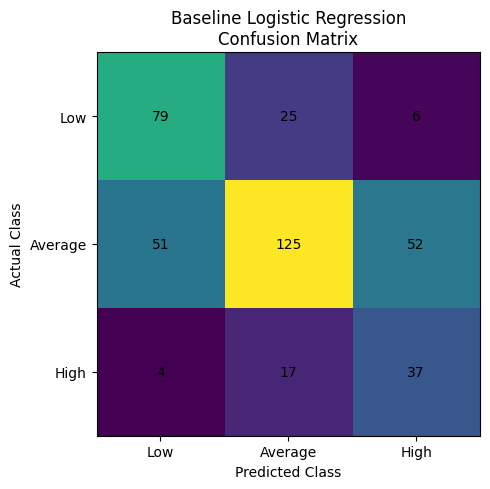

In [151]:
fig, ax = plt.subplots(figsize=(6, 5))

display_matrix = ax.imshow(cm_lr)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])

ax.set_xticklabels(
    ["Low", "Average", "High"]
)

ax.set_yticklabels(
    ["Low", "Average", "High"]
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "Baseline Logistic Regression\nConfusion Matrix"
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            cm_lr[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [152]:
cm_dt = confusion_matrix(
    y_encoded,
    baseline_oof_predictions[
        "Decision Tree"
    ],
    labels=[0, 1, 2]
)

print(cm_dt)

[[ 62  43   5]
 [ 44 154  30]
 [  7  34  17]]


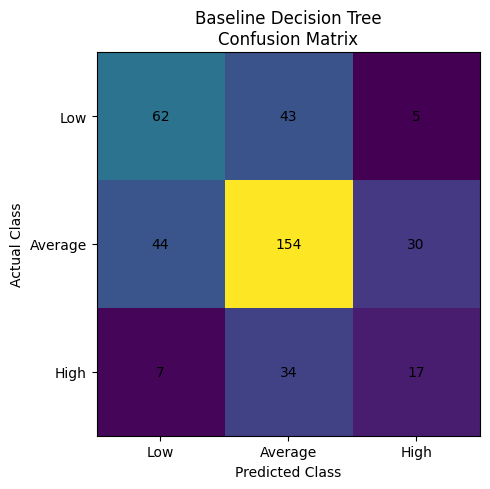

In [153]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_dt)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])

ax.set_xticklabels(
    ["Low", "Average", "High"]
)

ax.set_yticklabels(
    ["Low", "Average", "High"]
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "Baseline Decision Tree\nConfusion Matrix"
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            cm_dt[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [154]:
cm_rf = confusion_matrix(
    y_encoded,
    baseline_oof_predictions[
        "Random Forest"
    ],
    labels=[0, 1, 2]
)

print(cm_rf)

[[ 51  57   2]
 [ 20 193  15]
 [  1  37  20]]


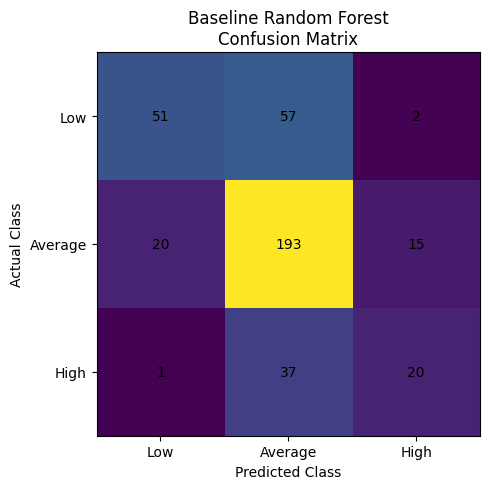

In [155]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_rf)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])

ax.set_xticklabels(
    ["Low", "Average", "High"]
)

ax.set_yticklabels(
    ["Low", "Average", "High"]
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "Baseline Random Forest\nConfusion Matrix"
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

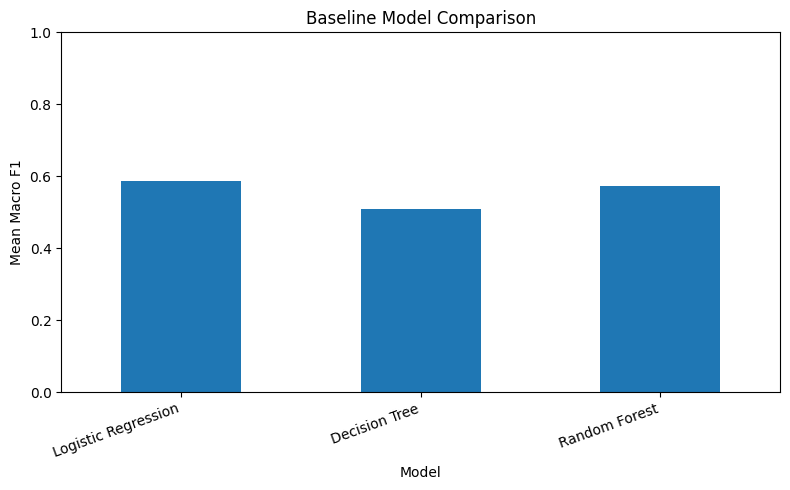

In [156]:
plot_data = (
    baseline_results_df
    .set_index("Model")[
        "Macro_F1_Mean"
    ]
)

plt.figure(figsize=(8, 5))

plot_data.plot(
    kind="bar"
)

plt.title(
    "Baseline Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("Mean Macro F1")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

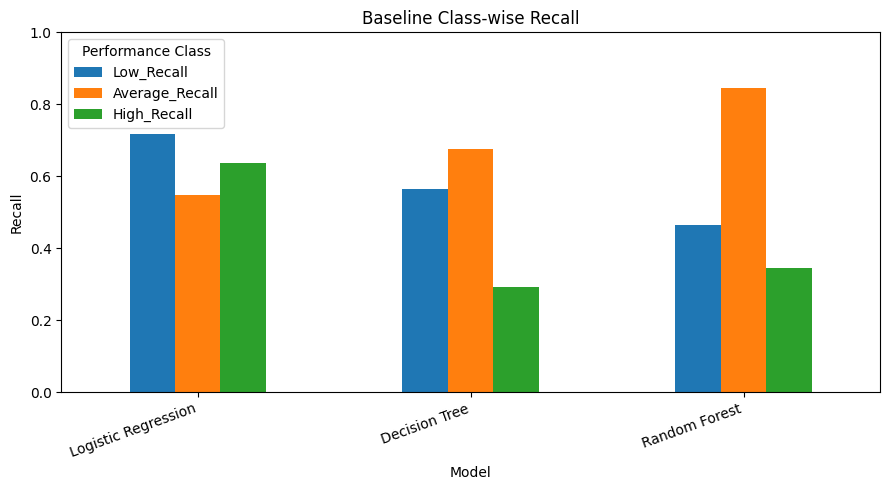

In [157]:
class_recall_plot = (
    class_recall_df
    .set_index("Model")
)

class_recall_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Baseline Class-wise Recall"
)

plt.xlabel("Model")
plt.ylabel("Recall")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Performance Class"
)

plt.tight_layout()
plt.show()

In [158]:
baseline_results_df.to_csv(
    "/content/baseline_model_results.csv",
    index=False
)

class_recall_df.to_csv(
    "/content/baseline_class_recall.csv",
    index=False
)

overfitting_df.to_csv(
    "/content/baseline_overfitting_check.csv",
    index=False
)

print("Baseline result files saved.")

Baseline result files saved.


In [159]:
fold_scores = []

for model_name, result in baseline_cv_results.items():

    for fold_number in range(
        len(result["test_f1_macro"])
    ):

        fold_scores.append({
            "Model": model_name,
            "Fold": fold_number + 1,

            "Accuracy":
                result[
                    "test_accuracy"
                ][fold_number],

            "Macro_Precision":
                result[
                    "test_precision_macro"
                ][fold_number],

            "Macro_Recall":
                result[
                    "test_recall_macro"
                ][fold_number],

            "Macro_F1":
                result[
                    "test_f1_macro"
                ][fold_number]
        })


baseline_fold_scores_df = pd.DataFrame(
    fold_scores
)

baseline_fold_scores_df.round(4)

,Model,Fold,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Logistic Regression,1,0.5750,0.5384,0.5845,0.5464
1,Logistic Regression,2,0.5570,0.5172,0.5594,0.5238
2,Logistic Regression,3,0.6076,0.5778,0.6347,0.5913
3,Logistic Regression,4,0.6962,0.6469,0.6943,0.6624
4,Logistic Regression,5,0.6076,0.6069,0.7055,0.6042
5,Decision Tree,1,0.5500,0.4697,0.4595,0.4635
6,Decision Tree,2,0.5316,0.4240,0.4399,0.4297
7,Decision Tree,3,0.5949,0.5556,0.5837,0.5664
8,Decision Tree,4,0.5696,0.4452,0.4440,0.4439
9,Decision Tree,5,0.6962,0.6581,0.6245,0.6364


In [160]:
baseline_fold_scores_df.to_csv(
    "/content/baseline_fold_scores.csv",
    index=False
)

print("Fold scores saved.")

Fold scores saved.


In [161]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.base import clone

print("Hyperparameter tuning tools imported.")

Hyperparameter tuning tools imported.


In [162]:
outer_cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

inner_splits = 3

inner_cv = StratifiedKFold(
    n_splits=inner_splits,
    shuffle=True,
    random_state=42
)

print("Outer CV folds:", n_splits)
print("Inner CV folds:", inner_splits)

Outer CV folds: 5
Inner CV folds: 3


In [163]:
lr_param_grid = {
    "model__C": [
        0.1,
        1,
        10
    ]
}

print(lr_param_grid)

{'model__C': [0.1, 1, 10]}


In [164]:
dt_param_grid = {
    "model__max_depth": [
        3,
        5,
        8,
        None
    ],

    "model__min_samples_leaf": [
        1,
        3,
        5
    ]
}

print(dt_param_grid)

{'model__max_depth': [3, 5, 8, None], 'model__min_samples_leaf': [1, 3, 5]}


In [165]:
rf_param_grid = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        5,
        10,
        None
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

print(rf_param_grid)

{'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [1, 2, 4]}


In [166]:
tuning_models = {
    "Logistic Regression": {
        "pipeline": baseline_lr,
        "grid": lr_param_grid
    },

    "Decision Tree": {
        "pipeline": baseline_dt,
        "grid": dt_param_grid
    },

    "Random Forest": {
        "pipeline": baseline_rf,
        "grid": rf_param_grid
    }
}

print("Models prepared for tuning.")

for model_name in tuning_models:
    print("-", model_name)

Models prepared for tuning.
- Logistic Regression
- Decision Tree
- Random Forest


In [167]:
nested_results = []
nested_predictions = {}

best_parameters_by_fold = {
    "Logistic Regression": [],
    "Decision Tree": [],
    "Random Forest": []
}

for model_name in tuning_models:
    nested_predictions[model_name] = np.zeros(
        len(y_encoded),
        dtype=int
    )

print("Result containers ready.")

Result containers ready.


In [168]:
for model_name, config in tuning_models.items():

    print("\n" + "=" * 70)
    print("MODEL:", model_name)
    print("=" * 70)

    fold_number = 1

    for train_index, test_index in outer_cv.split(
        X_model,
        y_encoded
    ):

        X_train = X_model.iloc[train_index]
        X_test = X_model.iloc[test_index]

        y_train = y_encoded.iloc[train_index]
        y_test = y_encoded.iloc[test_index]

        grid_search = GridSearchCV(
            estimator=clone(
                config["pipeline"]
            ),
            param_grid=config["grid"],
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )

        grid_search.fit(
            X_train,
            y_train
        )

        y_pred = grid_search.predict(
            X_test
        )

        nested_predictions[
            model_name
        ][test_index] = y_pred

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        macro_precision = precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )

        class_recalls = recall_score(
            y_test,
            y_pred,
            labels=[0, 1, 2],
            average=None,
            zero_division=0
        )

        nested_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Accuracy": accuracy,
            "Macro_Precision": macro_precision,
            "Macro_Recall": macro_recall,
            "Macro_F1": macro_f1,
            "Low_Recall": class_recalls[0],
            "Average_Recall": class_recalls[1],
            "High_Recall": class_recalls[2]
        })

        best_parameters_by_fold[
            model_name
        ].append(
            grid_search.best_params_
        )

        print(
            f"Fold {fold_number} completed"
        )

        print(
            "Best parameters:",
            grid_search.best_params_
        )

        print(
            "Outer Macro F1:",
            round(macro_f1, 4)
        )

        fold_number += 1

print("\nNested cross-validation completed.")


MODEL: Logistic Regression
Fold 1 completed
Best parameters: {'model__C': 0.1}
Outer Macro F1: 0.5666
Fold 2 completed
Best parameters: {'model__C': 0.1}
Outer Macro F1: 0.5441
Fold 3 completed
Best parameters: {'model__C': 0.1}
Outer Macro F1: 0.5842
Fold 4 completed
Best parameters: {'model__C': 0.1}
Outer Macro F1: 0.6601
Fold 5 completed
Best parameters: {'model__C': 0.1}
Outer Macro F1: 0.6258

MODEL: Decision Tree
Fold 1 completed
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1}
Outer Macro F1: 0.4635
Fold 2 completed
Best parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 5}
Outer Macro F1: 0.5623
Fold 3 completed
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1}
Outer Macro F1: 0.5664
Fold 4 completed
Best parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 5}
Outer Macro F1: 0.534
Fold 5 completed
Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 5}
Outer Macro F1: 0.4538

MODEL: Random 

In [169]:
nested_results_df = pd.DataFrame(
    nested_results
)

nested_results_df.round(4)

,Model,Fold,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Low_Recall,Average_Recall,High_Recall
0,Logistic Regression,1,0.5875,0.5543,0.6123,0.5666,0.5000,0.5870,0.7500
1,Logistic Regression,2,0.5823,0.5357,0.5742,0.5441,0.7727,0.5333,0.4167
2,Logistic Regression,3,0.5949,0.5783,0.6476,0.5842,0.6818,0.5111,0.7500
3,Logistic Regression,4,0.6962,0.6474,0.7022,0.6601,0.8182,0.6522,0.6364
4,Logistic Regression,5,0.6329,0.6228,0.7200,0.6258,0.8636,0.4783,0.8182
5,Decision Tree,1,0.5500,0.4697,0.4595,0.4635,0.4545,0.6739,0.2500
6,Decision Tree,2,0.5823,0.5706,0.6305,0.5623,0.8636,0.4444,0.5833
7,Decision Tree,3,0.5949,0.5556,0.5837,0.5664,0.5455,0.6222,0.5833
8,Decision Tree,4,0.5316,0.5267,0.6232,0.5340,0.7727,0.3696,0.7273
9,Decision Tree,5,0.4557,0.4444,0.5171,0.4538,0.5455,0.3696,0.6364


In [170]:
tuned_summary = (
    nested_results_df
    .groupby("Model")
    .agg({
        "Accuracy": [
            "mean",
            "std"
        ],

        "Macro_Precision": [
            "mean",
            "std"
        ],

        "Macro_Recall": [
            "mean",
            "std"
        ],

        "Macro_F1": [
            "mean",
            "std"
        ]
    })
)

tuned_summary.round(4)

Accuracy         Macro_Precision         Macro_Recall  \
                        mean     std            mean     std         mean   
Model                                                                       
Decision Tree         0.5429  0.0549          0.5134  0.0545       0.5628   
Logistic Regression   0.6188  0.0476          0.5877  0.0467       0.6513   
Random Forest         0.6668  0.0596          0.6267  0.0603       0.6190   

                            Macro_F1          
                        std     mean     std  
Model                                         
Decision Tree        0.0732   0.5160  0.0539  
Logistic Regression  0.0608   0.5962  0.0466  
Random Forest        0.0804   0.6145  0.0739

In [171]:
tuned_publication_table = (
    nested_results_df
    .groupby("Model")
    .agg(
        Accuracy_Mean=(
            "Accuracy",
            "mean"
        ),
        Accuracy_SD=(
            "Accuracy",
            "std"
        ),
        Macro_Precision_Mean=(
            "Macro_Precision",
            "mean"
        ),
        Macro_Precision_SD=(
            "Macro_Precision",
            "std"
        ),
        Macro_Recall_Mean=(
            "Macro_Recall",
            "mean"
        ),
        Macro_Recall_SD=(
            "Macro_Recall",
            "std"
        ),
        Macro_F1_Mean=(
            "Macro_F1",
            "mean"
        ),
        Macro_F1_SD=(
            "Macro_F1",
            "std"
        )
    )
    .reset_index()
)

tuned_publication_table.round(4)

,Model,Accuracy_Mean,Accuracy_SD,Macro_Precision_Mean,Macro_Precision_SD,Macro_Recall_Mean,Macro_Recall_SD,Macro_F1_Mean,Macro_F1_SD
0,Decision Tree,0.5429,0.0549,0.5134,0.0545,0.5628,0.0732,0.5160,0.0539
1,Logistic Regression,0.6188,0.0476,0.5877,0.0467,0.6513,0.0608,0.5962,0.0466
2,Random Forest,0.6668,0.0596,0.6267,0.0603,0.6190,0.0804,0.6145,0.0739


In [172]:
tuned_ranked = (
    tuned_publication_table
    .sort_values(
        by="Macro_F1_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_ranked.round(4)

,Model,Accuracy_Mean,Accuracy_SD,Macro_Precision_Mean,Macro_Precision_SD,Macro_Recall_Mean,Macro_Recall_SD,Macro_F1_Mean,Macro_F1_SD
0,Random Forest,0.6668,0.0596,0.6267,0.0603,0.6190,0.0804,0.6145,0.0739
1,Logistic Regression,0.6188,0.0476,0.5877,0.0467,0.6513,0.0608,0.5962,0.0466
2,Decision Tree,0.5429,0.0549,0.5134,0.0545,0.5628,0.0732,0.5160,0.0539


In [173]:
tuned_class_recall = (
    nested_results_df
    .groupby("Model")
    .agg(
        Low_Recall_Mean=(
            "Low_Recall",
            "mean"
        ),

        Average_Recall_Mean=(
            "Average_Recall",
            "mean"
        ),

        High_Recall_Mean=(
            "High_Recall",
            "mean"
        )
    )
    .reset_index()
)

tuned_class_recall.round(4)

,Model,Low_Recall_Mean,Average_Recall_Mean,High_Recall_Mean
0,Decision Tree,0.6364,0.4959,0.5561
1,Logistic Regression,0.7273,0.5524,0.6742
2,Random Forest,0.5727,0.7448,0.5394


In [174]:
for model_name, params_list in best_parameters_by_fold.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    for i, params in enumerate(
        params_list,
        start=1
    ):
        print(
            f"Fold {i}:",
            params
        )


Logistic Regression
Fold 1: {'model__C': 0.1}
Fold 2: {'model__C': 0.1}
Fold 3: {'model__C': 0.1}
Fold 4: {'model__C': 0.1}
Fold 5: {'model__C': 0.1}

Decision Tree
Fold 1: {'model__max_depth': None, 'model__min_samples_leaf': 1}
Fold 2: {'model__max_depth': 3, 'model__min_samples_leaf': 5}
Fold 3: {'model__max_depth': None, 'model__min_samples_leaf': 1}
Fold 4: {'model__max_depth': 3, 'model__min_samples_leaf': 5}
Fold 5: {'model__max_depth': 5, 'model__min_samples_leaf': 5}

Random Forest
Fold 1: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Fold 2: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Fold 3: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Fold 4: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
Fold 5: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}


In [175]:
baseline_compare = (
    baseline_results_df[
        [
            "Model",
            "Macro_F1_Mean"
        ]
    ]
    .rename(
        columns={
            "Macro_F1_Mean":
                "Baseline_Macro_F1"
        }
    )
)

tuned_compare = (
    tuned_publication_table[
        [
            "Model",
            "Macro_F1_Mean"
        ]
    ]
    .rename(
        columns={
            "Macro_F1_Mean":
                "Tuned_Macro_F1"
        }
    )
)

baseline_vs_tuned = pd.merge(
    baseline_compare,
    tuned_compare,
    on="Model"
)

baseline_vs_tuned[
    "Improvement"
] = (
    baseline_vs_tuned[
        "Tuned_Macro_F1"
    ]
    -
    baseline_vs_tuned[
        "Baseline_Macro_F1"
    ]
)

baseline_vs_tuned.round(4)

,Model,Baseline_Macro_F1,Tuned_Macro_F1,Improvement
0,Logistic Regression,0.5856,0.5962,0.0106
1,Decision Tree,0.5080,0.5160,0.0080
2,Random Forest,0.5732,0.6145,0.0413


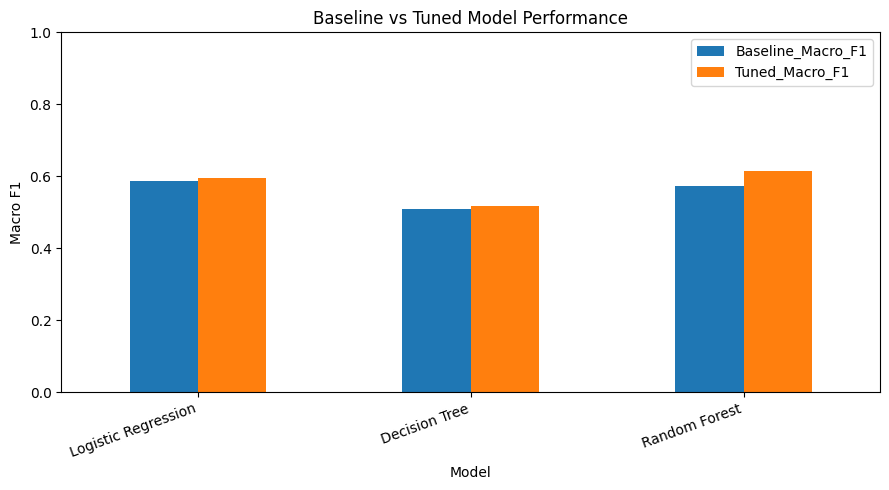

In [176]:
plot_compare = baseline_vs_tuned.set_index(
    "Model"
)[
    [
        "Baseline_Macro_F1",
        "Tuned_Macro_F1"
    ]
]

plot_compare.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Baseline vs Tuned Model Performance"
)

plt.xlabel("Model")
plt.ylabel("Macro F1")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

In [177]:
cm_lr_tuned = confusion_matrix(
    y_encoded,
    nested_predictions[
        "Logistic Regression"
    ],
    labels=[0, 1, 2]
)

print(cm_lr_tuned)

[[ 80  22   8]
 [ 49 126  53]
 [  3  16  39]]


In [178]:
cm_dt_tuned = confusion_matrix(
    y_encoded,
    nested_predictions[
        "Decision Tree"
    ],
    labels=[0, 1, 2]
)

print(cm_dt_tuned)

[[ 70  33   7]
 [ 64 113  51]
 [  4  22  32]]


In [179]:
cm_rf_tuned = confusion_matrix(
    y_encoded,
    nested_predictions[
        "Random Forest"
    ],
    labels=[0, 1, 2]
)

print(cm_rf_tuned)

[[ 63  43   4]
 [ 26 170  32]
 [  1  26  31]]


In [180]:
def plot_confusion_matrix_simple(
    cm,
    title
):

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.imshow(cm)

    ax.set_xticks(
        [0, 1, 2]
    )

    ax.set_yticks(
        [0, 1, 2]
    )

    ax.set_xticklabels(
        ["Low", "Average", "High"]
    )

    ax.set_yticklabels(
        ["Low", "Average", "High"]
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )

    ax.set_title(title)

    for i in range(3):
        for j in range(3):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

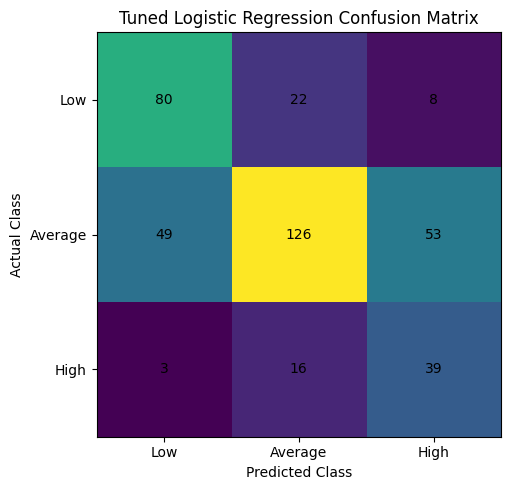

In [181]:
plot_confusion_matrix_simple(
    cm_lr_tuned,
    "Tuned Logistic Regression Confusion Matrix"
)

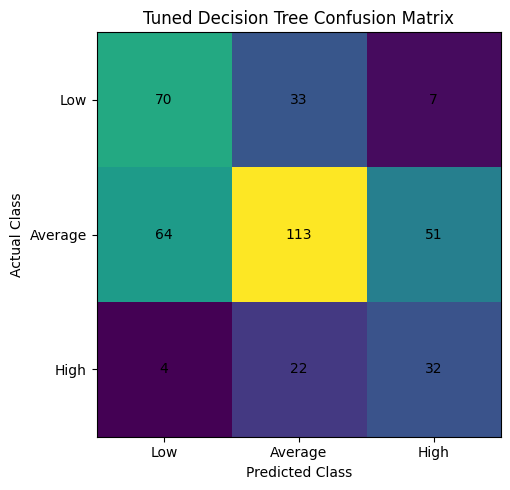

In [182]:
plot_confusion_matrix_simple(
    cm_dt_tuned,
    "Tuned Decision Tree Confusion Matrix"
)

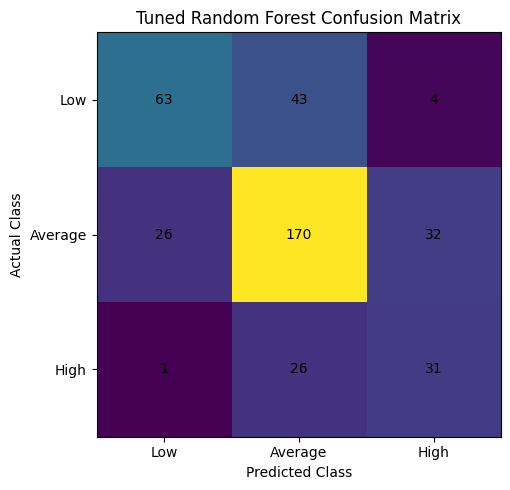

In [183]:
plot_confusion_matrix_simple(
    cm_rf_tuned,
    "Tuned Random Forest Confusion Matrix"
)

In [184]:
for model_name, predictions in nested_predictions.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            y_encoded,
            predictions,
            labels=[0, 1, 2],
            target_names=[
                "Low",
                "Average",
                "High"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

         Low     0.6061    0.7273    0.6612       110
     Average     0.7683    0.5526    0.6429       228
        High     0.3900    0.6724    0.4937        58

    accuracy                         0.6187       396
   macro avg     0.5881    0.6508    0.5992       396
weighted avg     0.6678    0.6187    0.6261       396


Decision Tree
              precision    recall  f1-score   support

         Low     0.5072    0.6364    0.5645       110
     Average     0.6726    0.4956    0.5707       228
        High     0.3556    0.5517    0.4324        58

    accuracy                         0.5429       396
   macro avg     0.5118    0.5612    0.5226       396
weighted avg     0.5802    0.5429    0.5487       396


Random Forest
              precision    recall  f1-score   support

         Low     0.7000    0.5727    0.6300       110
     Average     0.7113    0.7456    0.7281       228
        High     0.4627 

In [185]:
nested_results_df.to_csv(
    "/content/nested_cv_fold_results.csv",
    index=False
)

tuned_publication_table.to_csv(
    "/content/tuned_model_results.csv",
    index=False
)

tuned_class_recall.to_csv(
    "/content/tuned_class_recall.csv",
    index=False
)

baseline_vs_tuned.to_csv(
    "/content/baseline_vs_tuned.csv",
    index=False
)

print("All tuning result files saved.")

All tuning result files saved.


# **PART 8 — Statistical Testing**

In [186]:
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

print("Statistical testing tools imported.")

Statistical testing tools imported.


In [187]:
lr_scores = (
    nested_results_df[
        nested_results_df["Model"] == "Logistic Regression"
    ]
    .sort_values("Fold")["Macro_F1"]
    .to_numpy()
)

dt_scores = (
    nested_results_df[
        nested_results_df["Model"] == "Decision Tree"
    ]
    .sort_values("Fold")["Macro_F1"]
    .to_numpy()
)

rf_scores = (
    nested_results_df[
        nested_results_df["Model"] == "Random Forest"
    ]
    .sort_values("Fold")["Macro_F1"]
    .to_numpy()
)

print("LR:", lr_scores)
print("DT:", dt_scores)
print("RF:", rf_scores)

LR: [0.56664653 0.54414084 0.58420635 0.66014113 0.6257716 ]
DT: [0.46347882 0.56229899 0.56636039 0.53404838 0.45380719]
RF: [0.51587125 0.6065398  0.58196248 0.65826856 0.70991609]


In [188]:
friedman_stat, friedman_p = friedmanchisquare(
    lr_scores,
    dt_scores,
    rf_scores
)

print("Friedman statistic:", round(friedman_stat, 4))
print("Friedman p-value:", round(friedman_p, 6))

Friedman statistic: 4.8
Friedman p-value: 0.090718


In [189]:
alpha = 0.05

if friedman_p < alpha:
    print(
        "Result: Statistically significant difference "
        "exists among the three models."
    )
else:
    print(
        "Result: No statistically significant difference "
        "was detected among the three models."
    )

Result: No statistically significant difference was detected among the three models.


In [190]:
pairwise_results = []

if friedman_p < alpha:

    comparisons = [
        (
            "Logistic Regression vs Decision Tree",
            lr_scores,
            dt_scores
        ),
        (
            "Logistic Regression vs Random Forest",
            lr_scores,
            rf_scores
        ),
        (
            "Decision Tree vs Random Forest",
            dt_scores,
            rf_scores
        )
    ]

    for name, scores_a, scores_b in comparisons:

        stat, p_value = wilcoxon(
            scores_a,
            scores_b,
            alternative="two-sided",
            zero_method="wilcox"
        )

        pairwise_results.append({
            "Comparison": name,
            "Statistic": stat,
            "Raw_p_value": p_value
        })

    pairwise_results_df = pd.DataFrame(
        pairwise_results
    )

    pairwise_results_df

else:
    print(
        "Pairwise Wilcoxon tests not performed "
        "because the Friedman test was not significant."
    )

Pairwise Wilcoxon tests not performed because the Friedman test was not significant.


In [191]:
if friedman_p < alpha:

    reject, corrected_p, _, _ = multipletests(
        pairwise_results_df["Raw_p_value"],
        alpha=0.05,
        method="holm"
    )

    pairwise_results_df[
        "Holm_Adjusted_p"
    ] = corrected_p

    pairwise_results_df[
        "Significant_After_Holm"
    ] = reject

    pairwise_results_df

In [192]:
if friedman_p < alpha:

    print(
        "Friedman test detected a significant "
        "difference among the models.\n"
    )

    for _, row in pairwise_results_df.iterrows():

        print(row["Comparison"])

        print(
            "Adjusted p-value:",
            round(
                row["Holm_Adjusted_p"],
                6
            )
        )

        if row["Significant_After_Holm"]:
            print("Significant difference: YES")
        else:
            print("Significant difference: NO")

        print()

else:

    print(
        "The Friedman test did not detect a "
        "statistically significant difference "
        "among the three models."
    )

The Friedman test did not detect a statistically significant difference among the three models.


In [193]:
stability_table = (
    nested_results_df
    .groupby("Model")
    .agg(
        Macro_F1_Mean=(
            "Macro_F1",
            "mean"
        ),
        Macro_F1_SD=(
            "Macro_F1",
            "std"
        ),
        Macro_F1_Min=(
            "Macro_F1",
            "min"
        ),
        Macro_F1_Max=(
            "Macro_F1",
            "max"
        )
    )
    .reset_index()
)

stability_table.round(4)

,Model,Macro_F1_Mean,Macro_F1_SD,Macro_F1_Min,Macro_F1_Max
0,Decision Tree,0.5160,0.0539,0.4538,0.5664
1,Logistic Regression,0.5962,0.0466,0.5441,0.6601
2,Random Forest,0.6145,0.0739,0.5159,0.7099


In [194]:
low_recall_table = (
    nested_results_df
    .groupby("Model")
    .agg(
        Low_Recall_Mean=(
            "Low_Recall",
            "mean"
        ),
        Low_Recall_SD=(
            "Low_Recall",
            "std"
        )
    )
    .reset_index()
)

low_recall_table.round(4)

,Model,Low_Recall_Mean,Low_Recall_SD
0,Decision Tree,0.6364,0.1731
1,Logistic Regression,0.7273,0.1437
2,Random Forest,0.5727,0.1459


In [195]:
final_selection_table = pd.merge(
    stability_table,
    low_recall_table,
    on="Model"
)

accuracy_table = (
    nested_results_df
    .groupby("Model")
    .agg(
        Accuracy_Mean=(
            "Accuracy",
            "mean"
        ),
        Macro_Recall_Mean=(
            "Macro_Recall",
            "mean"
        )
    )
    .reset_index()
)

final_selection_table = pd.merge(
    final_selection_table,
    accuracy_table,
    on="Model"
)

final_selection_table = (
    final_selection_table
    .sort_values(
        "Macro_F1_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

final_selection_table.round(4)

,Model,Macro_F1_Mean,Macro_F1_SD,Macro_F1_Min,Macro_F1_Max,Low_Recall_Mean,Low_Recall_SD,Accuracy_Mean,Macro_Recall_Mean
0,Random Forest,0.6145,0.0739,0.5159,0.7099,0.5727,0.1459,0.6668,0.6190
1,Logistic Regression,0.5962,0.0466,0.5441,0.6601,0.7273,0.1437,0.6188,0.6513
2,Decision Tree,0.5160,0.0539,0.4538,0.5664,0.6364,0.1731,0.5429,0.5628


In [196]:
top_model_name = (
    final_selection_table
    .iloc[0]["Model"]
)

top_macro_f1 = (
    final_selection_table
    .iloc[0]["Macro_F1_Mean"]
)

print(
    "Highest mean Macro F1 model:",
    top_model_name
)

print(
    "Mean Macro F1:",
    round(top_macro_f1, 4)
)

Highest mean Macro F1 model: Random Forest
Mean Macro F1: 0.6145


In [197]:
final_lr_search = GridSearchCV(
    estimator=clone(baseline_lr),
    param_grid=lr_param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

final_lr_search.fit(
    X_model,
    y_encoded
)

print(
    "Best LR parameters:",
    final_lr_search.best_params_
)

Best LR parameters: {'model__C': 0.1}


In [198]:
final_dt_search = GridSearchCV(
    estimator=clone(baseline_dt),
    param_grid=dt_param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

final_dt_search.fit(
    X_model,
    y_encoded
)

print(
    "Best DT parameters:",
    final_dt_search.best_params_
)

Best DT parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 5}


In [199]:
final_rf_search = GridSearchCV(
    estimator=clone(baseline_rf),
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

final_rf_search.fit(
    X_model,
    y_encoded
)

print(
    "Best RF parameters:",
    final_rf_search.best_params_
)

Best RF parameters: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [200]:
final_models = {
    "Logistic Regression":
        final_lr_search.best_estimator_,

    "Decision Tree":
        final_dt_search.best_estimator_,

    "Random Forest":
        final_rf_search.best_estimator_
}

print("Final fitted models stored.")

Final fitted models stored.


In [201]:
friedman_results_df = pd.DataFrame({
    "Test": [
        "Friedman Test"
    ],
    "Statistic": [
        friedman_stat
    ],
    "p_value": [
        friedman_p
    ]
})

friedman_results_df.to_csv(
    "/content/friedman_test_results.csv",
    index=False
)

stability_table.to_csv(
    "/content/model_stability_results.csv",
    index=False
)

final_selection_table.to_csv(
    "/content/final_model_selection_table.csv",
    index=False
)

if friedman_p < alpha:

    pairwise_results_df.to_csv(
        "/content/wilcoxon_holm_results.csv",
        index=False
    )

print("Statistical results saved.")

Statistical results saved.


# **PART 9 — Model Interpretation**

In [202]:
final_lr = final_models["Logistic Regression"]
final_dt = final_models["Decision Tree"]
final_rf = final_models["Random Forest"]

print("Final models loaded:")
print("- Logistic Regression")
print("- Decision Tree")
print("- Random Forest")

Final models loaded:
- Logistic Regression
- Decision Tree
- Random Forest


In [203]:
final_lr = final_models["Logistic Regression"]
final_dt = final_models["Decision Tree"]
final_rf = final_models["Random Forest"]

print("Final models loaded:")
print("- Logistic Regression")
print("- Decision Tree")
print("- Random Forest")

Final models loaded:
- Logistic Regression
- Decision Tree
- Random Forest


In [204]:
tree_feature_names = (
    final_rf
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

print("Number of transformed features:", len(tree_feature_names))

for feature in tree_feature_names:
    print(feature)

Number of transformed features: 23
nominal__degree_area_Arts / Humanities
nominal__degree_area_Business / Management
nominal__degree_area_Education
nominal__degree_area_Engineering
nominal__degree_area_Information Technology / Computing
nominal__degree_area_Other
nominal__degree_area_Science
nominal__study_mode_Full-time
nominal__study_mode_Part-time
ordinal__year_of_study
ordinal__attendance
ordinal__study_hours
ordinal__lms_usage
ordinal__assignment_submission
ordinal__academic_participation
ordinal__sleep_hours
ordinal__motivation
ordinal__time_management
ordinal__internet_quality
ordinal__academic_stress
ordinal__travel_time
ordinal__study_resources
binary__part_time_employment


In [205]:
rf_model_only = final_rf.named_steps["model"]

rf_importances = rf_model_only.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": rf_importances
})

rf_importance_df = (
    rf_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_importance_df.head(20)

,Feature,Importance
0,ordinal__study_resources,0.190228
1,ordinal__lms_usage,0.097992
2,binary__part_time_employment,0.093541
3,ordinal__travel_time,0.086353
4,ordinal__motivation,0.067880
5,ordinal__assignment_submission,0.065892
6,ordinal__attendance,0.057389
7,ordinal__internet_quality,0.055123
8,ordinal__academic_stress,0.048585
9,ordinal__year_of_study,0.042537


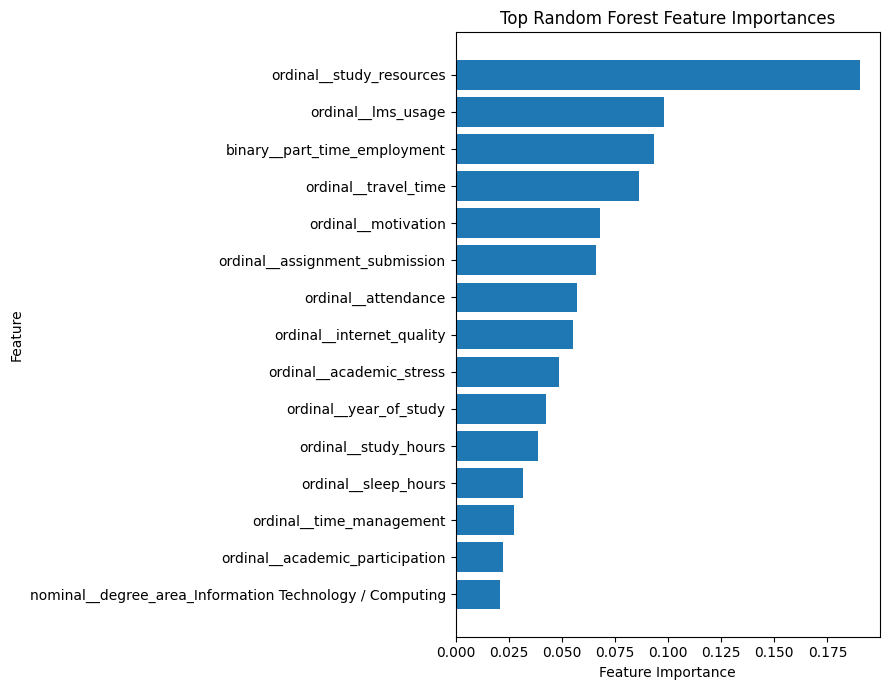

In [206]:
top_rf = rf_importance_df.head(15).copy()

plt.figure(figsize=(9, 7))

plt.barh(
    top_rf["Feature"][::-1],
    top_rf["Importance"][::-1]
)

plt.title(
    "Top Random Forest Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [207]:
def get_original_feature(transformed_name):

    name = transformed_name.split("__", 1)[-1]

    # Check longest names first
    sorted_features = sorted(
        X_model.columns,
        key=len,
        reverse=True
    )

    for original in sorted_features:

        if (
            name == original
            or name.startswith(original + "_")
        ):
            return original

    return name

In [208]:
rf_importance_df["Original_Feature"] = (
    rf_importance_df["Feature"]
    .apply(get_original_feature)
)

rf_original_importance = (
    rf_importance_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

rf_original_importance

,Original_Feature,Importance
0,study_resources,0.190228
1,lms_usage,0.097992
2,part_time_employment,0.093541
3,travel_time,0.086353
4,motivation,0.067880
5,degree_area,0.067360
6,assignment_submission,0.065892
7,attendance,0.057389
8,internet_quality,0.055123
9,academic_stress,0.048585


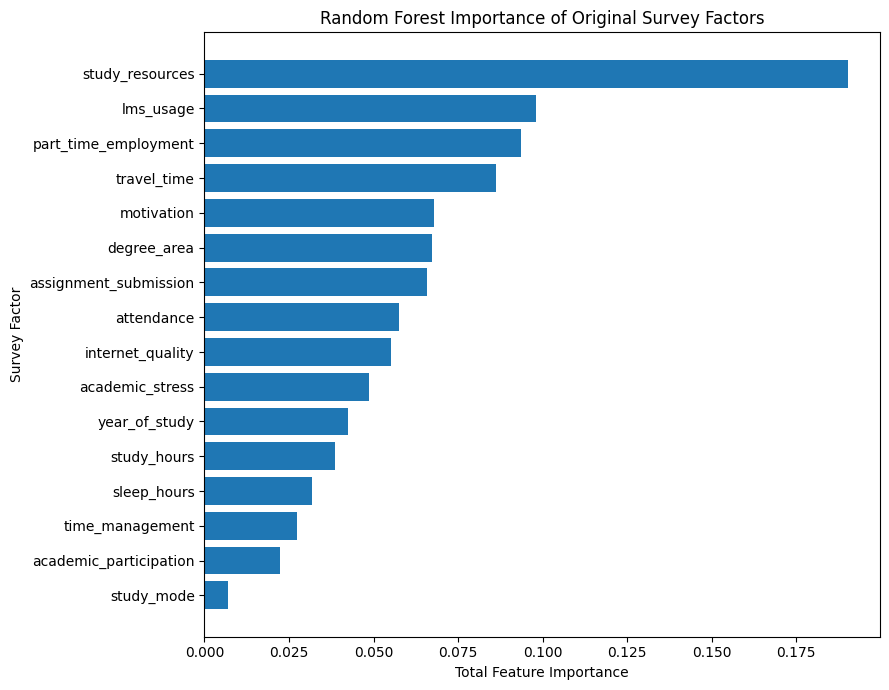

In [209]:
plot_rf_original = (
    rf_original_importance
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_rf_original["Original_Feature"],
    plot_rf_original["Importance"]
)

plt.title(
    "Random Forest Importance of Original Survey Factors"
)

plt.xlabel("Total Feature Importance")
plt.ylabel("Survey Factor")

plt.tight_layout()
plt.show()

In [210]:
from sklearn.inspection import permutation_importance

print("Permutation importance imported.")

Permutation importance imported.


In [211]:
rf_permutation = permutation_importance(
    final_rf,
    X_model,
    y_encoded,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance completed.")

Permutation importance completed.


In [212]:
permutation_df = pd.DataFrame({
    "Feature": X_model.columns,
    "Importance_Mean":
        rf_permutation.importances_mean,
    "Importance_SD":
        rf_permutation.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df

,Feature,Importance_Mean,Importance_SD
0,study_resources,0.078733,0.013527
1,travel_time,0.049354,0.014164
2,degree_area,0.048993,0.007378
3,part_time_employment,0.044566,0.008422
4,lms_usage,0.039017,0.013280
5,study_hours,0.022128,0.005677
6,attendance,0.021554,0.007666
7,year_of_study,0.018904,0.006212
8,motivation,0.014721,0.006794
9,academic_stress,0.014674,0.006436


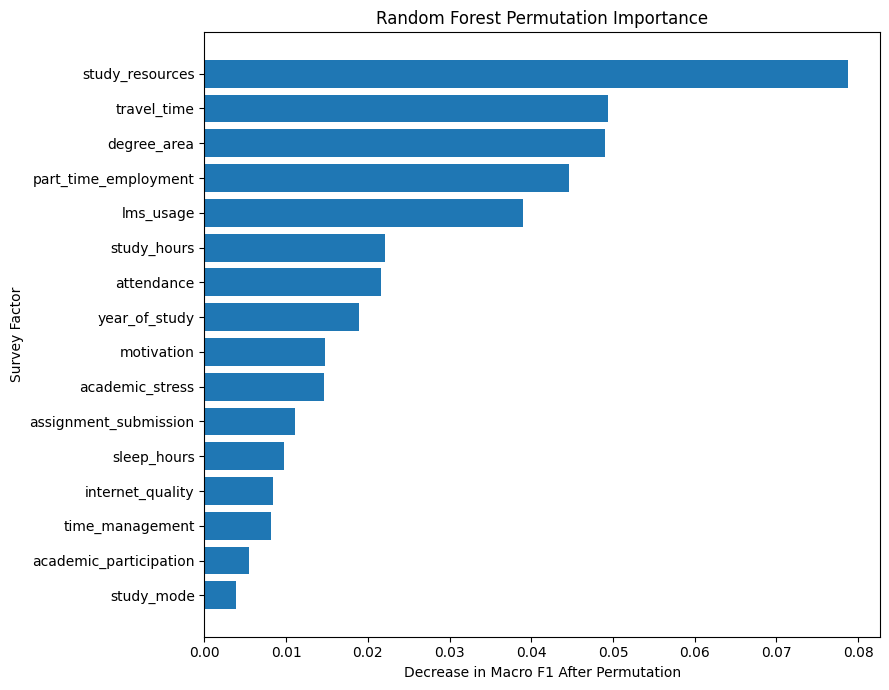

In [213]:
perm_plot = (
    permutation_df
    .sort_values(
        "Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    perm_plot["Feature"],
    perm_plot["Importance_Mean"]
)

plt.title(
    "Random Forest Permutation Importance"
)

plt.xlabel(
    "Decrease in Macro F1 After Permutation"
)

plt.ylabel("Survey Factor")

plt.tight_layout()
plt.show()

In [214]:
lr_column_transformer = (
    final_lr
    .named_steps["preprocessing"]
    .named_steps["column_transformer"]
)

lr_feature_names = (
    lr_column_transformer
    .get_feature_names_out()
)

print(
    "Number of LR transformed features:",
    len(lr_feature_names)
)

Number of LR transformed features: 23


In [215]:
lr_model_only = final_lr.named_steps["model"]

print(
    "Coefficient matrix shape:",
    lr_model_only.coef_.shape
)

Coefficient matrix shape: (3, 23)


In [216]:
lr_coefficients_df = pd.DataFrame(
    lr_model_only.coef_.T,
    index=lr_feature_names,
    columns=[
        "Low",
        "Average",
        "High"
    ]
)

lr_coefficients_df.head(20)

,Low,Average,High
nominal__degree_area_Arts / Humanities,-0.119650,-0.000847,0.120498
nominal__degree_area_Business / Management,0.060381,-0.080200,0.019819
nominal__degree_area_Education,0.206057,-0.043746,-0.162311
nominal__degree_area_Engineering,0.021268,0.039025,-0.060293
nominal__degree_area_Information Technology / Computing,-0.087303,0.081776,0.005527
nominal__degree_area_Other,-0.043381,0.066372,-0.022991
nominal__degree_area_Science,-0.020689,-0.058045,0.078734
nominal__study_mode_Full-time,0.031231,0.057109,-0.088340
nominal__study_mode_Part-time,-0.031231,-0.057109,0.088340
ordinal__year_of_study,-0.147925,0.069114,0.078811


In [217]:
low_coefficients = (
    lr_coefficients_df["Low"]
    .sort_values(
        key=abs,
        ascending=False
    )
    .head(15)
)

low_coefficients

,Low
ordinal__study_resources,-0.636561
binary__part_time_employment,0.381828
ordinal__travel_time,-0.270278
ordinal__academic_stress,-0.249672
ordinal__motivation,-0.208849
nominal__degree_area_Education,0.206057
ordinal__lms_usage,-0.161871
ordinal__year_of_study,-0.147925
ordinal__assignment_submission,-0.121302
nominal__degree_area_Arts / Humanities,-0.119650


In [218]:
average_coefficients = (
    lr_coefficients_df["Average"]
    .sort_values(
        key=abs,
        ascending=False
    )
    .head(15)
)

average_coefficients

,Average
ordinal__travel_time,0.300776
ordinal__attendance,-0.209206
ordinal__motivation,-0.176771
ordinal__lms_usage,-0.154908
ordinal__time_management,-0.117772
nominal__degree_area_Information Technology / Computing,0.081776
nominal__degree_area_Business / Management,-0.080200
ordinal__study_hours,0.077605
ordinal__year_of_study,0.069114
nominal__degree_area_Other,0.066372


In [219]:
high_coefficients = (
    lr_coefficients_df["High"]
    .sort_values(
        key=abs,
        ascending=False
    )
    .head(15)
)

high_coefficients

,High
ordinal__study_resources,0.586554
binary__part_time_employment,-0.404525
ordinal__motivation,0.385620
ordinal__lms_usage,0.316778
ordinal__attendance,0.304127
ordinal__academic_stress,0.234623
nominal__degree_area_Education,-0.162311
ordinal__assignment_submission,0.141665
ordinal__time_management,0.129232
nominal__degree_area_Arts / Humanities,0.120498


In [220]:
from sklearn.tree import plot_tree

dt_model_only = final_dt.named_steps["model"]

print(
    "Decision Tree depth:",
    dt_model_only.get_depth()
)

print(
    "Decision Tree leaves:",
    dt_model_only.get_n_leaves()
)

Decision Tree depth: 5
Decision Tree leaves: 24


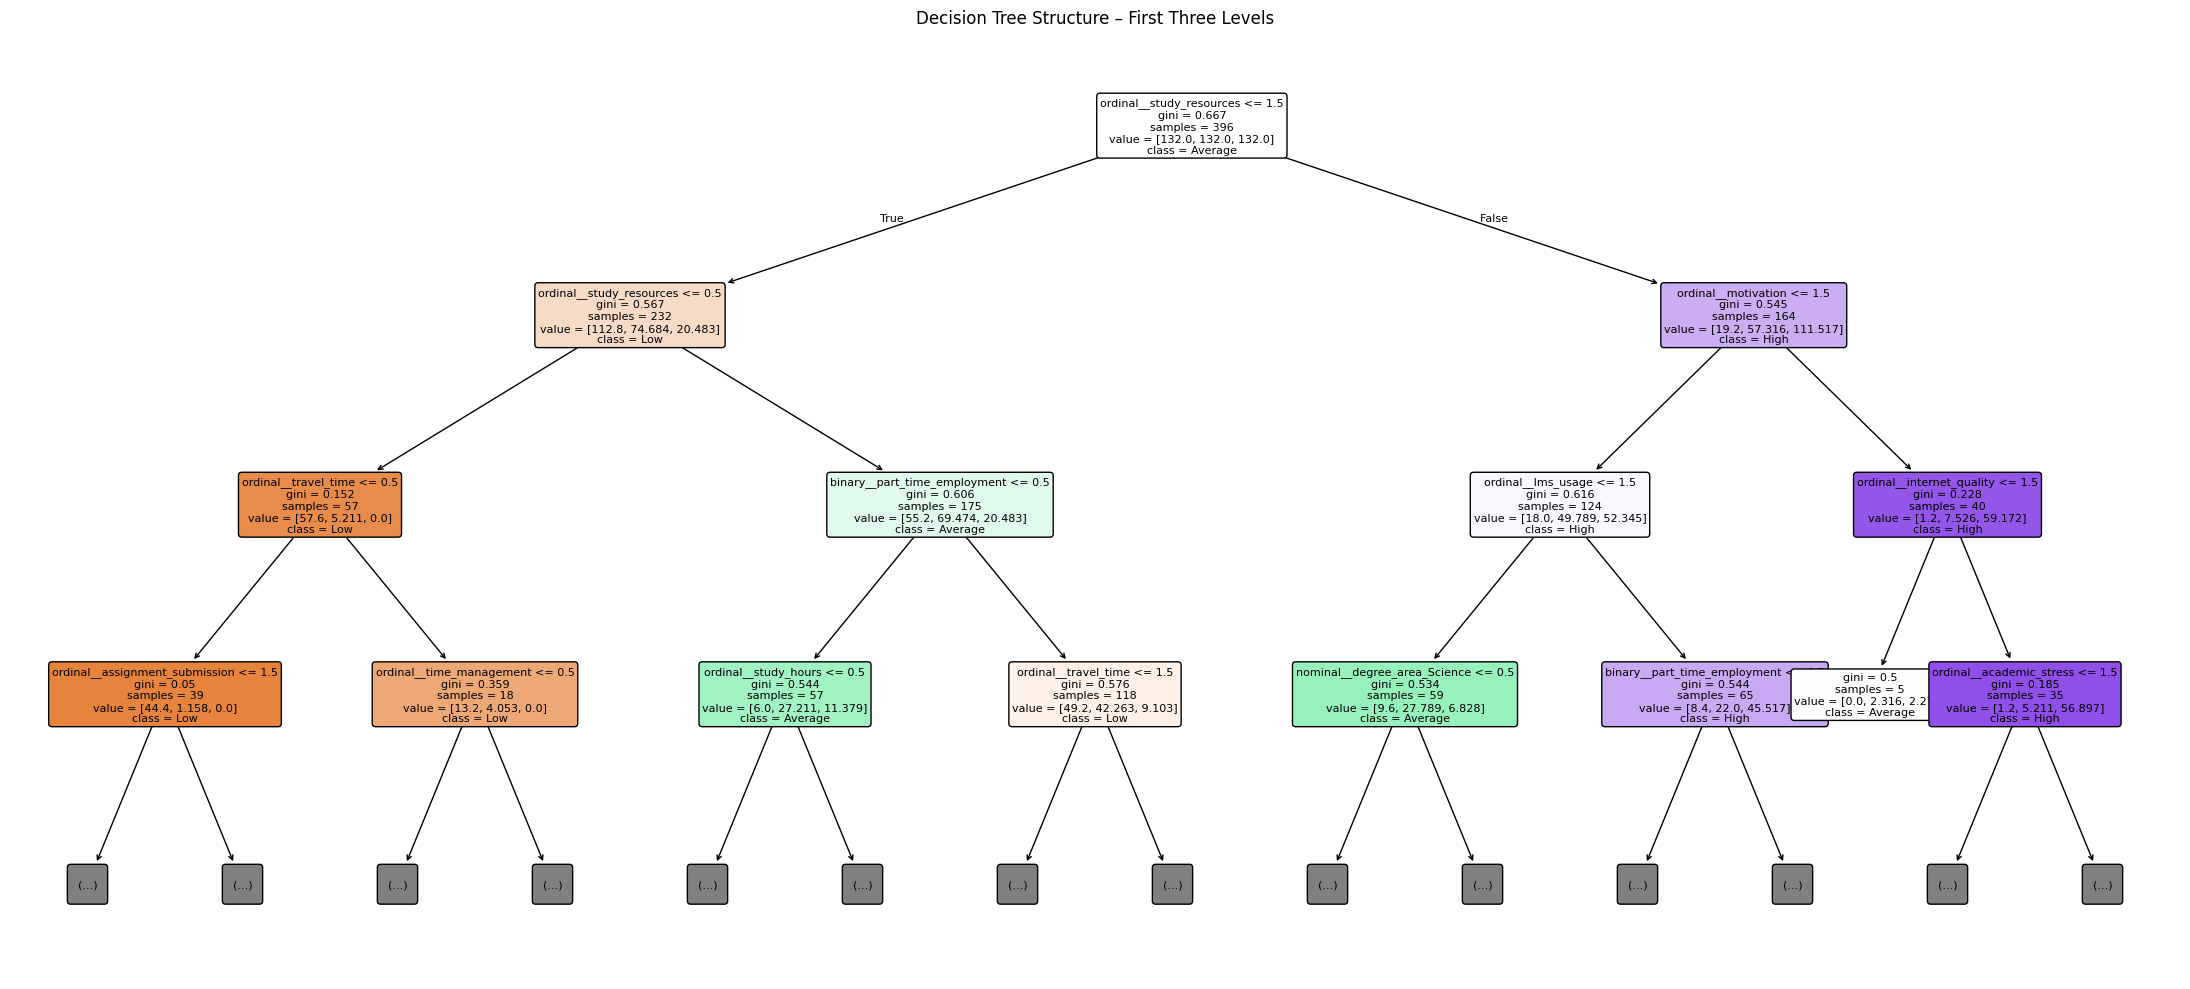

In [221]:
plt.figure(figsize=(22, 10))

plot_tree(
    dt_model_only,
    feature_names=tree_feature_names,
    class_names=[
        "Low",
        "Average",
        "High"
    ],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title(
    "Decision Tree Structure – First Three Levels"
)

plt.tight_layout()
plt.show()

In [222]:
importance_comparison = pd.merge(
    rf_original_importance,
    permutation_df,
    left_on="Original_Feature",
    right_on="Feature",
    how="outer"
)

importance_comparison = importance_comparison[
    [
        "Original_Feature",
        "Importance",
        "Importance_Mean",
        "Importance_SD"
    ]
]

importance_comparison.columns = [
    "Feature",
    "RF_Impurity_Importance",
    "Permutation_Importance_Mean",
    "Permutation_Importance_SD"
]

importance_comparison = (
    importance_comparison
    .sort_values(
        "Permutation_Importance_Mean",
        ascending=False
    )
)

importance_comparison

,Feature,RF_Impurity_Importance,Permutation_Importance_Mean,Permutation_Importance_SD
12,study_resources,0.190228,0.078733,0.013527
14,travel_time,0.086353,0.049354,0.014164
4,degree_area,0.067360,0.048993,0.007378
8,part_time_employment,0.093541,0.044566,0.008422
6,lms_usage,0.097992,0.039017,0.013280
10,study_hours,0.038595,0.022128,0.005677
3,attendance,0.057389,0.021554,0.007666
15,year_of_study,0.042537,0.018904,0.006212
7,motivation,0.067880,0.014721,0.006794
1,academic_stress,0.048585,0.014674,0.006436


In [223]:
top_10_factors = (
    permutation_df
    .head(10)
    .copy()
)

top_10_factors

,Feature,Importance_Mean,Importance_SD
0,study_resources,0.078733,0.013527
1,travel_time,0.049354,0.014164
2,degree_area,0.048993,0.007378
3,part_time_employment,0.044566,0.008422
4,lms_usage,0.039017,0.013280
5,study_hours,0.022128,0.005677
6,attendance,0.021554,0.007666
7,year_of_study,0.018904,0.006212
8,motivation,0.014721,0.006794
9,academic_stress,0.014674,0.006436


In [224]:
rf_importance_df.to_csv(
    "/content/random_forest_transformed_feature_importance.csv",
    index=False
)

rf_original_importance.to_csv(
    "/content/random_forest_original_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    "/content/permutation_importance.csv",
    index=False
)

importance_comparison.to_csv(
    "/content/feature_importance_comparison.csv",
    index=False
)

lr_coefficients_df.to_csv(
    "/content/logistic_regression_coefficients.csv"
)

top_10_factors.to_csv(
    "/content/top_10_predictive_factors.csv",
    index=False
)

print("Model interpretation files saved.")

Model interpretation files saved.


In [225]:
print(
    "TOP 10 PREDICTIVE FACTORS "
    "BASED ON PERMUTATION IMPORTANCE"
)

print("=" * 60)

for i, row in top_10_factors.iterrows():

    print(
        f"{i + 1}. "
        f"{row['Feature']} "
        f"- {row['Importance_Mean']:.4f}"
    )

TOP 10 PREDICTIVE FACTORS BASED ON PERMUTATION IMPORTANCE
1. study_resources - 0.0787
2. travel_time - 0.0494
3. degree_area - 0.0490
4. part_time_employment - 0.0446
5. lms_usage - 0.0390
6. study_hours - 0.0221
7. attendance - 0.0216
8. year_of_study - 0.0189
9. motivation - 0.0147
10. academic_stress - 0.0147


In [226]:
baseline_vs_tuned_full = pd.merge(
    baseline_results_df[
        [
            "Model",
            "Accuracy_Mean",
            "Macro_Precision_Mean",
            "Macro_Recall_Mean",
            "Macro_F1_Mean"
        ]
    ],
    tuned_publication_table[
        [
            "Model",
            "Accuracy_Mean",
            "Macro_Precision_Mean",
            "Macro_Recall_Mean",
            "Macro_F1_Mean"
        ]
    ],
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

baseline_vs_tuned_full

,Model,Accuracy_Mean_Baseline,Macro_Precision_Mean_Baseline,Macro_Recall_Mean_Baseline,Macro_F1_Mean_Baseline,Accuracy_Mean_Tuned,Macro_Precision_Mean_Tuned,Macro_Recall_Mean_Tuned,Macro_F1_Mean_Tuned
0,Logistic Regression,0.608671,0.577432,0.635703,0.585624,0.618766,0.587709,0.651294,0.596181
1,Decision Tree,0.588481,0.510499,0.510313,0.507980,0.542911,0.513393,0.562789,0.515999
2,Random Forest,0.666772,0.649284,0.552231,0.573191,0.666772,0.626738,0.618984,0.614512


In [227]:
baseline_vs_tuned_full[
    "Macro_F1_Improvement"
] = (
    baseline_vs_tuned_full[
        "Macro_F1_Mean_Tuned"
    ]
    -
    baseline_vs_tuned_full[
        "Macro_F1_Mean_Baseline"
    ]
)

baseline_vs_tuned_full[
    "Accuracy_Improvement"
] = (
    baseline_vs_tuned_full[
        "Accuracy_Mean_Tuned"
    ]
    -
    baseline_vs_tuned_full[
        "Accuracy_Mean_Baseline"
    ]
)

baseline_vs_tuned_full.round(4)

,Model,Accuracy_Mean_Baseline,Macro_Precision_Mean_Baseline,Macro_Recall_Mean_Baseline,Macro_F1_Mean_Baseline,Accuracy_Mean_Tuned,Macro_Precision_Mean_Tuned,Macro_Recall_Mean_Tuned,Macro_F1_Mean_Tuned,Macro_F1_Improvement,Accuracy_Improvement
0,Logistic Regression,0.6087,0.5774,0.6357,0.5856,0.6188,0.5877,0.6513,0.5962,0.0106,0.0101
1,Decision Tree,0.5885,0.5105,0.5103,0.5080,0.5429,0.5134,0.5628,0.5160,0.0080,-0.0456
2,Random Forest,0.6668,0.6493,0.5522,0.5732,0.6668,0.6267,0.6190,0.6145,0.0413,0.0000


In [228]:
final_class_recall_table = (
    nested_results_df
    .groupby("Model")
    .agg(
        Low_Recall_Mean=("Low_Recall", "mean"),
        Low_Recall_SD=("Low_Recall", "std"),

        Average_Recall_Mean=("Average_Recall", "mean"),
        Average_Recall_SD=("Average_Recall", "std"),

        High_Recall_Mean=("High_Recall", "mean"),
        High_Recall_SD=("High_Recall", "std")
    )
    .reset_index()
)

final_class_recall_table.round(4)

,Model,Low_Recall_Mean,Low_Recall_SD,Average_Recall_Mean,Average_Recall_SD,High_Recall_Mean,High_Recall_SD
0,Decision Tree,0.6364,0.1731,0.4959,0.1434,0.5561,0.1809
1,Logistic Regression,0.7273,0.1437,0.5524,0.0684,0.6742,0.1581
2,Random Forest,0.5727,0.1459,0.7448,0.1050,0.5394,0.1614


In [229]:
from sklearn.model_selection import cross_validate

tuned_overfit_results = []

for model_name, model in final_models.items():

    result = cross_validate(
        model,
        X_model,
        y_encoded,
        cv=cv,
        scoring="f1_macro",
        return_train_score=True,
        n_jobs=-1
    )

    train_mean = result["train_score"].mean()
    test_mean = result["test_score"].mean()

    tuned_overfit_results.append({
        "Model": model_name,
        "Training_Macro_F1": train_mean,
        "Validation_Macro_F1": test_mean,
        "Gap": train_mean - test_mean
    })

tuned_overfit_df = pd.DataFrame(
    tuned_overfit_results
)

tuned_overfit_df.round(4)

,Model,Training_Macro_F1,Validation_Macro_F1,Gap
0,Logistic Regression,0.6665,0.5962,0.0703
1,Decision Tree,0.6582,0.5076,0.1506
2,Random Forest,0.7949,0.6336,0.1613


In [230]:
final_stability = (
    nested_results_df
    .groupby("Model")
    .agg(
        Macro_F1_Mean=("Macro_F1", "mean"),
        Macro_F1_SD=("Macro_F1", "std"),
        Macro_F1_Min=("Macro_F1", "min"),
        Macro_F1_Max=("Macro_F1", "max")
    )
    .reset_index()
)

final_stability.round(4)

,Model,Macro_F1_Mean,Macro_F1_SD,Macro_F1_Min,Macro_F1_Max
0,Decision Tree,0.5160,0.0539,0.4538,0.5664
1,Logistic Regression,0.5962,0.0466,0.5441,0.6601
2,Random Forest,0.6145,0.0739,0.5159,0.7099


In [231]:
class_counts = y_model.value_counts()

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = (
    largest_class / smallest_class
)

print("Class counts:")
print(class_counts)

print(
    "\nLargest-to-smallest class ratio:",
    round(imbalance_ratio, 2)
)

Class counts:
22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64

Largest-to-smallest class ratio: 3.93


In [232]:
final_sample_summary = pd.DataFrame({
    "Item": [
        "Raw responses",
        "Eligible responses",
        "Excluded responses",
        "Number of predictors",
        "Target classes"
    ],
    "Value": [
        len(df_clean),
        len(df_eligible),
        len(df_clean) - len(df_eligible),
        X_model.shape[1],
        y_model.nunique()
    ]
})

final_sample_summary

,Item,Value
0,Raw responses,435
1,Eligible responses,396
2,Excluded responses,39
3,Number of predictors,16
4,Target classes,3


In [233]:
final_target_distribution = pd.DataFrame({
    "Count": y_model.value_counts(),
    "Percentage": (
        y_model.value_counts(normalize=True)
        * 100
    ).round(2)
})

final_target_distribution

,Count,Percentage
22. Your current academic performance level,,
Average,228,57.58
Low,110,27.78
High,58,14.65


In [234]:
final_model_results = (
    nested_results_df
    .groupby("Model")
    .agg(
        Accuracy_Mean=("Accuracy", "mean"),
        Accuracy_SD=("Accuracy", "std"),

        Macro_Precision_Mean=("Macro_Precision", "mean"),
        Macro_Precision_SD=("Macro_Precision", "std"),

        Macro_Recall_Mean=("Macro_Recall", "mean"),
        Macro_Recall_SD=("Macro_Recall", "std"),

        Macro_F1_Mean=("Macro_F1", "mean"),
        Macro_F1_SD=("Macro_F1", "std")
    )
    .reset_index()
    .sort_values(
        "Macro_F1_Mean",
        ascending=False
    )
)

final_model_results.round(4)

,Model,Accuracy_Mean,Accuracy_SD,Macro_Precision_Mean,Macro_Precision_SD,Macro_Recall_Mean,Macro_Recall_SD,Macro_F1_Mean,Macro_F1_SD
2,Random Forest,0.6668,0.0596,0.6267,0.0603,0.6190,0.0804,0.6145,0.0739
1,Logistic Regression,0.6188,0.0476,0.5877,0.0467,0.6513,0.0608,0.5962,0.0466
0,Decision Tree,0.5429,0.0549,0.5134,0.0545,0.5628,0.0732,0.5160,0.0539


In [235]:
publication_performance = pd.DataFrame()

publication_performance["Model"] = final_model_results["Model"]

publication_performance["Accuracy"] = (
    final_model_results["Accuracy_Mean"].round(3).astype(str)
    + " ± "
    + final_model_results["Accuracy_SD"].round(3).astype(str)
)

publication_performance["Macro Precision"] = (
    final_model_results["Macro_Precision_Mean"].round(3).astype(str)
    + " ± "
    + final_model_results["Macro_Precision_SD"].round(3).astype(str)
)

publication_performance["Macro Recall"] = (
    final_model_results["Macro_Recall_Mean"].round(3).astype(str)
    + " ± "
    + final_model_results["Macro_Recall_SD"].round(3).astype(str)
)

publication_performance["Macro F1"] = (
    final_model_results["Macro_F1_Mean"].round(3).astype(str)
    + " ± "
    + final_model_results["Macro_F1_SD"].round(3).astype(str)
)

publication_performance

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,Random Forest,0.667 ± 0.06,0.627 ± 0.06,0.619 ± 0.08,0.615 ± 0.074
1,Logistic Regression,0.619 ± 0.048,0.588 ± 0.047,0.651 ± 0.061,0.596 ± 0.047
0,Decision Tree,0.543 ± 0.055,0.513 ± 0.055,0.563 ± 0.073,0.516 ± 0.054


In [236]:
best_model_row = final_model_results.iloc[0]

best_model_summary = pd.DataFrame({
    "Metric": [
        "Best model",
        "Mean Accuracy",
        "Mean Macro Precision",
        "Mean Macro Recall",
        "Mean Macro F1"
    ],
    "Value": [
        best_model_row["Model"],
        round(best_model_row["Accuracy_Mean"], 4),
        round(best_model_row["Macro_Precision_Mean"], 4),
        round(best_model_row["Macro_Recall_Mean"], 4),
        round(best_model_row["Macro_F1_Mean"], 4)
    ]
})

best_model_summary

,Metric,Value
0,Best model,Random Forest
1,Mean Accuracy,0.6668
2,Mean Macro Precision,0.6267
3,Mean Macro Recall,0.619
4,Mean Macro F1,0.6145


In [237]:
statistical_summary = pd.DataFrame({
    "Test": ["Friedman Test"],
    "Statistic": [friedman_stat],
    "p_value": [friedman_p],
    "Significant_at_0.05": [
        friedman_p < 0.05
    ]
})

statistical_summary

,Test,Statistic,p_value,Significant_at_0.05
0,Friedman Test,4.8,0.090718,False


In [238]:
final_sample_summary.to_csv(
    "/content/final_sample_summary.csv",
    index=False
)

final_target_distribution.to_csv(
    "/content/final_target_distribution.csv"
)

final_model_results.to_csv(
    "/content/final_model_results.csv",
    index=False
)

publication_performance.to_csv(
    "/content/publication_performance_table.csv",
    index=False
)

final_class_recall_table.to_csv(
    "/content/final_class_recall_table.csv",
    index=False
)

final_stability.to_csv(
    "/content/final_model_stability.csv",
    index=False
)

tuned_overfit_df.to_csv(
    "/content/tuned_overfitting_check.csv",
    index=False
)

statistical_summary.to_csv(
    "/content/statistical_summary.csv",
    index=False
)

print("Final research tables saved.")

Final research tables saved.


In [239]:
top_predictive_factors_final = (
    permutation_df
    .head(10)
    .copy()
)

top_predictive_factors_final.to_csv(
    "/content/final_top_predictive_factors.csv",
    index=False
)

top_predictive_factors_final

,Feature,Importance_Mean,Importance_SD
0,study_resources,0.078733,0.013527
1,travel_time,0.049354,0.014164
2,degree_area,0.048993,0.007378
3,part_time_employment,0.044566,0.008422
4,lms_usage,0.039017,0.013280
5,study_hours,0.022128,0.005677
6,attendance,0.021554,0.007666
7,year_of_study,0.018904,0.006212
8,motivation,0.014721,0.006794
9,academic_stress,0.014674,0.006436


In [240]:
print("=" * 70)
print("FINAL RESEARCH ANALYSIS SUMMARY")
print("=" * 70)

print("\nRaw responses:")
print(len(df_clean))

print("\nEligible responses:")
print(len(df_eligible))

print("\nTarget distribution:")
print(y_model.value_counts())

print("\nBest tuned model:")
print(best_model_row["Model"])

print("\nBest model Macro F1:")
print(
    round(
        best_model_row["Macro_F1_Mean"],
        4
    )
)

print("\nFriedman p-value:")
print(
    round(
        friedman_p,
        6
    )
)

print("\nTop 10 predictive factors:")
print(
    top_predictive_factors_final[
        [
            "Feature",
            "Importance_Mean"
        ]
    ]
)

FINAL RESEARCH ANALYSIS SUMMARY

Raw responses:
435

Eligible responses:
396

Target distribution:
22. Your current academic performance level
Average    228
Low        110
High        58
Name: count, dtype: int64

Best tuned model:
Random Forest

Best model Macro F1:
0.6145

Friedman p-value:
0.090718

Top 10 predictive factors:
                Feature  Importance_Mean
0       study_resources         0.078733
1           travel_time         0.049354
2           degree_area         0.048993
3  part_time_employment         0.044566
4             lms_usage         0.039017
5           study_hours         0.022128
6            attendance         0.021554
7         year_of_study         0.018904
8            motivation         0.014721
9       academic_stress         0.014674


In [241]:
from google.colab import files

files_to_download = [
    "/content/final_sample_summary.csv",
    "/content/final_target_distribution.csv",
    "/content/final_model_results.csv",
    "/content/publication_performance_table.csv",
    "/content/final_class_recall_table.csv",
    "/content/final_model_stability.csv",
    "/content/tuned_overfitting_check.csv",
    "/content/statistical_summary.csv",
    "/content/final_top_predictive_factors.csv"
]

print("Files ready for download:")
for file in files_to_download:
    print(file)

Files ready for download:
/content/final_sample_summary.csv
/content/final_target_distribution.csv
/content/final_model_results.csv
/content/publication_performance_table.csv
/content/final_class_recall_table.csv
/content/final_model_stability.csv
/content/tuned_overfitting_check.csv
/content/statistical_summary.csv
/content/final_top_predictive_factors.csv


In [242]:
import os
import zipfile

result_files = [
    "/content/final_sample_summary.csv",
    "/content/final_target_distribution.csv",
    "/content/final_model_results.csv",
    "/content/final_class_recall_table.csv",
    "/content/final_model_stability.csv",
    "/content/tuned_overfitting_check.csv",
    "/content/statistical_summary.csv",
    "/content/final_top_predictive_factors.csv",
    "/content/baseline_model_results.csv",
    "/content/baseline_vs_tuned.csv",
    "/content/nested_cv_fold_results.csv",
    "/content/permutation_importance.csv",
    "/content/feature_importance_comparison.csv",
    "/content/logistic_regression_coefficients.csv"
]

existing_files = [
    file for file in result_files
    if os.path.exists(file)
]

zip_path = "/content/final_research_results.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in existing_files:
        zip_file.write(
            file,
            arcname=os.path.basename(file)
        )

print("ZIP created successfully:")
print(zip_path)

print("\nFiles included:")
for file in existing_files:
    print("-", os.path.basename(file))

print("\nTotal files:", len(existing_files))

ZIP created successfully:
/content/final_research_results.zip

Files included:
- final_sample_summary.csv
- final_target_distribution.csv
- final_model_results.csv
- final_class_recall_table.csv
- final_model_stability.csv
- tuned_overfitting_check.csv
- statistical_summary.csv
- final_top_predictive_factors.csv
- baseline_model_results.csv
- baseline_vs_tuned.csv
- nested_cv_fold_results.csv
- permutation_importance.csv
- feature_importance_comparison.csv
- logistic_regression_coefficients.csv

Total files: 14


In [243]:
from google.colab import files

files.download(
    "/content/final_research_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [244]:
import scipy.stats as stats
import numpy as np
import pandas as pd

confidence_results = []

for model_name in nested_results_df["Model"].unique():

    model_data = nested_results_df[
        nested_results_df["Model"] == model_name
    ]

    scores = model_data["Macro_F1"].values

    mean_score = np.mean(scores)
    sd_score = np.std(scores, ddof=1)

    n = len(scores)

    standard_error = (
        sd_score / np.sqrt(n)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=n - 1
    )

    lower = (
        mean_score
        - t_critical * standard_error
    )

    upper = (
        mean_score
        + t_critical * standard_error
    )

    confidence_results.append({
        "Model": model_name,
        "Mean_Macro_F1": mean_score,
        "SD": sd_score,
        "CI_95_Lower": lower,
        "CI_95_Upper": upper
    })

macro_f1_ci = pd.DataFrame(
    confidence_results
)

macro_f1_ci.round(4)

,Model,Mean_Macro_F1,SD,CI_95_Lower,CI_95_Upper
0,Logistic Regression,0.5962,0.0466,0.5383,0.6541
1,Decision Tree,0.5160,0.0539,0.4490,0.5830
2,Random Forest,0.6145,0.0739,0.5227,0.7063


In [245]:
accuracy_ci_results = []

for model_name in nested_results_df["Model"].unique():

    scores = nested_results_df[
        nested_results_df["Model"] == model_name
    ]["Accuracy"].values

    mean_score = np.mean(scores)

    sd_score = np.std(
        scores,
        ddof=1
    )

    n = len(scores)

    se = (
        sd_score
        / np.sqrt(n)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=n - 1
    )

    lower = (
        mean_score
        - t_critical * se
    )

    upper = (
        mean_score
        + t_critical * se
    )

    accuracy_ci_results.append({
        "Model": model_name,
        "Mean_Accuracy": mean_score,
        "CI_95_Lower": lower,
        "CI_95_Upper": upper
    })

accuracy_ci = pd.DataFrame(
    accuracy_ci_results
)

accuracy_ci.round(4)

,Model,Mean_Accuracy,CI_95_Lower,CI_95_Upper
0,Logistic Regression,0.6188,0.5596,0.6779
1,Decision Tree,0.5429,0.4748,0.6110
2,Random Forest,0.6668,0.5928,0.7407


In [246]:
macro_f1_ci.to_csv(
    "/content/macro_f1_95CI.csv",
    index=False
)

accuracy_ci.to_csv(
    "/content/accuracy_95CI.csv",
    index=False
)

print("Confidence interval tables saved.")

Confidence interval tables saved.


In [247]:
screening_flow

,Stage,N
0,Raw responses,435
1,Consent eligible,435
2,Currently studying,427
3,Private higher education institution,404
4,Basic eligibility satisfied,396
5,Valid target available,435
6,Final eligible before duplicate review,396


In [248]:
screening_flow.to_csv(
    "/content/final_participant_screening_flow.csv",
    index=False
)

print(
    "Participant screening flow saved."
)

Participant screening flow saved.


In [249]:
import os
import zipfile

final_files = [
    "/content/final_sample_summary.csv",
    "/content/final_target_distribution.csv",
    "/content/final_model_results.csv",
    "/content/final_class_recall_table.csv",
    "/content/final_model_stability.csv",
    "/content/tuned_overfitting_check.csv",
    "/content/statistical_summary.csv",
    "/content/final_top_predictive_factors.csv",
    "/content/baseline_model_results.csv",
    "/content/baseline_vs_tuned.csv",
    "/content/nested_cv_fold_results.csv",
    "/content/permutation_importance.csv",
    "/content/feature_importance_comparison.csv",
    "/content/logistic_regression_coefficients.csv",

    # New final files
    "/content/macro_f1_95CI.csv",
    "/content/accuracy_95CI.csv",
    "/content/final_participant_screening_flow.csv"
]

final_files = [
    f for f in final_files
    if os.path.exists(f)
]

zip_path = "/content/FINAL_PUBLICATION_RESEARCH_RESULTS.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for file in final_files:
        z.write(
            file,
            arcname=os.path.basename(file)
        )

print("Final ZIP created successfully.")
print("Files included:", len(final_files))

for file in final_files:
    print("-", os.path.basename(file))

Final ZIP created successfully.
Files included: 17
- final_sample_summary.csv
- final_target_distribution.csv
- final_model_results.csv
- final_class_recall_table.csv
- final_model_stability.csv
- tuned_overfitting_check.csv
- statistical_summary.csv
- final_top_predictive_factors.csv
- baseline_model_results.csv
- baseline_vs_tuned.csv
- nested_cv_fold_results.csv
- permutation_importance.csv
- feature_importance_comparison.csv
- logistic_regression_coefficients.csv
- macro_f1_95CI.csv
- accuracy_95CI.csv
- final_participant_screening_flow.csv


In [250]:
from google.colab import files

files.download(
    "/content/FINAL_PUBLICATION_RESEARCH_RESULTS.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [251]:
import os

check_files = [
    "/content/macro_f1_95CI.csv",
    "/content/accuracy_95CI.csv",
    "/content/final_participant_screening_flow.csv"
]

for f in check_files:
    print(
        os.path.basename(f),
        "FOUND" if os.path.exists(f) else "MISSING"
    )

macro_f1_95CI.csv FOUND
accuracy_95CI.csv FOUND
final_participant_screening_flow.csv FOUND


In [252]:
import os
import zipfile

final_files = [
    "/content/final_sample_summary.csv",
    "/content/final_target_distribution.csv",
    "/content/final_model_results.csv",
    "/content/final_class_recall_table.csv",
    "/content/final_model_stability.csv",
    "/content/tuned_overfitting_check.csv",
    "/content/statistical_summary.csv",
    "/content/final_top_predictive_factors.csv",
    "/content/baseline_model_results.csv",
    "/content/baseline_vs_tuned.csv",
    "/content/nested_cv_fold_results.csv",
    "/content/permutation_importance.csv",
    "/content/feature_importance_comparison.csv",
    "/content/logistic_regression_coefficients.csv",
    "/content/macro_f1_95CI.csv",
    "/content/accuracy_95CI.csv",
    "/content/final_participant_screening_flow.csv"
]

zip_path = "/content/FINAL_PUBLICATION_RESEARCH_RESULTS.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for file in final_files:
        if os.path.exists(file):
            z.write(
                file,
                arcname=os.path.basename(file)
            )

print("ZIP created.")

with zipfile.ZipFile(zip_path) as z:
    print("Files inside ZIP:", len(z.namelist()))
    for name in z.namelist():
        print("-", name)

ZIP created.
Files inside ZIP: 17
- final_sample_summary.csv
- final_target_distribution.csv
- final_model_results.csv
- final_class_recall_table.csv
- final_model_stability.csv
- tuned_overfitting_check.csv
- statistical_summary.csv
- final_top_predictive_factors.csv
- baseline_model_results.csv
- baseline_vs_tuned.csv
- nested_cv_fold_results.csv
- permutation_importance.csv
- feature_importance_comparison.csv
- logistic_regression_coefficients.csv
- macro_f1_95CI.csv
- accuracy_95CI.csv
- final_participant_screening_flow.csv


In [253]:
from google.colab import files

files.download(
    "/content/FINAL_PUBLICATION_RESEARCH_RESULTS.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [254]:
import os

RESULTS_FOLDER = "/content/results"
FIGURES_FOLDER = "/content/results/figures"

os.makedirs(RESULTS_FOLDER, exist_ok=True)
os.makedirs(FIGURES_FOLDER, exist_ok=True)

print("Results folder ready:")
print(RESULTS_FOLDER)
print(FIGURES_FOLDER)

Results folder ready:
/content/results
/content/results/figures


In [255]:
plt.savefig(
    "/content/results/figures/graph_name.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

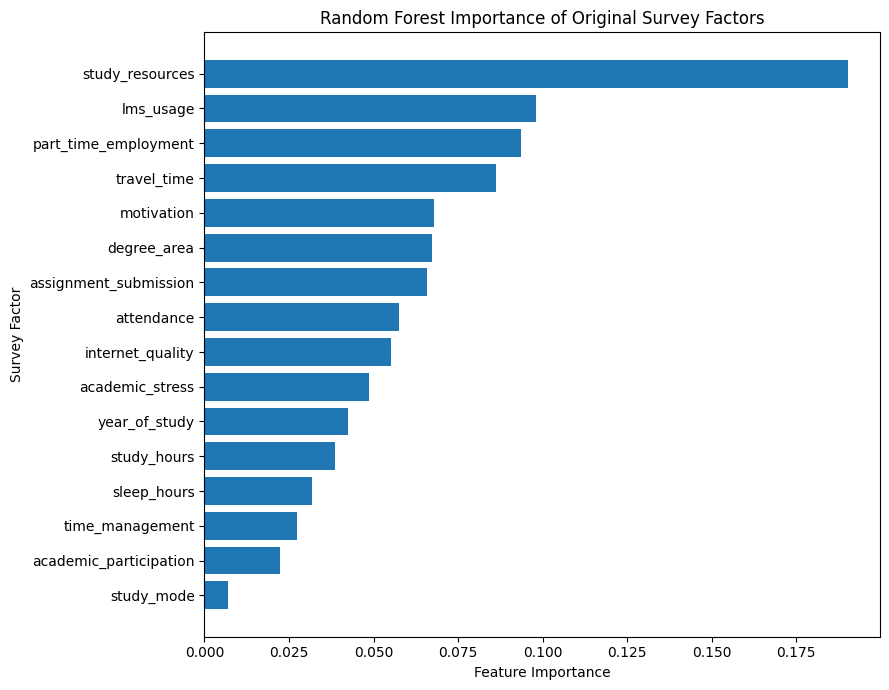

In [256]:
plt.figure(figsize=(9, 7))

plt.barh(
    plot_rf_original["Original_Feature"],
    plot_rf_original["Importance"]
)

plt.title("Random Forest Importance of Original Survey Factors")
plt.xlabel("Feature Importance")
plt.ylabel("Survey Factor")

plt.tight_layout()

plt.savefig(
    "/content/results/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [257]:
"/content/results/"

'/content/results/'

In [258]:
final_model_results.to_csv(
    "/content/results/final_model_results.csv",
    index=False
)

In [259]:
import shutil

shutil.make_archive(
    "/content/FINAL_RESEARCH_RESULTS",
    "zip",
    "/content/results"
)

print("ZIP created.")

ZIP created.


In [260]:
from google.colab import files

files.download(
    "/content/FINAL_RESEARCH_RESULTS.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [261]:
import os
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. CREATE FINAL RESULTS FOLDER
# =========================================================

RESULTS_FOLDER = "/content/FINAL_RESEARCH_RESULTS"
FIGURES_FOLDER = os.path.join(RESULTS_FOLDER, "figures")
TABLES_FOLDER = os.path.join(RESULTS_FOLDER, "tables")
MODEL_FOLDER = os.path.join(RESULTS_FOLDER, "model_information")

os.makedirs(RESULTS_FOLDER, exist_ok=True)
os.makedirs(FIGURES_FOLDER, exist_ok=True)
os.makedirs(TABLES_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER, exist_ok=True)

print("Folders created.")


# =========================================================
# 2. SAVE FINAL TABLES
# =========================================================

tables_to_save = {
    "final_sample_summary.csv":
        "final_sample_summary",

    "final_target_distribution.csv":
        "final_target_distribution",

    "final_model_results.csv":
        "final_model_results",

    "final_class_recall_table.csv":
        "final_class_recall_table",

    "final_model_stability.csv":
        "final_stability",

    "tuned_overfitting_check.csv":
        "tuned_overfit_df",

    "statistical_summary.csv":
        "statistical_summary",

    "baseline_model_results.csv":
        "baseline_results_df",

    "baseline_vs_tuned.csv":
        "baseline_vs_tuned",

    "nested_cv_fold_results.csv":
        "nested_results_df",

    "permutation_importance.csv":
        "permutation_df",

    "feature_importance_comparison.csv":
        "importance_comparison",

    "random_forest_feature_importance.csv":
        "rf_original_importance",

    "logistic_regression_coefficients.csv":
        "lr_coefficients_df",

    "macro_f1_95CI.csv":
        "macro_f1_ci",

    "accuracy_95CI.csv":
        "accuracy_ci",

    "participant_screening_flow.csv":
        "screening_flow"
}

for filename, variable_name in tables_to_save.items():

    if variable_name in globals():

        data = globals()[variable_name]

        path = os.path.join(
            TABLES_FOLDER,
            filename
        )

        data.to_csv(
            path,
            index=False
        )

        print("Saved:", filename)


# =========================================================
# 3. SAVE BEST MODEL PARAMETERS
# =========================================================

best_parameters = {}

if "final_lr_search" in globals():
    best_parameters[
        "Logistic Regression"
    ] = final_lr_search.best_params_

if "final_dt_search" in globals():
    best_parameters[
        "Decision Tree"
    ] = final_dt_search.best_params_

if "final_rf_search" in globals():
    best_parameters[
        "Random Forest"
    ] = final_rf_search.best_params_


with open(
    os.path.join(
        MODEL_FOLDER,
        "best_model_parameters.json"
    ),
    "w"
) as file:

    json.dump(
        best_parameters,
        file,
        indent=4
    )

print("Best model parameters saved.")


# =========================================================
# 4. SAVE SELECTED FEATURES
# =========================================================

if "X_model" in globals():

    with open(
        os.path.join(
            MODEL_FOLDER,
            "selected_features.txt"
        ),
        "w"
    ) as file:

        for i, feature in enumerate(
            X_model.columns,
            start=1
        ):
            file.write(
                f"{i}. {feature}\n"
            )

    print("Selected features saved.")


# =========================================================
# 5. SAVE PROJECT SUMMARY
# =========================================================

project_summary = {}

if "df_clean" in globals():
    project_summary[
        "raw_responses"
    ] = int(len(df_clean))

if "df_eligible" in globals():
    project_summary[
        "eligible_responses"
    ] = int(len(df_eligible))

if (
    "df_clean" in globals()
    and
    "df_eligible" in globals()
):
    project_summary[
        "excluded_responses"
    ] = int(
        len(df_clean)
        - len(df_eligible)
    )

if "X_model" in globals():
    project_summary[
        "number_of_predictors"
    ] = int(
        X_model.shape[1]
    )

if "y_model" in globals():

    project_summary[
        "number_of_target_classes"
    ] = int(
        y_model.nunique()
    )

    project_summary[
        "target_distribution"
    ] = {
        str(k): int(v)
        for k, v
        in y_model.value_counts().items()
    }

if "best_model_row" in globals():

    project_summary[
        "best_model"
    ] = str(
        best_model_row["Model"]
    )

    project_summary[
        "best_macro_f1"
    ] = float(
        best_model_row[
            "Macro_F1_Mean"
        ]
    )

if "friedman_p" in globals():

    project_summary[
        "friedman_p_value"
    ] = float(
        friedman_p
    )

    project_summary[
        "statistically_significant"
    ] = bool(
        friedman_p < 0.05
    )


with open(
    os.path.join(
        MODEL_FOLDER,
        "project_summary.json"
    ),
    "w"
) as file:

    json.dump(
        project_summary,
        file,
        indent=4
    )

print("Project summary saved.")


# =========================================================
# 6. SAVE TARGET DISTRIBUTION GRAPH
# =========================================================

if "y_model" in globals():

    plt.figure(figsize=(8, 5))

    y_model.value_counts().plot(
        kind="bar"
    )

    plt.title(
        "Academic Performance Class Distribution"
    )

    plt.xlabel(
        "Academic Performance Category"
    )

    plt.ylabel(
        "Number of Students"
    )

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "target_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: target_distribution.png"
    )


# =========================================================
# 7. SAVE BASELINE MODEL COMPARISON GRAPH
# =========================================================

if "baseline_results_df" in globals():

    plt.figure(figsize=(8, 5))

    (
        baseline_results_df
        .set_index("Model")[
            "Macro_F1_Mean"
        ]
        .plot(kind="bar")
    )

    plt.title(
        "Baseline Model Comparison"
    )

    plt.xlabel("Model")
    plt.ylabel("Mean Macro F1")
    plt.ylim(0, 1)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "baseline_model_comparison.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: baseline_model_comparison.png"
    )


# =========================================================
# 8. SAVE BASELINE VS TUNED GRAPH
# =========================================================

if "baseline_vs_tuned" in globals():

    graph_data = (
        baseline_vs_tuned
        .set_index("Model")[
            [
                "Baseline_Macro_F1",
                "Tuned_Macro_F1"
            ]
        ]
    )

    graph_data.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(
        "Baseline vs Tuned Model Performance"
    )

    plt.xlabel("Model")
    plt.ylabel("Macro F1")

    plt.ylim(0, 1)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "baseline_vs_tuned.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: baseline_vs_tuned.png"
    )


# =========================================================
# 9. SAVE CLASS-WISE RECALL GRAPH
# =========================================================

if "final_class_recall_table" in globals():

    recall_plot = (
        final_class_recall_table
        .set_index("Model")[
            [
                "Low_Recall_Mean",
                "Average_Recall_Mean",
                "High_Recall_Mean"
            ]
        ]
    )

    recall_plot.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(
        "Class-wise Recall by Model"
    )

    plt.xlabel("Model")
    plt.ylabel("Recall")

    plt.ylim(0, 1)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "class_wise_recall.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: class_wise_recall.png"
    )


# =========================================================
# 10. SAVE RANDOM FOREST FEATURE IMPORTANCE
# =========================================================

if "rf_original_importance" in globals():

    plot_data = (
        rf_original_importance
        .sort_values(
            "Importance",
            ascending=True
        )
    )

    plt.figure(figsize=(9, 7))

    plt.barh(
        plot_data[
            "Original_Feature"
        ],
        plot_data[
            "Importance"
        ]
    )

    plt.title(
        "Random Forest Feature Importance"
    )

    plt.xlabel(
        "Feature Importance"
    )

    plt.ylabel(
        "Survey Factor"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "random_forest_feature_importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: random_forest_feature_importance.png"
    )


# =========================================================
# 11. SAVE PERMUTATION IMPORTANCE GRAPH
# =========================================================

if "permutation_df" in globals():

    perm_plot = (
        permutation_df
        .sort_values(
            "Importance_Mean",
            ascending=True
        )
    )

    plt.figure(figsize=(9, 7))

    plt.barh(
        perm_plot["Feature"],
        perm_plot[
            "Importance_Mean"
        ]
    )

    plt.title(
        "Permutation Feature Importance"
    )

    plt.xlabel(
        "Decrease in Macro F1"
    )

    plt.ylabel(
        "Survey Factor"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "permutation_importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: permutation_importance.png"
    )


# =========================================================
# 12. SAVE TUNED CONFUSION MATRICES
# =========================================================

def save_confusion_matrix(
    cm,
    title,
    filename
):

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.imshow(cm)

    ax.set_xticks(
        [0, 1, 2]
    )

    ax.set_yticks(
        [0, 1, 2]
    )

    ax.set_xticklabels(
        [
            "Low",
            "Average",
            "High"
        ]
    )

    ax.set_yticklabels(
        [
            "Low",
            "Average",
            "High"
        ]
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )

    ax.set_title(title)

    for i in range(3):
        for j in range(3):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


if "cm_lr_tuned" in globals():

    save_confusion_matrix(
        cm_lr_tuned,
        "Tuned Logistic Regression Confusion Matrix",
        "tuned_logistic_regression_confusion_matrix.png"
    )


if "cm_dt_tuned" in globals():

    save_confusion_matrix(
        cm_dt_tuned,
        "Tuned Decision Tree Confusion Matrix",
        "tuned_decision_tree_confusion_matrix.png"
    )


if "cm_rf_tuned" in globals():

    save_confusion_matrix(
        cm_rf_tuned,
        "Tuned Random Forest Confusion Matrix",
        "tuned_random_forest_confusion_matrix.png"
    )

print("Confusion matrices saved.")


# =========================================================
# 13. SAVE DECISION TREE GRAPH
# =========================================================

if (
    "dt_model_only" in globals()
    and
    "tree_feature_names" in globals()
):

    from sklearn.tree import plot_tree

    plt.figure(
        figsize=(22, 10)
    )

    plot_tree(
        dt_model_only,
        feature_names=tree_feature_names,
        class_names=[
            "Low",
            "Average",
            "High"
        ],
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=8
    )

    plt.title(
        "Decision Tree Structure"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_FOLDER,
            "decision_tree_structure.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        "Saved: decision_tree_structure.png"
    )


# =========================================================
# 14. CREATE README
# =========================================================

readme_text = """
ACADEMIC PERFORMANCE PREDICTION RESEARCH RESULTS

Folder structure:

figures/
- Publication-quality PNG graphs
- Model comparison figures
- Confusion matrices
- Feature importance graphs
- Decision tree visualization

tables/
- Sample summary
- Target distribution
- Model results
- Class-wise recall
- Cross-validation results
- Statistical results
- Confidence intervals
- Feature importance
- Participant screening

model_information/
- Best hyperparameters
- Selected features
- Project summary

Research Topic:
A Comparative Study of Academic Performance Prediction
Among Sri Lankan Private Campus Students Using Survey-Based Factors
"""

with open(
    os.path.join(
        RESULTS_FOLDER,
        "README.txt"
    ),
    "w"
) as file:

    file.write(
        readme_text
    )

print("README saved.")


# =========================================================
# 15. ZIP EVERYTHING
# =========================================================

zip_path = shutil.make_archive(
    "/content/FINAL_RESEARCH_COMPLETE_PACKAGE",
    "zip",
    RESULTS_FOLDER
)

print("\n" + "=" * 70)
print("COMPLETE")
print("=" * 70)

print(
    "Final package:",
    zip_path
)

Folders created.
Saved: final_sample_summary.csv
Saved: final_target_distribution.csv
Saved: final_model_results.csv
Saved: final_class_recall_table.csv
Saved: final_model_stability.csv
Saved: tuned_overfitting_check.csv
Saved: statistical_summary.csv
Saved: baseline_model_results.csv
Saved: baseline_vs_tuned.csv
Saved: nested_cv_fold_results.csv
Saved: permutation_importance.csv
Saved: feature_importance_comparison.csv
Saved: random_forest_feature_importance.csv
Saved: logistic_regression_coefficients.csv
Saved: macro_f1_95CI.csv
Saved: accuracy_95CI.csv
Saved: participant_screening_flow.csv
Best model parameters saved.
Selected features saved.
Project summary saved.
Saved: target_distribution.png
Saved: baseline_model_comparison.png
Saved: baseline_vs_tuned.png
Saved: class_wise_recall.png
Saved: random_forest_feature_importance.png
Saved: permutation_importance.png
Confusion matrices saved.
Saved: decision_tree_structure.png
README saved.

COMPLETE
Final package: /content/FINAL_RESE

In [262]:
from google.colab import files

files.download(
    "/content/FINAL_RESEARCH_COMPLETE_PACKAGE.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [263]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

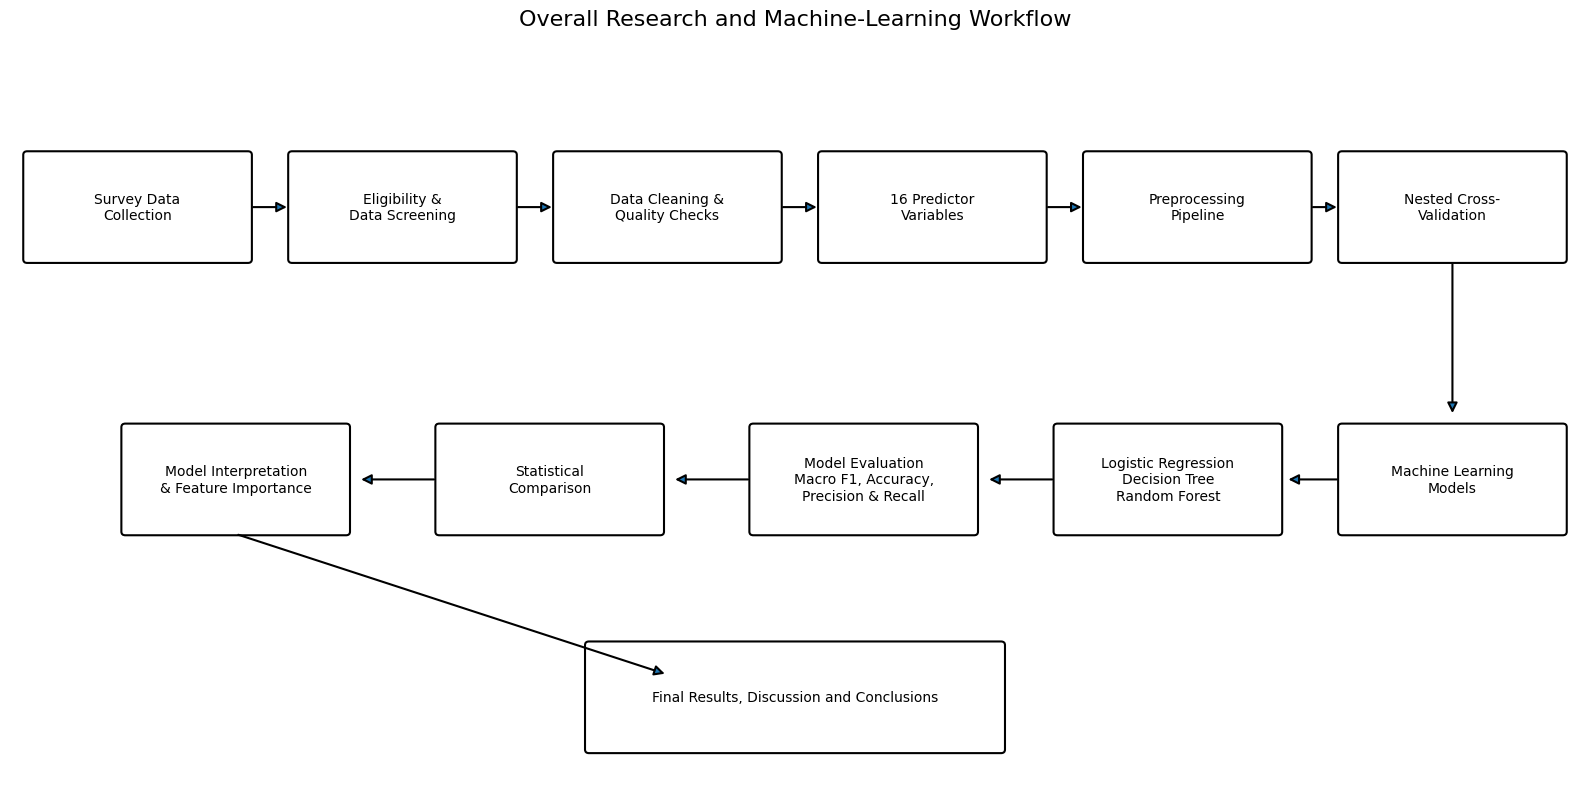

Saved:
/content/FINAL_RESEARCH_RESULTS/figures/research_workflow.png


In [264]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os

FIGURES_FOLDER = "/content/FINAL_RESEARCH_RESULTS/figures"
os.makedirs(FIGURES_FOLDER, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")

steps = [
    (1.3, 6.3, "Survey Data\nCollection"),
    (4.0, 6.3, "Eligibility &\nData Screening"),
    (6.7, 6.3, "Data Cleaning &\nQuality Checks"),
    (9.4, 6.3, "16 Predictor\nVariables"),
    (12.1, 6.3, "Preprocessing\nPipeline"),
    (14.7, 6.3, "Nested Cross-\nValidation"),

    (14.7, 3.3, "Machine Learning\nModels"),
    (11.8, 3.3, "Logistic Regression\nDecision Tree\nRandom Forest"),
    (8.7, 3.3, "Model Evaluation\nMacro F1, Accuracy,\nPrecision & Recall"),
    (5.5, 3.3, "Statistical\nComparison"),
    (2.3, 3.3, "Model Interpretation\n& Feature Importance"),

    (8.0, 0.9, "Final Results, Discussion and Conclusions")
]

def add_box(x, y, text, width=2.25, height=1.15):
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width,
        height,
        boxstyle="round,pad=0.04",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=10
    )

for x, y, text in steps:
    width = 4.2 if "Final Results" in text else 2.25
    add_box(x, y, text, width=width)

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# Top row
arrow(2.45, 6.3, 2.85, 6.3)
arrow(5.15, 6.3, 5.55, 6.3)
arrow(7.85, 6.3, 8.25, 6.3)
arrow(10.55, 6.3, 10.95, 6.3)
arrow(13.25, 6.3, 13.55, 6.3)

# Down to modelling
arrow(14.7, 5.7, 14.7, 4.0)

# Second row moving left
arrow(13.55, 3.3, 13.0, 3.3)
arrow(10.65, 3.3, 9.95, 3.3)
arrow(7.55, 3.3, 6.75, 3.3)
arrow(4.35, 3.3, 3.55, 3.3)

# Final output
arrow(2.3, 2.7, 6.7, 1.15)

ax.set_title(
    "Overall Research and Machine-Learning Workflow",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_FOLDER,
        "research_workflow.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(
    os.path.join(
        FIGURES_FOLDER,
        "research_workflow.png"
    )
)

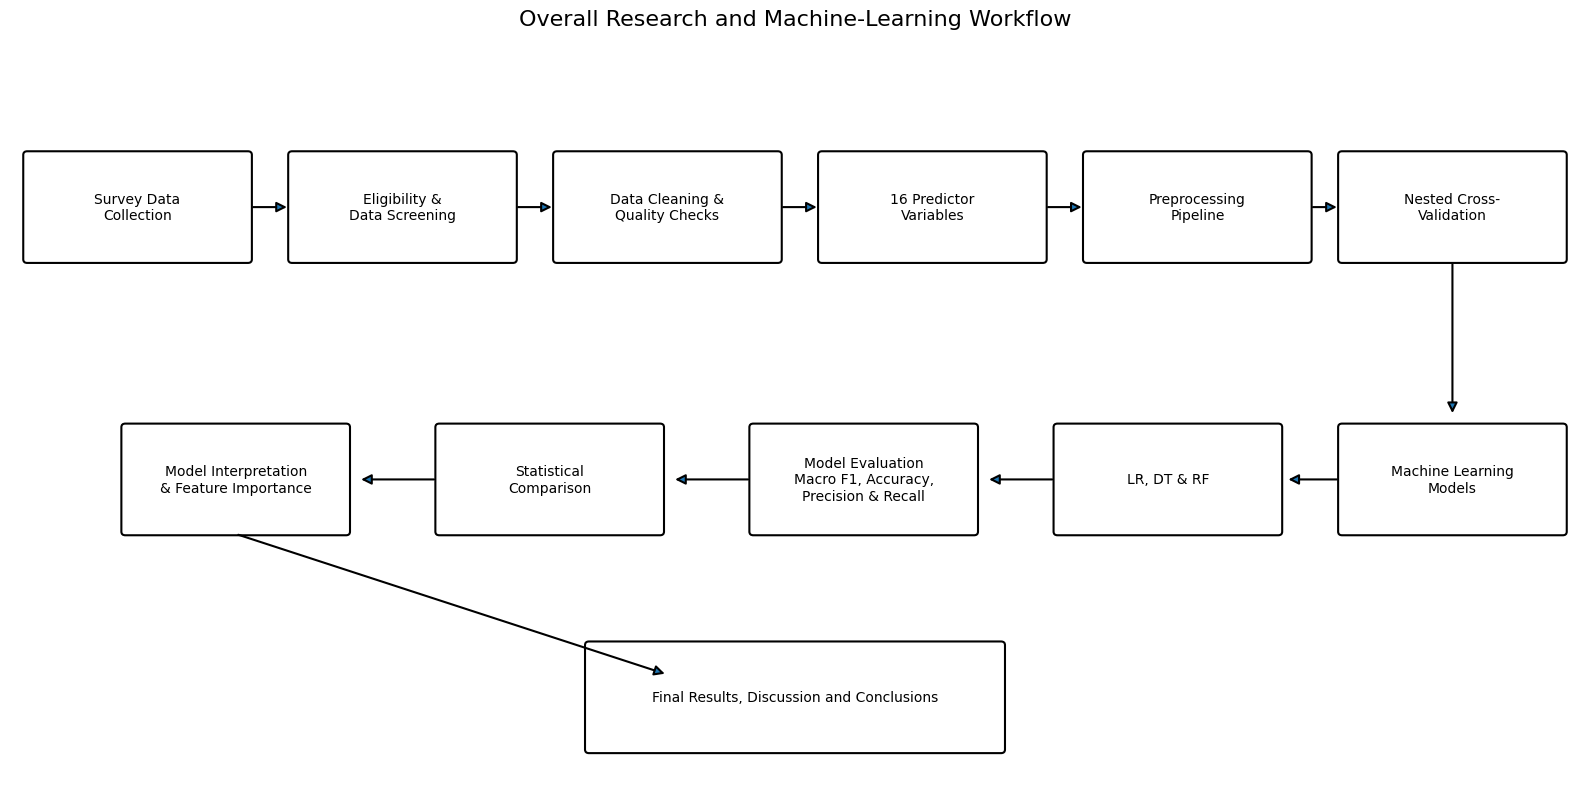

File exists: True
Saved at: /content/research_workflow.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [266]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from google.colab import files
import os

# File path
file_path = "/content/research_workflow.png"

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")

steps = [
    (1.3, 6.3, "Survey Data\nCollection"),
    (4.0, 6.3, "Eligibility &\nData Screening"),
    (6.7, 6.3, "Data Cleaning &\nQuality Checks"),
    (9.4, 6.3, "16 Predictor\nVariables"),
    (12.1, 6.3, "Preprocessing\nPipeline"),
    (14.7, 6.3, "Nested Cross-\nValidation"),

    (14.7, 3.3, "Machine Learning\nModels"),
    (11.8, 3.3, "LR, DT & RF"),
    (8.7, 3.3, "Model Evaluation\nMacro F1, Accuracy,\nPrecision & Recall"),
    (5.5, 3.3, "Statistical\nComparison"),
    (2.3, 3.3, "Model Interpretation\n& Feature Importance"),

    (8.0, 0.9, "Final Results, Discussion and Conclusions")
]

def add_box(x, y, text, width=2.25, height=1.15):
    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width,
        height,
        boxstyle="round,pad=0.04",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )

    ax.add_patch(box)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=10
    )

for x, y, text in steps:
    width = 4.2 if "Final Results" in text else 2.25
    add_box(x, y, text, width=width)

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# Arrows
arrow(2.45, 6.3, 2.85, 6.3)
arrow(5.15, 6.3, 5.55, 6.3)
arrow(7.85, 6.3, 8.25, 6.3)
arrow(10.55, 6.3, 10.95, 6.3)
arrow(13.25, 6.3, 13.55, 6.3)

arrow(14.7, 5.7, 14.7, 4.0)

arrow(13.55, 3.3, 13.0, 3.3)
arrow(10.65, 3.3, 9.95, 3.3)
arrow(7.55, 3.3, 6.75, 3.3)
arrow(4.35, 3.3, 3.55, 3.3)

arrow(2.3, 2.7, 6.7, 1.15)

ax.set_title(
    "Overall Research and Machine-Learning Workflow",
    fontsize=16,
    pad=20
)

plt.tight_layout()

# SAVE FIRST
plt.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Check file
print("File exists:", os.path.exists(file_path))
print("Saved at:", file_path)

# Download
files.download(file_path)